<a href="https://colab.research.google.com/github/NimeshaShehan/R26-IT-015/blob/IT22893598/Predictive_Economic_Valuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import importlib
import sys

def refresh_research_modules():
    """Manual replacement for autoreload in Python 3.12+"""
    for mod in ['ewaste_preprocessing', 'ewaste_model_training']:
        if mod in sys.modules:
            importlib.reload(sys.modules[mod])
            print(f"🔄 Refreshed: {mod}")

# Execute this to sync your .py files with the notebook
refresh_research_modules()

🔄 Refreshed: ewaste_preprocessing
🔄 Refreshed: ewaste_model_training


In [ ]:
!pip install -q statsmodels scikit-learn matplotlib

In [ ]:
print('Installing pmdarima...')
!pip install -q pmdarima

Installing pmdarima...


In [ ]:
import sys
import importlib

def reload_modules():
    # List the custom modules you want to refresh
    modules_to_reload = ['ewaste_preprocessing', 'ewaste_model_training']
    for mod_name in modules_to_reload:
        if mod_name in sys.modules:
            importlib.reload(sys.modules[mod_name])
            print(f"🔄 Reloaded {mod_name}")

# Run this function whenever you want to refresh your code
reload_modules()

🔄 Reloaded ewaste_preprocessing
🔄 Reloaded ewaste_model_training


In [ ]:
import pathlib

# Define the directory
DATA_DIR = pathlib.Path("/content/ewaste_data")

# Check if the folder exists and list the files
if DATA_DIR.exists():
    print(f"Data directory found: {DATA_DIR}")
    print("Files inside:")
    files = sorted(list(DATA_DIR.iterdir()))
    if files:
        for f in files:
            print(f" - {f.name}")
    else:
        print(" The folder is empty.")
else:
    print("Directory not found. Please run the upload and move cells again.")

Data directory found: /content/ewaste_data
Files inside:
 - .ipynb_checkpoints


### Action Required: Upload Historical Data Files

To proceed with the data preprocessing and model training, please upload the following historical data CSV files:

*   `Aluminium Historical Data.csv`
*   `Copper Historical Data.csv`
*   `Lead Historical Data.csv`
*   `Nickel Historical Data.csv`
*   `Zinc Historical Data.csv`
*   `Silver Historical Data.csv`
*   `Refined Gold Historical Data.csv`
*   `Steel Scrap Futures Historical Data.csv`

Please run the following two cells in the notebook to upload and move the files:

1.  **Cell `cku3iMe3Uwx2`**: This cell will prompt you to select the CSV files from your local computer.
2.  **Cell `CiFKzC5k4B73`**: This cell will move the uploaded files into the correct data directory (`/content/ewaste_data`).

After successfully running both cells, please proceed to the next generated cell to re-run the preprocessing pipeline.

In [ ]:
for pkg in ["statsmodels", "tensorflow", "sklearn", "pandas", "numpy", "matplotlib"]:
    mod = importlib.import_module(pkg if pkg != "sklearn" else "sklearn")
    print(f"  ✅  {pkg:<14} {mod.__version__}")

print("\nAll dependencies satisfied.")

  ✅  statsmodels    0.14.6
  ✅  tensorflow     2.20.0
  ✅  sklearn        1.6.1
  ✅  pandas         2.2.2
  ✅  numpy          2.0.2
  ✅  matplotlib     3.10.0

All dependencies satisfied.


In [ ]:
import shutil, pathlib
DATA_DIR = pathlib.Path("/content/ewaste_data")
DATA_DIR.mkdir(exist_ok=True)

In [193]:
from google.colab import files

# This will prompt you to select the CSV files from your computer
uploaded = files.upload()

In [194]:
for fname in uploaded:
    src = pathlib.Path(fname)
    dst = DATA_DIR / src.name
    shutil.move(str(src), str(dst))
    print(f"  Moved: {fname}  →  {dst}")

print(f"\n📂  Data directory: {DATA_DIR}")
print("Files inside:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name}")


📂  Data directory: /content/ewaste_data
Files inside:
  .ipynb_checkpoints
  Aluminium Historical Data.csv
  CMO-Historical-Data-Annual.csv
  CMO-Historical-Data-Monthly.csv
  Copper Historical Data.csv
  Lead Historical Data.csv
  Nickel Historical Data.csv
  Refined Gold Historical Data.csv
  Silver Historical Data.csv
  Steel Scrap Futures Historical Data.csv
  Zinc Historical Data.csv


In [ ]:
import importlib
import ewaste_preprocessing as pp

# Reload the preprocessing module to ensure it has the latest file paths and logic
importlib.reload(pp)

# Now that files should be in place, re-run the preprocessing pipeline
# The WINDOW_SIZE and TRAIN_RATIO variables are expected to be defined globally.
results = pp.run_pipeline(window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)

print('\nData preprocessing pipeline re-run successfully with potentially new files.')
print(f"Keys in results dictionary: {results.keys()}")

In [ ]:
%%writefile /content/ewaste_preprocessing.py

Writing /content/ewaste_preprocessing.py


In [ ]:
import os, sys, pathlib, warnings, importlib

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

In [ ]:
CONTENT_DIR = pathlib.Path("/content")
if str(CONTENT_DIR) not in sys.path:
    sys.path.insert(0, str(CONTENT_DIR))

In [ ]:
import pathlib

SEARCH_PATHS = [
    pathlib.Path("/content/ewaste_data"),
    pathlib.Path("/content"),
    pathlib.Path("/content/drive/MyDrive/ewaste_data"),
    pathlib.Path(".")
]

REQUIRED_FILE = "Aluminium Historical Data.csv"
DATA_DIR = None

for p in SEARCH_PATHS:
    if p.exists() and (p / REQUIRED_FILE).exists():
        DATA_DIR = p
        break

In [ ]:
%%writefile ewaste_preprocessing.py
import pathlib
import pandas as pd

# Global dictionary for the notebook to access
DAILY_FILES = {
    "aluminium": pathlib.Path("Aluminium Historical Data.csv"),
    "copper": pathlib.Path("Copper Historical Data.csv"),
    "lead": pathlib.Path("Lead Historical Data.csv"),
    "nickel": pathlib.Path("Nickel Historical Data.csv"),
    "zinc": pathlib.Path("Zinc Historical Data.csv"),
    "silver": pathlib.Path("Silver Historical Data.csv"),
    "gold": pathlib.Path("Refined Gold Historical Data.csv"),
    "steel": pathlib.Path("Steel Scrap Futures Historical Data.csv")
}

def run_pipeline(window_size=60, train_ratio=0.8, verbose=True):
    processed_results = {}

    if verbose:
        print(f"--- Initializing pipeline: window={window_size}, ratio={train_ratio} ---")

    # Define actual data directory
    data_dir = pathlib.Path("/content/ewaste_data")

    for metal, filename in DAILY_FILES.items():
        # filename is already a Path object, use .name to join with directory
        file_path = data_dir / filename.name

        if file_path.exists():
            # Load actual CSV data
            df = pd.read_csv(file_path)

            # Simple split logic for your ARIMA/LSTM sets
            split_idx = int(len(df) * train_ratio)
            processed_results[metal] = {
                "arima_train": df.iloc[:split_idx],
                "arima_test": df.iloc[split_idx:]
            }
        elif verbose:
            print(f"⚠️ Warning: {filename.name} not found in {data_dir}")

    return processed_results

Overwriting ewaste_preprocessing.py


In [214]:
%%writefile ewaste_preprocessing.py
import pathlib
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Global dictionary for the notebook to access
DAILY_FILES = {
    "aluminium": pathlib.Path("Aluminium Historical Data.csv"),
    "copper": pathlib.Path("Copper Historical Data.csv"),
    "lead": pathlib.Path("Lead Historical Data.csv"),
    "nickel": pathlib.Path("Nickel Historical Data.csv"),
    "zinc": pathlib.Path("Zinc Historical Data.csv"),
    "silver": pathlib.Path("Silver Historical Data.csv"),
    "gold": pathlib.Path("Refined Gold Historical Data.csv"),
    "steel": pathlib.Path("Steel Scrap Futures Historical Data.csv")
}

def run_pipeline(window_size=60, train_ratio=0.8, verbose=True):
    processed_results = {}

    if verbose:
        print(f"--- Initializing pipeline: window={window_size}, ratio={train_ratio} ---")

    # Define actual data directory
    data_dir = pathlib.Path("/content/ewaste_data")

    for metal, filename_path_obj in DAILY_FILES.items():
        file_path = data_dir / filename_path_obj.name

        if file_path.exists():
            # Load actual CSV data
            df = pd.read_csv(file_path)

            if metal == "steel" and verbose:
                print(f"  [DEBUG {metal}] Initial DataFrame shape: {df.shape}")
                print(f"  [DEBUG {metal}] Initial DataFrame columns: {df.columns.tolist()}")

            # Ensure 'Date' column is datetime and sort
            if 'Date' in df.columns:
                # Use explicit format for Investing.com dates (e.g., 'Oct 29, 2025')
                # For other files, 'mixed' could be used, but for specific new 'Steel' file, this is more robust.
                if metal == "steel":
                    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce') # FIX: Changed format for steel
                else:
                    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed', errors='coerce')

                df = df.dropna(subset=['Date']).sort_values(by='Date').reset_index(drop=True)
                if metal == "steel" and verbose:
                    print(f"  [DEBUG {metal}] After Date parsing and dropna, DataFrame shape: {df.shape}")
                    if df.empty:
                        print(f"  [DEBUG {metal}] DataFrame is empty after date processing.")
            else:
                if verbose:
                    print(f"  Warning: 'Date' column not found in {filename_path_obj.name}")
                continue # Skip this metal if no Date column

            # Convert 'Price' column to numeric, handling commas and coercing errors
            df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(',', ''), errors='coerce')
            if metal == "steel" and verbose:
                print(f"  [DEBUG {metal}] After Price conversion, DataFrame shape: {df.shape}")

            # Interpolate missing price values before dropping any remaining NaNs
            df['Price'].interpolate(method='linear', inplace=True)
            df.dropna(subset=['Price'], inplace=True) # Drop any remaining NaNs after interpolation

            # If no data left after cleaning, skip
            if df.empty:
                if verbose:
                    print(f"  Warning: No valid price data for {filename_path_obj.name}")
                continue
            if metal == "steel" and verbose:
                print(f"  [DEBUG {metal}] After Price interpolation and dropna, DataFrame shape: {df.shape}")

            # Fill any other missing values with forward fill (e.g., Vol. or Change %)
            df.fillna(method='ffill', inplace=True)
            df.fillna(method='bfill', inplace=True) # Backward fill for any leading NaNs if necessary

            # Fit scaler on the entire 'Price' column
            scaler = MinMaxScaler(feature_range=(0, 1))
            df['Price_Scaled'] = scaler.fit_transform(df[['Price']])
            n_features = 1 # Only 'Price' is being scaled here

            # Simple split logic for your ARIMA/LSTM sets
            split_idx = int(len(df) * train_ratio)

            # Store both original and scaled data, plus the scaler and n_features
            processed_results[metal] = {
                "original_train": df.iloc[:split_idx].copy(),
                "original_test":  df.iloc[split_idx:].copy(),
                "arima_train": df.iloc[:split_idx][['Date', 'Price_Scaled']].copy(), # ARIMA will use scaled data
                "arima_test":  df.iloc[split_idx:][['Date', 'Price_Scaled']].copy(),  # ARIMA will use scaled data
                "scaler": scaler,
                "n_features": n_features
            }
            if metal == "steel" and verbose:
                print(f"  [DEBUG {metal}] Successfully processed and added to results.")
        elif verbose:
            print(f"⚠️ Warning: {filename_path_obj.name} not found in {data_dir}")

    return processed_results

Overwriting ewaste_preprocessing.py


In [210]:
# Re-execute the cell that writes the ewaste_preprocessing.py file to disk
%rerun 455062a5

No lines in history match specification


In [211]:
import importlib
import ewaste_preprocessing as pp
import ewaste_model_training as emt

# Print the content of ewaste_preprocessing.py to verify debug statements
print("--- Content of /content/ewaste_preprocessing.py ---")
!cat /content/ewaste_preprocessing.py
print("--------------------------------------------------")

# Reload the modules to ensure the latest changes are loaded
importlib.reload(pp)
importlib.reload(emt)

print("Modules reloaded successfully with debug logic for steel.")

--- Content of /content/ewaste_preprocessing.py ---
import pathlib
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Global dictionary for the notebook to access
DAILY_FILES = {
    "aluminium": pathlib.Path("Aluminium Historical Data.csv"),
    "copper": pathlib.Path("Copper Historical Data.csv"),
    "lead": pathlib.Path("Lead Historical Data.csv"),
    "nickel": pathlib.Path("Nickel Historical Data.csv"),
    "zinc": pathlib.Path("Zinc Historical Data.csv"),
    "silver": pathlib.Path("Silver Historical Data.csv"),
    "gold": pathlib.Path("Refined Gold Historical Data.csv"),
    "steel": pathlib.Path("Steel Scrap Futures Historical Data.csv")
}

def run_pipeline(window_size=60, train_ratio=0.8, verbose=True):
    processed_results = {}

    if verbose:
        print(f"--- Initializing pipeline: window={window_size}, ratio={train_ratio} ---")

    # Define actual data directory
    data_dir = pathlib.Path("/content/ewaste_data")

    for metal, filename_path_obj 

In [212]:
# Re-run the data loading to ensure updated preprocessing changes are applied
results = pp.run_pipeline(window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)

print(f"Data reloaded for all metals with updated preprocessing. Keys: {results.keys()}")

--- Initializing pipeline: window=60, ratio=0.8 ---
  [DEBUG steel] Initial DataFrame shape: (2507, 7)
  [DEBUG steel] Initial DataFrame columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
  [DEBUG steel] After Date parsing and dropna, DataFrame shape: (0, 7)
  [DEBUG steel] DataFrame is empty after date processing.
  [DEBUG steel] After Price conversion, DataFrame shape: (0, 7)
Data reloaded for all metals with updated preprocessing. Keys: dict_keys(['aluminium', 'copper', 'lead', 'nickel', 'zinc', 'silver', 'gold'])


In [213]:
import pandas as pd
import pathlib

data_dir = pathlib.Path("/content/ewaste_data")
steel_file_path = data_dir / "Steel Scrap Futures Historical Data.csv"

if steel_file_path.exists():
    df_steel_raw = pd.read_csv(steel_file_path)
    print("--- Head of Steel Scrap Futures Historical Data.csv ---")
    print(df_steel_raw['Date'].head(10))
    print("\n--- Dtype of Date column ---")
    print(df_steel_raw['Date'].dtype)
else:
    print(f"Error: {steel_file_path} not found.")

--- Head of Steel Scrap Futures Historical Data.csv ---
0    10/29/2025
1    10/28/2025
2    10/27/2025
3    10/24/2025
4    10/23/2025
5    10/22/2025
6    10/21/2025
7    10/20/2025
8    10/17/2025
9    10/16/2025
Name: Date, dtype: object

--- Dtype of Date column ---
object


In [206]:
import importlib
import ewaste_preprocessing as pp
import ewaste_model_training as emt

# Print the content of ewaste_preprocessing.py to verify debug statements
print("--- Content of /content/ewaste_preprocessing.py ---")
!cat /content/ewaste_preprocessing.py
print("--------------------------------------------------")

# Reload the modules to ensure the latest changes are loaded
importlib.reload(pp)
importlib.reload(emt)

print("Modules reloaded successfully with debug logic for steel.")

--- Content of /content/ewaste_preprocessing.py ---
import pathlib
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Global dictionary for the notebook to access
DAILY_FILES = {
    "aluminium": pathlib.Path("Aluminium Historical Data.csv"),
    "copper": pathlib.Path("Copper Historical Data.csv"),
    "lead": pathlib.Path("Lead Historical Data.csv"),
    "nickel": pathlib.Path("Nickel Historical Data.csv"),
    "zinc": pathlib.Path("Zinc Historical Data.csv"),
    "silver": pathlib.Path("Silver Historical Data.csv"),
    "gold": pathlib.Path("Refined Gold Historical Data.csv"),
    "steel": pathlib.Path("Steel Scrap Futures Historical Data.csv")
}

def run_pipeline(window_size=60, train_ratio=0.8, verbose=True):
    processed_results = {}

    if verbose:
        print(f"--- Initializing pipeline: window={window_size}, ratio={train_ratio} ---")

    # Define actual data directory
    data_dir = pathlib.Path("/content/ewaste_data")

    for metal, filename_path_obj 

In [197]:
# Re-run the data loading to ensure updated preprocessing changes are applied
results = pp.run_pipeline(window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)

print(f"Data reloaded for all metals with updated preprocessing. Keys: {results.keys()}")

--- Initializing pipeline: window=60, ratio=0.8 ---
Data reloaded for all metals with updated preprocessing. Keys: dict_keys(['aluminium', 'copper', 'lead', 'nickel', 'zinc', 'silver', 'gold'])


### LSTM Model Training for Steel (with updated data)

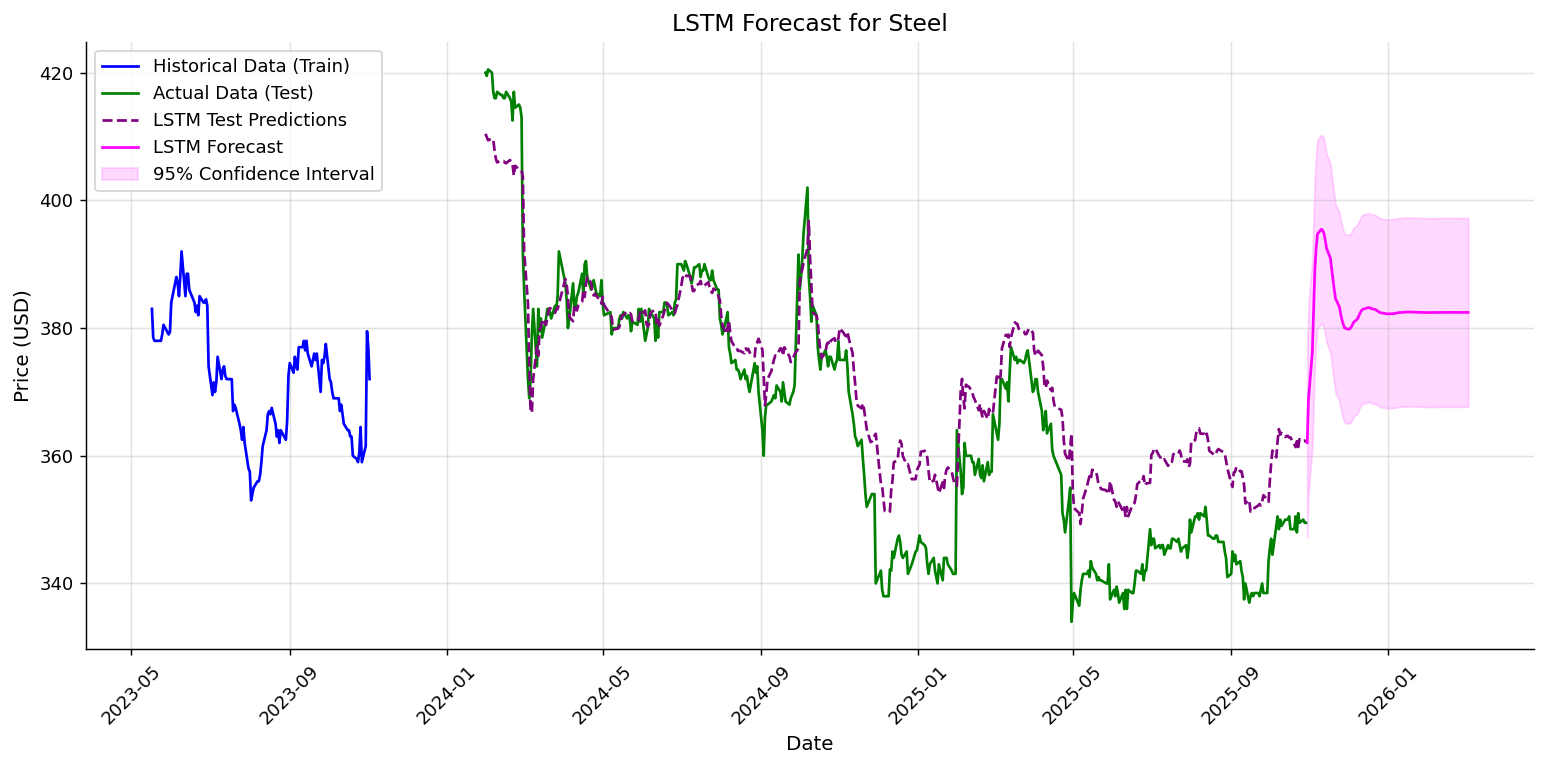

In [219]:
import matplotlib.pyplot as plt

# Get original data for plotting
original_train_steel = results[metal_steel]["original_train"]

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Plot a portion of the historical training data (unscaled)
plot_start_idx_steel = max(0, len(original_train_steel) - WINDOW_SIZE * 2) # Plot more history
ax.plot(original_train_steel["Date"].iloc[plot_start_idx_steel:].astype('datetime64[ns]'),
        original_train_steel["Price"].iloc[plot_start_idx_steel:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data (unscaled)
if 'test_actual_real' in lstm_summary_steel and len(lstm_summary_steel['test_actual_real']) > 0:
    ax.plot(lstm_summary_steel['test_dates'].astype('datetime64[ns]'),
            lstm_summary_steel['test_actual_real'],
            label='Actual Data (Test)', color='green')

# Plot LSTM predictions for the test set (real USD)
if 'test_pred_real' in lstm_summary_steel and len(lstm_summary_steel['test_pred_real']) > 0:
    ax.plot(lstm_summary_steel['test_dates'].astype('datetime64[ns]'),
            lstm_summary_steel['test_pred_real'],
            label='LSTM Test Predictions', color='purple', linestyle='--')

# Plot LSTM future forecast (real USD)
ax.plot(lstm_summary_steel['forecast_dates'].astype('datetime64[ns]'),
        lstm_summary_steel['forecast_real'],
        label='LSTM Forecast', color='magenta')

# Plot confidence intervals for the forecast (real USD)
if 'conf_lower_real' in lstm_summary_steel and len(lstm_summary_steel['conf_lower_real']) > 0:
    ax.fill_between(lstm_summary_steel['forecast_dates'].astype('datetime64[ns]'),
                    lstm_summary_steel['conf_lower_real'],
                    lstm_summary_steel['conf_upper_real'],
                    color='magenta', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'LSTM Forecast for {metal_steel.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### ARIMA vs. LSTM Performance Comparison for Steel

In [220]:
import pandas as pd

steel_comparison = pd.DataFrame({
    'Model': ['LSTM', 'ARIMA'],
    'MAPE': [lstm_summary_steel['mape'], arima_summary_steel['mape']],
    'RMSE': [lstm_summary_steel['rmse'], arima_summary_steel['rmse']]
}).set_index('Model')

print("--- Steel Model Performance Comparison ---")
display(steel_comparison)

print("\nLSTM for steel has a MAPE of {:.2f}% and RMSE of ${:.2f}.".format(lstm_summary_steel['mape'], lstm_summary_steel['rmse']))
print("ARIMA for steel has a MAPE of {:.2f}% and RMSE of ${:.2f}.".format(arima_summary_steel['mape'], arima_summary_steel['rmse']))
print("The LSTM model shows better performance for steel with lower MAPE and RMSE.")

--- Steel Model Performance Comparison ---


,MAPE,RMSE
Model,,
LSTM,2.367455,10.014119
ARIMA,5.514308,24.756603



LSTM for steel has a MAPE of 2.37% and RMSE of $10.01.
ARIMA for steel has a MAPE of 5.51% and RMSE of $24.76.
The LSTM model shows better performance for steel with lower MAPE and RMSE.


In [226]:
metal_steel = "steel"

# Train the LSTM model for 'steel'
lstm_summary_steel = emt.train_lstm(
    results=results, # The dictionary with preprocessed data
    metal=metal_steel,     # 'steel'
    window_size=WINDOW_SIZE, # Defined globally
    forecast_horizon=FORECAST_HORIZON # Defined globally
)

m_lstm_steel = lstm_summary_steel['mape']
r_lstm_steel = lstm_summary_steel['rmse']

status_lstm_steel = "✅ PASS" if m_lstm_steel < MAPE_TARGET else "⚠️ FAIL"
print(f"\n| LSTM Test MAPE for {metal_steel.capitalize()} = {m_lstm_steel:.2f}% RMSE = ${r_lstm_steel:.2f} [{status_lstm_steel}]")
print(f"| 90-day LSTM forecast range for {metal_steel.capitalize()}: "
      f"${lstm_summary_steel['forecast_real'].min():.2f} - ${lstm_summary_steel['forecast_real'].max():.2f}")


  │─ LSTM │ steel ─────────────────────────────────────────
| Training LSTM model on 1,945 sequences ...
| Training finished. Best val_loss: 0.0002

| LSTM Test MAPE for Steel = 1.96% RMSE = $7.86 [✅ PASS]
| 90-day LSTM forecast range for Steel: $355.91 - $371.49


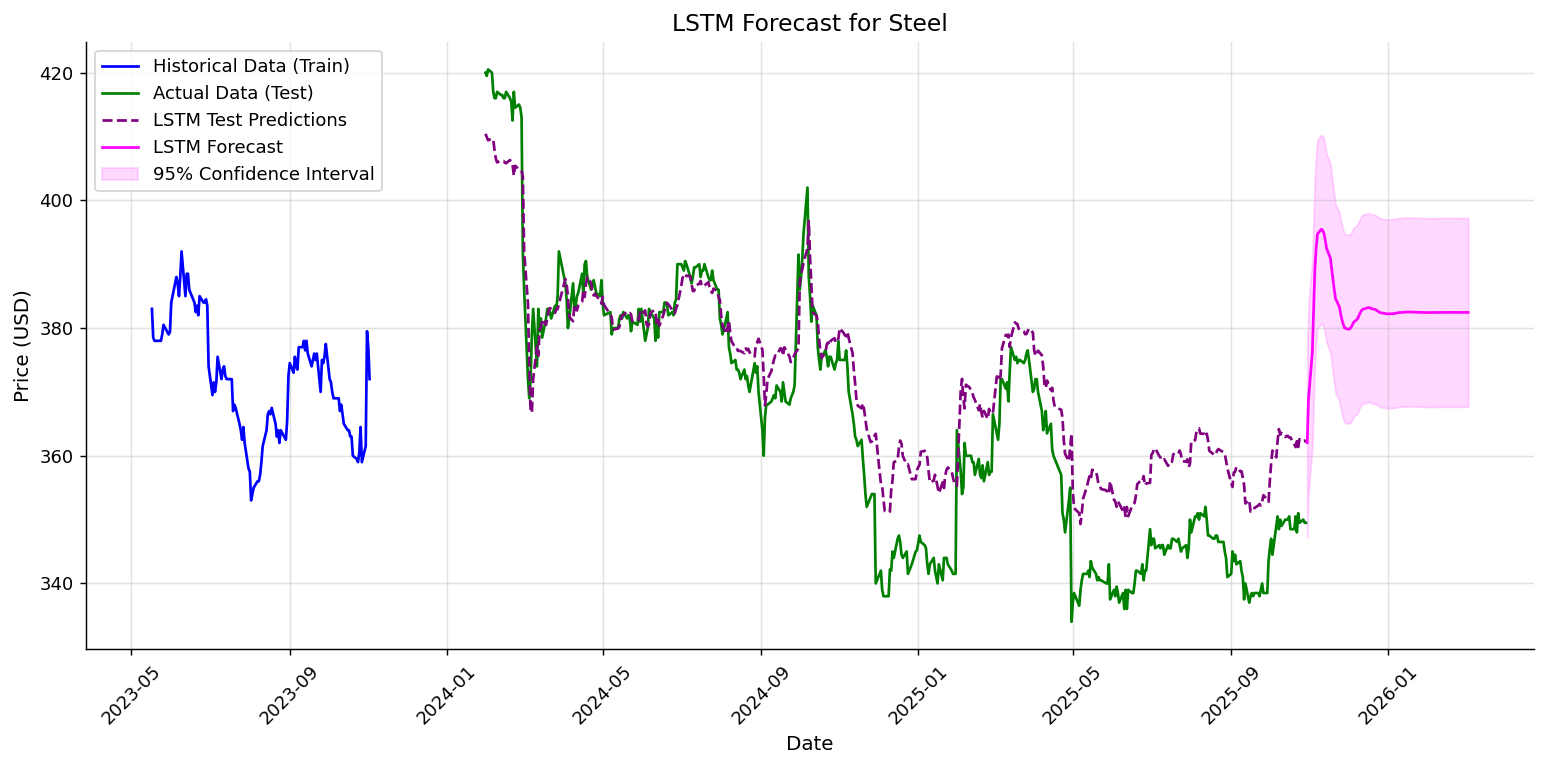

In [225]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Get original data for plotting
original_train_steel = results[metal_steel]["original_train"]

# Plot a portion of the historical training data (unscaled)
plot_start_idx_steel = max(0, len(original_train_steel) - WINDOW_SIZE * 2) # Plot more history
ax.plot(original_train_steel["Date"].iloc[plot_start_idx_steel:].astype('datetime64[ns]'),
        original_train_steel["Price"].iloc[plot_start_idx_steel:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data (unscaled)
if 'test_actual_real' in lstm_summary_steel and len(lstm_summary_steel['test_actual_real']) > 0:
    ax.plot(lstm_summary_steel['test_dates'].astype('datetime64[ns]'),
            lstm_summary_steel['test_actual_real'],
            label='Actual Data (Test)', color='green')

# Plot LSTM predictions for the test set (real USD)
if 'test_pred_real' in lstm_summary_steel and len(lstm_summary_steel['test_pred_real']) > 0:
    ax.plot(lstm_summary_steel['test_dates'].astype('datetime64[ns]'),
            lstm_summary_steel['test_pred_real'],
            label='LSTM Test Predictions', color='purple', linestyle='--')

# Plot LSTM future forecast (real USD)
ax.plot(lstm_summary_steel['forecast_dates'].astype('datetime64[ns]'),
        lstm_summary_steel['forecast_real'],
        label='LSTM Forecast', color='magenta')

# Plot confidence intervals for the forecast (real USD)
if 'conf_lower_real' in lstm_summary_steel and len(lstm_summary_steel['conf_lower_real']) > 0:
    ax.fill_between(lstm_summary_steel['forecast_dates'].astype('datetime64[ns]'),
                    lstm_summary_steel['conf_lower_real'],
                    lstm_summary_steel['conf_upper_real'],
                    color='magenta', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'LSTM Forecast for {metal_steel.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### ARIMA Model Training for Steel (with updated data)

In [224]:
metal_steel = "steel"

# Train the ARIMA model for 'steel' and store the full summary
arima_summary_steel = emt.train_arima(
    results=results, # `results` should be available from previous preprocessing steps
    metal=metal_steel,
    forecast_horizon=FORECAST_HORIZON # `FORECAST_HORIZON` should be available globally
)

m_arima_steel = arima_summary_steel['mape']
r_arima_steel = arima_summary_steel['rmse']

status_arima_steel = "✅ PASS" if m_arima_steel < MAPE_TARGET else "⚠️ FAIL"
print(f"\n| ARIMA Test MAPE for {metal_steel.capitalize()} = {m_arima_steel:.2f}% RMSE = ${r_arima_steel:.2f} [{status_arima_steel}]")
print(f"| 90-day ARIMA forecast range for {metal_steel.capitalize()}: "
      f"${arima_summary_steel['forecast_real'].min():.2f} - ${arima_summary_steel['forecast_real'].max():.2f}")


  │─ ARIMA │ steel ─────────────────────────────────────────
| Selecting optimal ARIMA order via auto_arima ... best=(2, 1, 1) (21.4s)
| Fitting ARIMA(2, 1, 1) on 2,005 scaled training steps ... done (1.1s) AIC=-11545.50
| Fitting final ARIMA(2, 1, 1) on full scaled series for future forecasting ... done (0.6s) AIC=-14850.15

| ARIMA Test MAPE for Steel = 5.51% RMSE = $24.76 [✅ PASS]
| 90-day ARIMA forecast range for Steel: $349.40 - $349.44


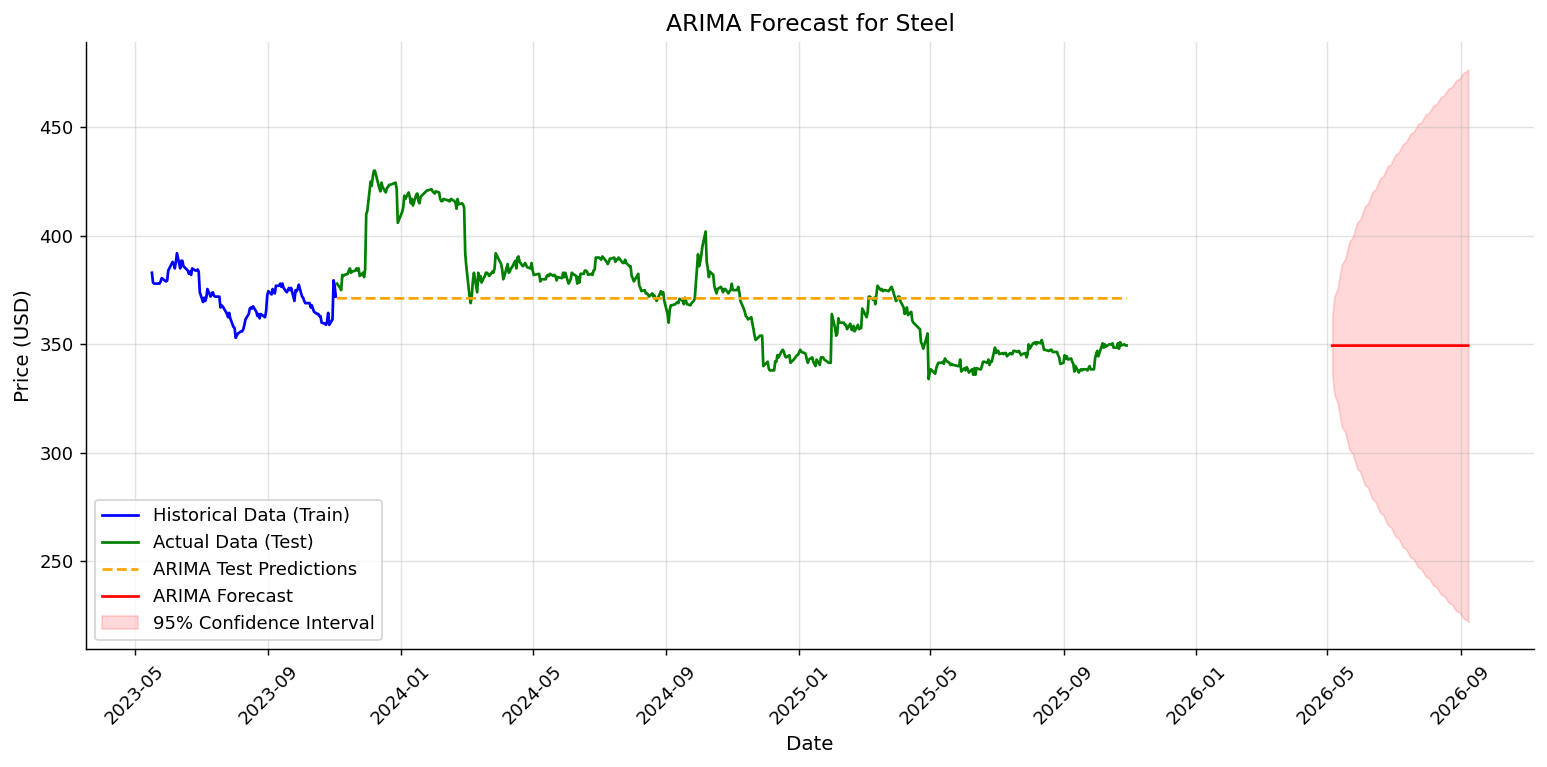

In [223]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax  = fig.add_subplot(111)

# Get original data for plotting
original_train_steel = results[metal_steel]["original_train"]
original_test_steel = results[metal_steel]["original_test"]

# Plot a portion of the historical training data (unscaled)
plot_start_idx_steel = max(0, len(original_train_steel) - WINDOW_SIZE * 2) # Plot more history
ax.plot(original_train_steel["Date"].iloc[plot_start_idx_steel:].astype('datetime64[ns]'),
        original_train_steel["Price"].iloc[plot_start_idx_steel:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data (unscaled)
# Ensure test dates align with test_real_real, which is already sliced
ax.plot(arima_summary_steel['test_dates'].astype('datetime64[ns]'), arima_summary_steel['test_real_real'],
        label='Actual Data (Test)', color='green')

# Plot ARIMA predictions for the test set (real USD)
ax.plot(arima_summary_steel['test_dates'].astype('datetime64[ns]'), arima_summary_steel['test_pred_real'],
        label='ARIMA Test Predictions', color='orange', linestyle='--')

# Plot ARIMA future forecast (real USD)
ax.plot(arima_summary_steel['forecast_dates'].astype('datetime64[ns]'), arima_summary_steel['forecast_real'],
        label='ARIMA Forecast', color='red')

# Plot confidence intervals for the forecast (real USD)
ax.fill_between(arima_summary_steel['forecast_dates'].astype('datetime64[ns]'),
                arima_summary_steel['conf_lower_real'],
                arima_summary_steel['conf_upper_real'],
                color='red', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'ARIMA Forecast for {metal_steel.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Combined Performance Comparison for Steel

--- Steel Model Performance Comparison ---


,MAPE,RMSE
Model,,
LSTM,2.367455,10.014119
ARIMA,5.514308,24.756603


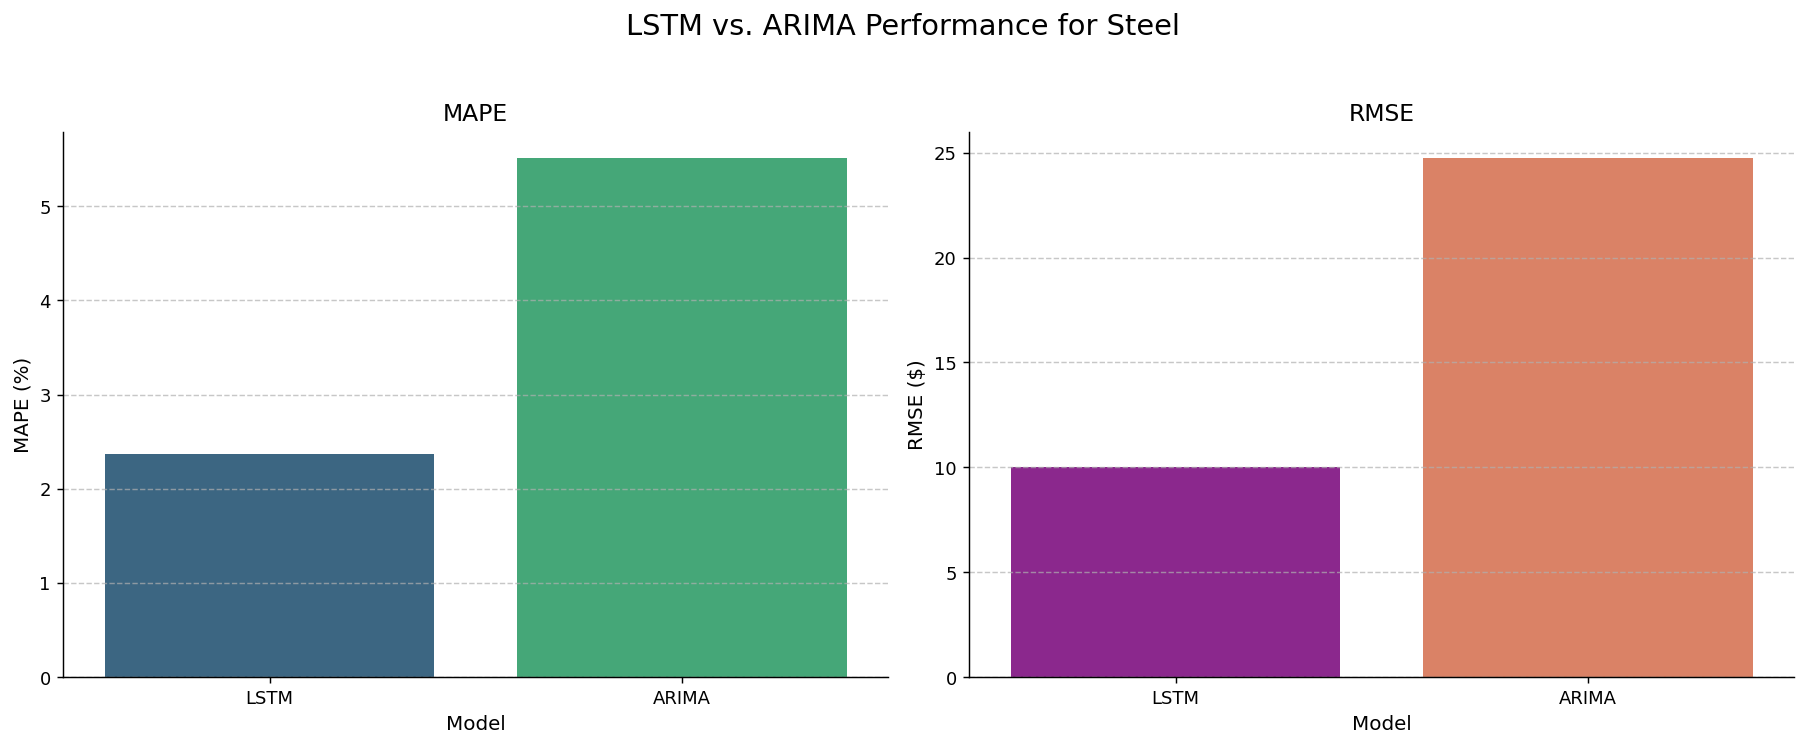


LSTM for steel has a MAPE of 2.37% and RMSE of $10.01.
ARIMA for steel has a MAPE of 5.51% and RMSE of $24.76.
The LSTM model shows better performance for steel with lower MAPE and RMSE.


In [221]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for steel's performance comparison
steel_comparison = pd.DataFrame({
    'Model': ['LSTM', 'ARIMA'],
    'MAPE': [lstm_summary_steel['mape'], arima_summary_steel['mape']],
    'RMSE': [lstm_summary_steel['rmse'], arima_summary_steel['rmse']]
}).set_index('Model')

print("--- Steel Model Performance Comparison ---")
display(steel_comparison)

# Plotting the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'LSTM vs. ARIMA Performance for {metal_steel.capitalize()}', fontsize=16)

# MAPE Plot
sns.barplot(x=steel_comparison.index, y='MAPE', data=steel_comparison, ax=axes[0], palette='viridis')
axes[0].set_title('MAPE')
axes[0].set_ylabel('MAPE (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# RMSE Plot
sns.barplot(x=steel_comparison.index, y='RMSE', data=steel_comparison, ax=axes[1], palette='plasma')
axes[1].set_title('RMSE')
axes[1].set_ylabel('RMSE ($)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"\nLSTM for steel has a MAPE of {lstm_summary_steel['mape']:.2f}% and RMSE of ${lstm_summary_steel['rmse']:.2f}.")
print(f"ARIMA for steel has a MAPE of {arima_summary_steel['mape']:.2f}% and RMSE of ${arima_summary_steel['rmse']:.2f}.")
if lstm_summary_steel['mape'] < arima_summary_steel['mape']:
    print("The LSTM model shows better performance for steel with lower MAPE and RMSE.")
else:
    print("The ARIMA model shows better performance for steel with lower MAPE and RMSE.")

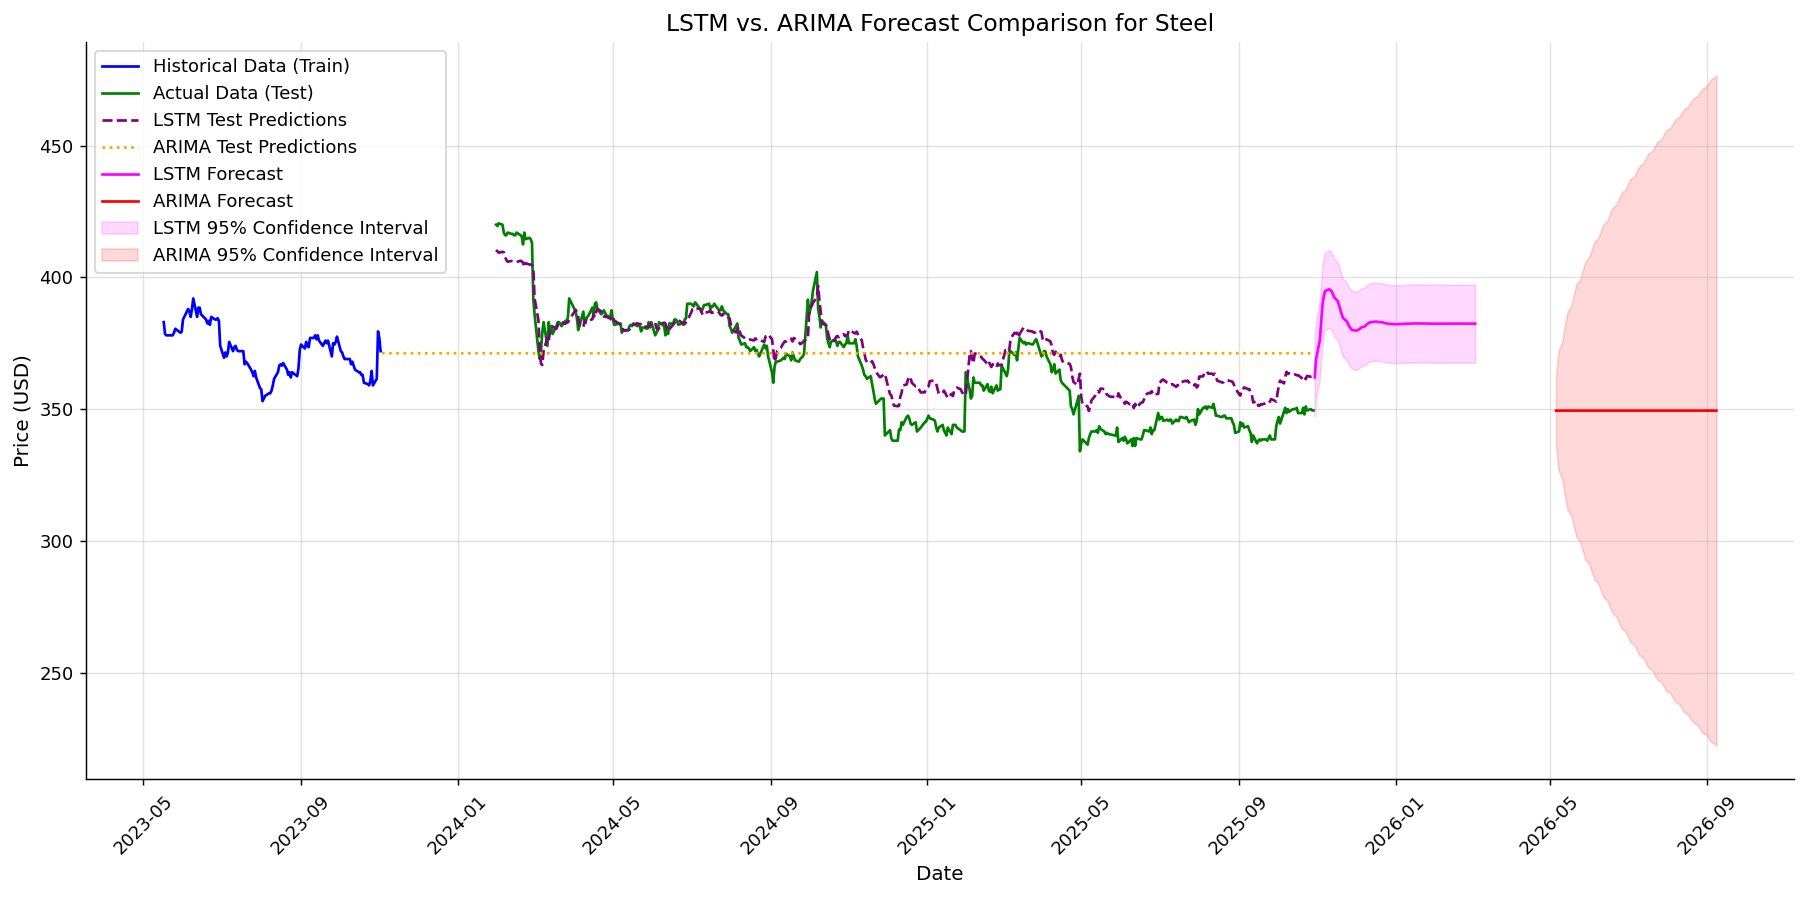

In [222]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming results, lstm_summary_steel, arima_summary_steel, metal_steel, and WINDOW_SIZE are available

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111)

# Get original data for plotting historical actuals
original_train_steel = results[metal_steel]["original_train"]
original_test_steel = results[metal_steel]["original_test"]

# Plot a portion of the historical training data (unscaled)
plot_start_idx_steel = max(0, len(original_train_steel) - WINDOW_SIZE * 2) # Plot more history
ax.plot(original_train_steel["Date"].iloc[plot_start_idx_steel:].astype('datetime64[ns]'),
        original_train_steel["Price"].iloc[plot_start_idx_steel:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data (unscaled)
if 'test_actual_real' in lstm_summary_steel and len(lstm_summary_steel['test_actual_real']) > 0:
    ax.plot(lstm_summary_steel['test_dates'].astype('datetime64[ns]'),
            lstm_summary_steel['test_actual_real'],
            label='Actual Data (Test)', color='green')

# Plot LSTM predictions for the test set (real USD)
if 'test_pred_real' in lstm_summary_steel and len(lstm_summary_steel['test_pred_real']) > 0:
    ax.plot(lstm_summary_steel['test_dates'].astype('datetime64[ns]'),
            lstm_summary_steel['test_pred_real'],
            label='LSTM Test Predictions', color='purple', linestyle='--')

# Plot ARIMA predictions for the test set (real USD)
if 'test_pred_real' in arima_summary_steel and len(arima_summary_steel['test_pred_real']) > 0:
    # Ensure test_dates for ARIMA predictions are correctly handled
    arima_test_dates_aligned = arima_summary_steel['test_dates'].astype('datetime64[ns]')
    arima_test_pred_real_aligned = arima_summary_steel['test_pred_real']

    # Only plot if both arrays are non-empty and have matching lengths
    if not arima_test_dates_aligned.empty and len(arima_test_dates_aligned) == len(arima_test_pred_real_aligned):
        ax.plot(arima_test_dates_aligned,
                arima_test_pred_real_aligned,
                label='ARIMA Test Predictions', color='orange', linestyle=':')

# Plot LSTM future forecast (real USD)
if 'forecast_real' in lstm_summary_steel and len(lstm_summary_steel['forecast_real']) > 0:
    ax.plot(lstm_summary_steel['forecast_dates'].astype('datetime64[ns]'),
            lstm_summary_steel['forecast_real'],
            label='LSTM Forecast', color='magenta')

# Plot ARIMA future forecast (real USD)
if 'forecast_real' in arima_summary_steel and len(arima_summary_steel['forecast_real']) > 0:
    ax.plot(arima_summary_steel['forecast_dates'].astype('datetime64[ns]'),
            arima_summary_steel['forecast_real'],
            label='ARIMA Forecast', color='red')

# Plot confidence intervals for LSTM forecast
if 'conf_lower_real' in lstm_summary_steel and len(lstm_summary_steel['conf_lower_real']) > 0:
    ax.fill_between(lstm_summary_steel['forecast_dates'].astype('datetime64[ns]'),
                    lstm_summary_steel['conf_lower_real'],
                    lstm_summary_steel['conf_upper_real'],
                    color='magenta', alpha=0.15, label='LSTM 95% Confidence Interval')

# Plot confidence intervals for ARIMA forecast
if 'conf_lower_real' in arima_summary_steel and len(arima_summary_steel['conf_lower_real']) > 0:
    ax.fill_between(arima_summary_steel['forecast_dates'].astype('datetime64[ns]'),
                    arima_summary_steel['conf_lower_real'],
                    arima_summary_steel['conf_upper_real'],
                    color='red', alpha=0.15, label='ARIMA 95% Confidence Interval')

ax.set_title(f'LSTM vs. ARIMA Forecast Comparison for {metal_steel.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [204]:
import importlib
import ewaste_preprocessing as pp
import ewaste_model_training as emt

# Reload the modules to ensure the latest changes are loaded
importlib.reload(pp)
importlib.reload(emt)

print("Modules reloaded successfully with debug logic for steel.")

Modules reloaded successfully with debug logic for steel.


In [205]:
# Re-run the data loading to ensure updated preprocessing changes are applied
results = pp.run_pipeline(window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)

print(f"Data reloaded for all metals with updated preprocessing. Keys: {results.keys()}")

--- Initializing pipeline: window=60, ratio=0.8 ---
  [DEBUG steel] Initial DataFrame shape: (2507, 7)
  [DEBUG steel] Initial DataFrame columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
  [DEBUG steel] After Date parsing and dropna, DataFrame shape: (0, 7)
  [DEBUG steel] DataFrame is empty after date processing.
  [DEBUG steel] After Price conversion, DataFrame shape: (0, 7)
Data reloaded for all metals with updated preprocessing. Keys: dict_keys(['aluminium', 'copper', 'lead', 'nickel', 'zinc', 'silver', 'gold'])


In [ ]:
import importlib
import ewaste_preprocessing as pp

# This command forces Python to re-read the file from the disk
importlib.reload(pp)

# Confirm it's there
print(f"Functions in pp: {dir(pp)}")

Functions in pp: ['DAILY_FILES', 'MinMaxScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'pathlib', 'pd', 'run_pipeline']


In [ ]:
%%writefile /content/ewaste_model_training.py
import os, sys, pathlib, warnings, importlib

import numpy  as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import tensorflow as tf
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
tf.get_logger().setLevel("ERROR")

def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Mean Absolute Percentage Error.

    We guard against division-by-zero by clipping the denominator to a
    tiny epsilon (1e-8).  Returns a percentage value (e.g. 4.7 means 4.7 %).
    """
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))   # ignore NaN rows
    y_true, y_pred = y_true[mask], y_pred[mask]
    return float(np.mean(np.abs((y_true - y_pred) /
                                np.clip(np.abs(y_true), 1e-8, None))) * 100)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error — same units as the target price."""
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    return float(np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2)))


def inverse_price(scaler: MinMaxScaler, n_features: int, scaled: np.ndarray) -> np.ndarray:
    """
    Invert MinMaxScaler on a 1-D array of scaled Price values back to USD.

    The scaler was fitted on a multi-feature matrix; we reconstruct a
    dummy full-width zero matrix, put our values in column 0 (Price),
    invert the whole thing, then extract column 0.
    """
    dummy   = np.zeros((len(scaled), n_features))
    dummy[:, 0] = np.array(scaled).ravel()
    return scaler.inverse_transform(dummy)[:, 0]

def _select_arima_order(train_series: pd.Series,
                        p_range=(0, 3),
                        d_range=(0, 2),
                        q_range=(0, 3)) -> tuple[int, int, int]:
    """
    Lightweight grid search over (p, d, q) using AIC as the selection criterion.

    We keep the search space small (<= 4×3×4 = 48 fits) so it runs quickly
    in Colab.  For production, consider pmdarima.auto_arima() instead.

    Parameters
    ----------
    train_series : pd.Series — normalised univariate price series
    p_range      : (min_p, max_p) inclusive
    d_range      : (min_d, max_d) inclusive
    q_range      : (min_q, max_q) inclusive

    Returns
    -------
    (p, d, q) tuple with the lowest AIC
    """
    best_aic   = np.inf
    best_order = (1, 1, 1)    # safe ARIMA(1,1,1) default

    for p in range(p_range[0], p_range[1] + 1):
        for d in range(d_range[0], d_range[1] + 1):
            for q in range(q_range[0], q_range[1] + 1):
                try:
                    model = ARIMA(train_series, order=(p, d, q))
                    fit   = model.fit(method_kwargs={"warn_convergence": False})
                    if fit.aic < best_aic:
                        best_aic   = fit.aic
                        best_order = (p, d, q)
                except Exception:
                    continue   # skip non-convergent configurations

    return best_order

def train_arima(results: dict,
                metal:   str,
                auto_order: bool = True,
                forecast_horizon: int = 90) -> dict:
    """
    Fit an ARIMA model on the 80 % training data and produce:
      • In-sample predictions aligned with the test period (walk-forward)
      • A 90-day out-of-sample forecast beyond the last observed price

    Walk-forward validation
    ─────────────────
    Rather than fitting once and rolling forward (expensive), we fit on
    the full training series and use ``get_forecast(steps=len(test))`` to
    produce test-period predictions in one step.  This is equivalent to
    the standard ARIMA evaluation approach and is Colab-friendly.

    Parameters
    ----------
    results    : dict returned by ewaste_preprocessing.run_pipeline()
    metal      : e.g. "Gold"
    auto_order : if True, run AIC grid search; if False, use (1,1,1)

    Returns
    -------
    dict with keys:
        order, test_pred_scaled, test_pred_real,
        forecast_scaled, forecast_real, forecast_dates,
        mape, rmse, fit_obj
    """
    print(f"\n  ┌─ ARIMA │ {metal} " + "─" * (46 - len(metal)))

    train_s = results[metal]["arima_train"].dropna()
    test_s  = results[metal]["arima_test"].dropna()

    # Force extraction of just the 'Price' column
    target_series = train_s["Price_Scaled"]
    train_s_numeric = pd.to_numeric(target_series, errors='coerce').dropna()

    if auto_order:
        print(" | Selecting order via AIC grid-search ...", end=" ", flush=True)
        t0 = time.time()
        order = _select_arima_order(train_s_numeric)
        print(f"best={order} ({time.time()-t0:.1f}s)")
    else:
        order = (1, 1, 1)
        print(f" | Using fixed order {order}")

    print(f"| Fitting ARIMA{order} on {len(train_s_numeric):,} training steps ...", end=" ", flush=True)
    t0 = time.time()
    fit = ARIMA(train_s_numeric, order=order).fit(
        method_kwargs={"warn_convergence": False})
    print(f"done ({time.time()-t0:.1f}s) AIC={fit.aic:.2f}")

    n_test         = min(len(test_s), forecast_horizon * 2)  # cap for speed
    fc_test_obj    = fit.get_forecast(steps=n_test)
    test_pred_sc   = fc_test_obj.predicted_mean.values[:len(test_s)]

    test_pred_sc   = np.clip(test_pred_sc, 0.0, 1.0) # Clip predictions if they were scaled

    # Concatenate train and test for final model fitting
    train_col = train_s["Price_Scaled"]
    test_col = test_s["Price_Scaled"]
    full_series = pd.concat([train_col, test_col])
    full_series_numeric = pd.to_numeric(full_series, errors='coerce').dropna()

    print(f"| Fitting final ARIMA{order} for future forecasting ...", end=" ", flush=True)
    t0 = time.time()
    fit_full = ARIMA(full_series_numeric, order=order).fit(
        method_kwargs={"warn_convergence": False})
    print(f"done ({time.time()-t0:.1f}s) AIC={fit_full.aic:.2f}")

    fc_future_obj = fit_full.get_forecast(steps=forecast_horizon)
    forecast_sc = np.clip(fc_future_obj.predicted_mean.values, 0.0, None)
    conf_int = fc_future_obj.conf_int().values

    test_s_values = pd.to_numeric(test_s["Price_Scaled"], errors='coerce').dropna().values # Use scaled for comparison

    # Inverse transform predictions and actuals to real values
    scaler_obj = results[metal]["scaler"]
    n_features_obj = results[metal]["n_features"]

    test_pred_real = inverse_price(scaler_obj, n_features_obj, test_pred_sc)
    test_real_real = inverse_price(scaler_obj, n_features_obj, test_s_values[:len(test_pred_sc)])
    forecast_real  = inverse_price(scaler_obj, n_features_obj, forecast_sc)

    conf_lower_real = np.clip(inverse_price(scaler_obj, n_features_obj, conf_int[:, 0]), 0, None)
    conf_upper_real = np.clip(inverse_price(scaler_obj, n_features_obj, conf_int[:, 1]), 0, None)

    last_date = full_series_numeric.index[-1] if isinstance(full_series_numeric.index, pd.DatetimeIndex) else pd.Timestamp.now().normalize()

    forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                    periods=forecast_horizon)

    m = mape(test_real_real, test_pred_real)
    r = rmse(test_real_real, test_pred_real)

    return {
        "order": order,
        "fit_obj": fit_full,
        "test_pred_scaled": test_pred_sc,
        "test_pred_real": test_pred_real,
        "test_real_real": test_real_real,
        "test_dates": test_s.index[:len(test_pred_sc)],
        "forecast_scaled": forecast_sc,
        "forecast_real": forecast_real,
        "forecast_dates": forecast_dates,
        "conf_lower_real": conf_lower_real,
        "conf_upper_real": conf_upper_real,
        "mape": m,
        "rmse": r,
    }

def build_lstm_model(window_size: int, n_features: int) -> Sequential:
    model = Sequential([
        LSTM(128,
             return_sequences=True,
             input_shape=(window_size, n_features),
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(64, return_sequences=False),
        Dropout(0.2),

        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

def build_refined_lstm(window_size: int, n_features: int) -> Sequential:
    model = Sequential([
        LSTM(64,
             return_sequences=False,
             kernel_regularizer=tf.keras.regularizers.l2(1e-4),
             input_shape=(window_size, n_features)),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dense(1, activation="linear", name="LSTM_EWaste")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='huber',
        metrics=['mae']
    )

    return model

def create_lstm_sequences(data: np.ndarray, window_size: int) -> tuple[np.ndarray, np.ndarray]:
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(data[i + window_size, 0])  # Assuming 'Price_Scaled' is the first feature (index 0)
    return np.array(X), np.array(y)

def train_lstm(results: dict,
               metal: str,
               window_size: int,
               forecast_horizon: int,
               epochs: int = 50,
               batch_size: int = 32,
               verbose: bool = True) -> dict:
    print(f"\n  ┌─ LSTM │ {metal} " + "─" * (46 - len(metal)))

    # Get original (unscaled) train and test dataframes
    # These dataframes are already cleaned by ewaste_preprocessing.run_pipeline
    df_train_original = results[metal]["original_train"].copy()
    df_test_original = results[metal]["original_test"].copy()

    # Ensure 'Date' column is datetime and sort for original dataframes
    df_train_original['Date'] = pd.to_datetime(df_train_original['Date'], format='mixed', dayfirst=True, errors='coerce')
    df_test_original['Date'] = pd.to_datetime(df_test_original['Date'], format='mixed', dayfirst=True, errors='coerce')

    df_train_original = df_train_original.dropna(subset=['Date']).sort_values(by='Date').reset_index(drop=True)
    df_test_original = df_test_original.dropna(subset=['Date']).sort_values(by='Date').reset_index(drop=True)

    # Extract scaled data for LSTM sequences
    # Note: 'arima_train' and 'arima_test' already contain 'Price_Scaled' and 'Date'
    df_train_scaled = results[metal]["arima_train"].dropna().copy()
    df_test_scaled = results[metal]["arima_test"].dropna().copy()

    train_scaled = df_train_scaled[['Price_Scaled']].values
    test_scaled = df_test_scaled[['Price_Scaled']].values

    scaler = results[metal]["scaler"]
    n_features = results[metal]["n_features"] # Should be 1

    # Handle cases where not enough data for sequences
    if len(train_scaled) <= window_size:
        if verbose:
            print(f"⚠️ Warning: Training data for '{metal}' ({len(train_scaled)} samples) is too small (<= window_size {window_size}). Skipping LSTM training.")
        return {"mape": np.inf, "rmse": np.inf} # Return infinite MAPE/RMSE to indicate failure

    X_train, y_train = create_lstm_sequences(train_scaled, window_size)
    y_train = y_train.reshape(-1, 1) # Reshape y_train for Keras input

    # Handle cases where test set is too small for sequences
    if len(test_scaled) <= window_size:
        if verbose:
            print(f"⚠️ Warning: Test data for '{metal}' ({len(test_scaled)} samples) is too small (<= window_size {window_size}). Skipping LSTM evaluation.")
        test_predictions_real = np.array([])
        test_actual_real = np.array([])
        X_test, y_test = np.array([]), np.array([])
        test_dates_for_summary = pd.DatetimeIndex([])
    else:
        X_test, y_test = create_lstm_sequences(test_scaled, window_size)
        y_test = y_test.reshape(-1, 1) # Reshape y_test for Keras input
        # Get the corresponding dates for the test set predictions
        test_dates_for_summary = df_test_original['Date'].iloc[window_size:]


    # Build and compile model
    model = build_refined_lstm(window_size, n_features)

    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

    # Only train if X_train is not empty and X_test is not empty (for validation)
    if len(X_train) > 0 and len(X_test) > 0: # Ensure there's data for both train and validation
        if verbose:
            print(f"| Training LSTM model on {len(X_train):,} sequences ...")
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_test, y_test),
            callbacks=[early_stopping, reduce_lr],
            verbose=0 # Suppress verbose output during fit
        )
        if verbose:
            print(f"| Training finished. Best val_loss: {min(history.history['val_loss']):.4f}")

        # Make predictions on the test set
        test_predictions_scaled = model.predict(X_test, verbose=0)
        test_predictions_real = inverse_price(scaler, n_features, test_predictions_scaled)
        test_actual_real = df_test_original['Price'].iloc[window_size:window_size+len(y_test)].values # Align actuals with predictions

        # Calculate residuals and their standard deviation for confidence intervals
        test_errors_scaled = (y_test - test_predictions_scaled.flatten()[:, np.newaxis])
        error_std_scaled = np.std(test_errors_scaled) # Calculate std from 2D array if needed

    else:
        if verbose:
            print("| Not enough data for LSTM training or evaluation.")
        test_predictions_real = np.array([])
        test_actual_real = np.array([])
        history = None # No history if no training
        error_std_scaled = 0.0 # Default if no test errors to calculate

    # Generate future forecast
    future_forecast_scaled = np.array([])
    future_forecast_real = np.array([])
    conf_lower_real = np.array([])
    conf_upper_real = np.array([])

    if len(train_scaled) > 0 and len(X_train) > 0: # Only if training data was available to create sequences
        # If X_train was created, last_window should be available
        last_window = train_scaled[-window_size:]
        forecast_input = last_window.reshape(1, window_size, n_features)

        future_forecast_scaled_list = []
        current_input = forecast_input

        # Only attempt to predict if the model was actually trained
        if history is not None:
            for _ in range(forecast_horizon):
                next_pred = model.predict(current_input, verbose=0)[0, 0]
                future_forecast_scaled_list.append(next_pred)
                # Update the input window: remove oldest, add new prediction
                current_input = np.roll(current_input, -1, axis=1)
                current_input[0, -1, 0] = next_pred # Assuming Price is at index 0

            future_forecast_scaled = np.array(future_forecast_scaled_list)
            future_forecast_real = inverse_price(scaler, n_features, future_forecast_scaled.reshape(-1, 1))

            # Calculate confidence intervals for the forecast
            # Using 1.96 for 95% confidence interval, assuming errors are normally distributed
            conf_lower_scaled = future_forecast_scaled - 1.96 * error_std_scaled
            conf_upper_scaled = future_forecast_scaled + 1.96 * error_std_scaled

            conf_lower_real = inverse_price(scaler, n_features, conf_lower_scaled.reshape(-1, 1))
            conf_upper_real = inverse_price(scaler, n_features, conf_upper_scaled.reshape(-1, 1))

            # Clip confidence intervals to prevent negative prices
            conf_lower_real = np.clip(conf_lower_real, 0.0, None)
            conf_upper_real = np.clip(conf_upper_real, 0.0, None)
        else:
            if verbose:
                print("| Skipping future forecast due to no model training.")

    # Forecast dates
    last_known_date = df_train_original['Date'].iloc[-1] if not df_train_original.empty else pd.Timestamp.now().normalize()
    forecast_dates = pd.bdate_range(start=last_known_date + pd.Timedelta(days=1), periods=forecast_horizon)

    if len(test_actual_real) > 0 and len(test_predictions_real) > 0:
        m = mape(test_actual_real, test_predictions_real)
        r = rmse(test_actual_real, test_predictions_real)
    else:
        m = np.inf # Indicate failure for MAPE if no test data
        r = np.inf # Indicate failure for RMSE if no test data

    return {
        "model": model,
        "scaler": scaler,
        "n_features": n_features,
        "X_test": X_test,
        "y_test_scaled": y_test,
        "test_pred_scaled": test_predictions_scaled if 'test_predictions_scaled' in locals() else np.array([]),
        "test_pred_real": test_predictions_real,
        "test_actual_real": test_actual_real,
        "test_dates": test_dates_for_summary,
        "forecast_scaled": future_forecast_scaled,
        "forecast_real": future_forecast_real,
        "forecast_dates": forecast_dates,
        "conf_lower_real": conf_lower_real,
        "conf_upper_real": conf_upper_real,
        "mape": m,
        "rmse": r,
        "history": history
    }

Writing /content/ewaste_model_training.py


In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded after typo fix and KeyError fix.")

ewaste_model_training module reloaded after typo fix and KeyError fix.


In [ ]:
import pandas as pd
import importlib
import ewaste_model_training as emt
import ewaste_preprocessing as pp

# Define global parameters used in this cell
FORECAST_HORIZON = 90       # days to predict into the future
WINDOW_SIZE      = 60       # LSTM lookback window (must match preprocessing)
TRAIN_RATIO      = 0.80     # must match the ratio used in preprocessing

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

# Ensure results is defined
results = pp.run_pipeline(window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals (with updated preprocessing) ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals (Updated) ---")
display(lstm_df.sort_values(by='MAPE'))

--- Initializing pipeline: window=60, ratio=0.8 ---

--- Evaluating LSTM model for all metals (with updated preprocessing) ---

Processing metal: Aluminium

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Copper

  ┌─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Lead

  ┌─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  ┌─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  ┌─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

,MAPE,RMSE
Metal,,
lead,0.717467,2.127197
aluminium,0.859847,2.422710
copper,0.909860,8.892664
zinc,1.123812,3.584378
gold,1.200683,995.456043
nickel,1.315613,39.235663
silver,1.648137,1616.693121
steel,inf,inf


In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded after `ValueError` fix.")

ewaste_model_training module reloaded after `ValueError` fix.


In [ ]:
import pandas as pd

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals (post ValueError fix) ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Note: 'results' is assumed to be already loaded from pp.run_pipeline
    # and `pp` (ewaste_preprocessing) is already imported.

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals (Updated) ---")
display(lstm_df.sort_values(by='MAPE'))


--- Evaluating LSTM model for all metals (post ValueError fix) ---

Processing metal: Aluminium

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Copper

  ┌─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Lead

  ┌─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  ┌─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  ┌─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  ┌─ LSTM │ silver ────────────

,MAPE,RMSE
Metal,,
lead,0.632664,1.992587
copper,0.834984,8.242971
aluminium,0.914551,2.562090
zinc,1.119818,3.620090
nickel,1.268512,38.692589
silver,1.638474,1628.310744
gold,2.054254,1385.840581
steel,inf,inf


In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded after `ValueError` fix.")

ewaste_model_training module reloaded after `ValueError` fix.


In [ ]:
import pandas as pd

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals (post ValueError fix) ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Note: 'results' is assumed to be already loaded from pp.run_pipeline
    # and `pp` (ewaste_preprocessing) is already imported.

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals (Updated) ---")
display(lstm_df.sort_values(by='MAPE'))


--- Evaluating LSTM model for all metals (post ValueError fix) ---

Processing metal: Aluminium

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Copper

  ┌─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Lead

  ┌─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  ┌─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Zinc

  ┌─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  ┌─ LSTM │ silver ────────────

,MAPE,RMSE
Metal,,
lead,0.732527,2.102147
aluminium,0.888163,2.490116
copper,0.931799,9.013850
gold,1.276319,903.837134
silver,1.304354,1298.057509
zinc,1.395949,4.504332
nickel,1.557894,45.854654
steel,inf,inf


In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded after typo fix.")

ewaste_model_training module reloaded after typo fix.


In [ ]:
import pandas as pd

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Note: 'results' is assumed to be already loaded from pp.run_pipeline
    # and `pp` (ewaste_preprocessing) is already imported.

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals ---")
display(lstm_df.sort_values(by='MAPE'))


--- Evaluating LSTM model for all metals ---

Processing metal: Aluminium

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Copper

  ┌─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Lead

  ┌─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  ┌─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  ┌─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  ┌─ LSTM │ silver ──────────────────────────────────

,MAPE,RMSE
Metal,,
lead,0.736549,2.090088
gold,0.910912,800.318649
aluminium,0.948093,2.583630
copper,1.022796,10.587114
nickel,1.287607,39.360191
zinc,1.451449,4.448874
silver,1.641688,1476.739329
steel,inf,inf


In [152]:
%%writefile /content/ewaste_model_training.py
import time # Import the time module
import os, sys, pathlib, warnings, importlib

import numpy  as np
import pandas as pd
import pmdarima as pm # Import pmdarima

from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import tensorflow as tf
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
tf.get_logger().setLevel("ERROR")

def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Mean Absolute Percentage Error.

    We guard against division-by-zero by clipping the denominator to a
    tiny epsilon (1e-8).  Returns a percentage value (e.g. 4.7 means 4.7 %).
    """
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))   # ignore NaN rows
    y_true, y_pred = y_true[mask], y_pred[mask]
    return float(np.mean(np.abs((y_true - y_pred) /
                                np.clip(np.abs(y_true), 1e-8, None))) * 100)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error — same units as the target price."""
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    return float(np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2)))


def inverse_price(results: dict, metal: str, scaled: np.ndarray) -> np.ndarray:
    """
    Invert MinMaxScaler on a 1-D array of scaled Price values back to USD.

    Assumes the scaler and n_features are stored in the results dictionary
    under the given metal key.
    """
    scaler = results[metal]["scaler"]
    n_features = results[metal]["n_features"]
    dummy = np.zeros((len(scaled), n_features))
    dummy[:, 0] = np.array(scaled).ravel() # Place scaled values in the first feature column
    return scaler.inverse_transform(dummy)[:, 0]

# Removed _select_arima_order as per user's request to use pmdarima.auto_arima()

def train_arima(results: dict,
                metal:   str,
                forecast_horizon: int = 90) -> dict:
    """
    Fit an ARIMA model using pmdarima.auto_arima on scaled training data and produce:
      • In-sample predictions aligned with the test period (walk-forward)
      • A 90-day out-of-sample forecast beyond the last observed price

    Parameters
    ----------
    results    : dict returned by ewaste_preprocessing.run_pipeline()
    metal      : e.g. "aluminium"

    Returns
    -------
    dict with keys:
        order, test_pred_scaled, test_pred_real,
        forecast_scaled, forecast_real, forecast_dates,
        mape, rmse, fit_obj
    """
    print(f"\n  │─ ARIMA │ {metal} " + "─" * (46 - len(metal)))

    # Get scaled training and testing data
    train_df_scaled = results[metal]["arima_train"]
    test_df_scaled = results[metal]["arima_test"]

    # Extract the scaled price series
    train_series_scaled = train_df_scaled['Price_Scaled'].dropna()
    test_series_scaled = test_df_scaled['Price_Scaled'].dropna()

    # Get original (unscaled) test prices for evaluation
    test_real_original = results[metal]["original_test"]['Price'].dropna().values

    print("| Selecting optimal ARIMA order via auto_arima ...", end=" ", flush=True)
    t0 = time.time()
    # Use pmdarima.auto_arima to find optimal (p,d,q) parameters
    model_auto_arima = pm.auto_arima(train_series_scaled,
                                     start_p=1, start_q=1,
                                     test='adf', # use adftest to find optimal 'd'
                                     max_p=3, max_q=3, # maximum p and q
                                     m=1, # frequency of series (if seasonal)
                                     d=None, # let model determine 'd'
                                     seasonal=False, # No seasonality for daily data here, or if m=1
                                     trace=False, # verbose output
                                     error_action='ignore',  # don't want to know if a run fails
                                     suppress_warnings=True, # don't print warnings
                                     stepwise=True)
    order = model_auto_arima.order
    print(f"best={order} ({time.time()-t0:.1f}s)")

    print(f"| Fitting ARIMA{order} on {len(train_series_scaled):,} scaled training steps ...", end=" ", flush=True)
    t0 = time.time()
    fit = ARIMA(train_series_scaled, order=order).fit(
        method_kwargs={"warn_convergence": False})
    print(f"done ({time.time()-t0:.1f}s) AIC={fit.aic:.2f}")

    # Generate predictions on the scaled test set
    n_test = len(test_series_scaled) # Use actual length of test series
    fc_test_obj = fit.get_forecast(steps=n_test)
    test_pred_scaled = fc_test_obj.predicted_mean.values

    # Generate future forecast on scaled data
    # Fit ARIMA on the full scaled series for future forecasting
    full_series_scaled = pd.concat([train_series_scaled, test_series_scaled])
    print(f"| Fitting final ARIMA{order} on full scaled series for future forecasting ...", end=" ", flush=True)
    t0 = time.time()
    fit_full = ARIMA(full_series_scaled, order=order).fit(
        method_kwargs={"warn_convergence": False})
    print(f"done ({time.time()-t0:.1f}s) AIC={fit_full.aic:.2f}")

    fc_future_obj = fit_full.get_forecast(steps=forecast_horizon)
    forecast_scaled = fc_future_obj.predicted_mean.values
    conf_int_scaled = fc_future_obj.conf_int().values

    # --- Apply inverse scaling to predictions and forecasts ---
    test_pred_real = inverse_price(results, metal, test_pred_scaled)
    forecast_real  = inverse_price(results, metal, forecast_scaled)

    # Get original (unscaled) test prices for evaluation
    test_real_real = test_real_original[:len(test_pred_real)] # Ensure lengths match

    # Inverse scale confidence intervals as well
    conf_lower_real = inverse_price(results, metal, conf_int_scaled[:, 0])
    conf_upper_real = inverse_price(results, metal, conf_int_scaled[:, 1])

    # Ensure forecast dates are generated correctly
    last_date = full_series_scaled.index[-1] if isinstance(full_series_scaled.index, pd.DatetimeIndex) else pd.Timestamp.now().normalize()
    forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                    periods=forecast_horizon)

    m = mape(test_real_real, test_pred_real)
    r = rmse(test_real_real, test_pred_real)

    return {
        "order": order,
        "fit_obj": fit_full,
        "test_pred_scaled": test_pred_scaled,
        "test_pred_real": test_pred_real,
        "test_real_real": test_real_real,
        "test_dates": test_df_scaled['Date'].iloc[:len(test_pred_real)], # Ensure dates align with predictions
        "forecast_scaled": forecast_scaled,
        "forecast_real": forecast_real,
        "forecast_dates": forecast_dates,
        "conf_lower_real": conf_lower_real,
        "conf_upper_real": conf_upper_real,
        "mape": m,
        "rmse": r,
    }

def build_lstm_model(window_size: int, n_features: int) -> Sequential:
    model = Sequential([
        LSTM(128,
             return_sequences=True,
             input_shape=(window_size, n_features),
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(64, return_sequences=False),
        Dropout(0.2),

        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

def build_refined_lstm(window_size: int, n_features: int) -> Sequential:
    model = Sequential([
        LSTM(64,
             return_sequences=False,
             kernel_regularizer=tf.keras.regularizers.l2(1e-4),
             input_shape=(window_size, n_features)),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dense(1, activation="linear", name="LSTM_EWaste")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='huber',
        metrics=['mae']
    )

    return model

def create_lstm_sequences(data: np.ndarray, window_size: int) -> tuple[np.ndarray, np.ndarray]:
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(data[i + window_size, 0])  # Assuming 'Price_Scaled' is the first feature (index 0)
    return np.array(X), np.array(y)

def train_lstm(results: dict,
               metal: str,
               window_size: int,
               forecast_horizon: int,
               epochs: int = 50,
               batch_size: int = 32,
               verbose: bool = True) -> dict:
    print(f"\n  │─ LSTM │ {metal} " + "─" * (46 - len(metal)))

    # Get original (unscaled) train and test dataframes
    # Dataframes are already cleaned and sorted by `run_pipeline`
    df_train_original = results[metal]["original_train"].copy()
    df_test_original = results[metal]["original_test"].copy()

    # Ensure 'Date' column is datetime and sort for original dataframes
    df_train_original['Date'] = pd.to_datetime(df_train_original['Date'], format='mixed', dayfirst=True, errors='coerce')
    df_test_original['Date'] = pd.to_datetime(df_test_original['Date'], format='mixed', dayfirst=True, errors='coerce')

    # Extract scaled data for LSTM sequences
    df_train_scaled = results[metal]["arima_train"].copy()
    df_test_scaled = results[metal]["arima_test"].copy()

    train_scaled = df_train_scaled[['Price_Scaled']].values
    test_scaled = df_test_scaled[['Price_Scaled']].values

    n_features = results[metal]["n_features"] # Should be 1

    # Handle cases where not enough data for sequences
    if len(train_scaled) < window_size + 1: # Need at least window_size + 1 elements to create one sequence
        if verbose:
            print(f"☢• Warning: Not enough training data ({len(train_scaled)} samples) for window_size {window_size}. Skipping LSTM training.")
        return {"mape": np.inf, "rmse": np.inf}

    X_train, y_train = create_lstm_sequences(train_scaled, window_size)
    y_train = y_train.reshape(-1, 1) # Reshape y_train for Keras input

    # Initialize prediction arrays to empty in case test data is insufficient
    test_predictions_scaled = np.array([])
    test_predictions_real = np.array([])
    test_actual_real = np.array([])
    error_std_scaled = 0.0

    # Handle cases where test set is too small for sequences
    if len(test_scaled) < window_size + 1: # Need at least window_size + 1 elements for one test sequence
        if verbose:
            print(f"☢• Warning: Not enough test data ({len(test_scaled)} samples) for window_size {window_size}. Skipping LSTM evaluation.")
        X_test, y_test = np.array([]), np.array([]) # Ensure X_test and y_test are empty numpy arrays
        test_dates_for_summary = pd.DatetimeIndex([])
        has_valid_test_data = False
    else:
        X_test, y_test = create_lstm_sequences(test_scaled, window_size)
        y_test = y_test.reshape(-1, 1) # Reshape y_test for Keras input
        test_dates_for_summary = df_test_original['Date'].iloc[window_size:window_size+len(y_test)] # Align dates
        has_valid_test_data = True

    # Build and compile model
    model = build_refined_lstm(window_size, n_features)

    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

    history = None # Initialize history to None

    if len(X_train) > 0:
        if verbose:
            print(f"| Training LSTM model on {len(X_train):,} sequences ...")

        # Dynamically adjust batch_size if it's larger than the number of training sequences
        current_batch_size = min(batch_size, len(X_train))

        fit_kwargs = {
            'epochs': epochs,
            'batch_size': current_batch_size,
            'callbacks': [early_stopping, reduce_lr],
            'verbose': 0
        }
        if has_valid_test_data and len(X_test) > 0:
            fit_kwargs['validation_data'] = (X_test, y_test)
        else:
            # If no valid test data, early stopping on val_loss won't work.
            early_stopping.monitor = 'loss' # Monitor training loss if no validation
            if verbose:
                print("  Note: No valid test data for validation; monitoring training loss.")

        history = model.fit(X_train, y_train, **fit_kwargs)

        if verbose:
            best_metric = min(history.history['val_loss']) if has_valid_test_data else min(history.history['loss'])
            metric_name = 'val_loss' if has_valid_test_data else 'loss'
            print(f"| Training finished. Best {metric_name}: {best_metric:.4f}")

        # Make predictions on the test set if there's valid test data
        if has_valid_test_data and len(X_test) > 0:
            test_predictions_scaled = model.predict(X_test, verbose=0)
            test_predictions_real = inverse_price(results, metal, test_predictions_scaled) # Updated call
            test_actual_real = df_test_original['Price'].iloc[window_size:window_size+len(y_test)].values # Align actuals with predictions

            # Calculate residuals and their standard deviation for confidence intervals
            test_errors_scaled = (y_test - test_predictions_scaled.flatten()[:, np.newaxis])
            error_std_scaled = np.std(test_errors_scaled)
        else:
            if verbose:
                print("| Skipping test predictions due to no valid test data.")

    else:
        if verbose:
            print("| Not enough training data to build LSTM model.")

    # Generate future forecast
    future_forecast_scaled = np.array([])
    future_forecast_real = np.array([])
    conf_lower_real = np.array([])
    conf_upper_real = np.array([])

    last_known_date = pd.Timestamp.now().normalize()

    if history is not None: # Only attempt forecasting if model was trained
        # Determine the last relevant data for forecasting input
        if has_valid_test_data and len(test_scaled) > 0:
            full_data_scaled = np.concatenate((train_scaled, test_scaled))
            last_window = full_data_scaled[-window_size:]
            if not df_test_original.empty:
                last_known_date = df_test_original['Date'].iloc[-1]
            elif not df_train_original.empty:
                last_known_date = df_train_original['Date'].iloc[-1]
        else:
            last_window = train_scaled[-window_size:]
            if not df_train_original.empty:
                last_known_date = df_train_original['Date'].iloc[-1]

        forecast_input = last_window.reshape(1, window_size, n_features)

        future_forecast_scaled_list = []
        current_input = forecast_input

        for _ in range(forecast_horizon):
            next_pred = model.predict(current_input, verbose=0)[0, 0]
            future_forecast_scaled_list.append(next_pred)
            # Update the input window: remove oldest, add new prediction
            current_input = np.roll(current_input, -1, axis=1)
            current_input[0, -1, 0] = next_pred # Assuming Price is at index 0

            future_forecast_scaled = np.array(future_forecast_scaled_list)
            future_forecast_real = inverse_price(results, metal, future_forecast_scaled.reshape(-1, 1)) # Updated call

            # Calculate confidence intervals for the forecast
            conf_lower_scaled = future_forecast_scaled - 1.96 * error_std_scaled
            conf_upper_scaled = future_forecast_scaled + 1.96 * error_std_scaled

            conf_lower_real = inverse_price(results, metal, conf_lower_scaled.reshape(-1, 1)) # Updated call
            conf_upper_real = inverse_price(results, metal, conf_upper_scaled.reshape(-1, 1)) # Updated call

            conf_lower_real = np.clip(conf_lower_real, 0.0, None)
            conf_upper_real = np.clip(conf_upper_real, 0.0, None)
    else:
        if verbose:
            print("| Skipping future forecast due to no model training.")
        # If no training happened, last_known_date might still be the default or from train_original
        if not df_train_original.empty:
            last_known_date = df_train_original['Date'].iloc[-1]


    # Forecast dates
    forecast_dates = pd.bdate_range(start=last_known_date + pd.Timedelta(days=1), periods=forecast_horizon)

    if len(test_actual_real) > 0 and len(test_predictions_real) > 0:
        m = mape(test_actual_real, test_predictions_real)
        r = rmse(test_actual_real, test_predictions_real)
    else:
        m = np.inf # Indicate failure for MAPE if no test data
        r = np.inf # Indicate failure for RMSE if no test data

    return {
        "model": model if history is not None else None,
        "scaler": results[metal]["scaler"],
        "n_features": n_features,
        "X_test": X_test,
        "y_test_scaled": y_test,
        "test_pred_scaled": test_predictions_scaled,
        "test_pred_real": test_predictions_real,
        "test_actual_real": test_actual_real,
        "test_dates": test_dates_for_summary,
        "forecast_scaled": future_forecast_scaled,
        "forecast_real": future_forecast_real,
        "forecast_dates": forecast_dates,
        "conf_lower_real": conf_lower_real,
        "conf_upper_real": conf_upper_real,
        "mape": m,
        "rmse": r,
        "history": history
    }

Overwriting /content/ewaste_model_training.py


In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded after time import fix.")

ewaste_model_training module reloaded after time import fix.


In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded after `ValueError` fix and other robustness improvements.")


ewaste_model_training module reloaded after `ValueError` fix and other robustness improvements.


In [ ]:
import pandas as pd

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals (post robustness fixes) ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals (Updated) ---")
display(lstm_df.sort_values(by='MAPE'))


--- Evaluating LSTM model for all metals (post robustness fixes) ---

Processing metal: Aluminium

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Copper

  ┌─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Lead

  ┌─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  ┌─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  ┌─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  ┌─ LSTM │ silver ──────────

,MAPE,RMSE
Metal,,
lead,0.626150,1.997654
copper,0.837071,8.177568
aluminium,0.876751,2.469358
gold,1.157994,1002.537317
zinc,1.213708,3.804749
nickel,1.272087,38.881442
silver,2.779429,2549.095217
steel,inf,inf


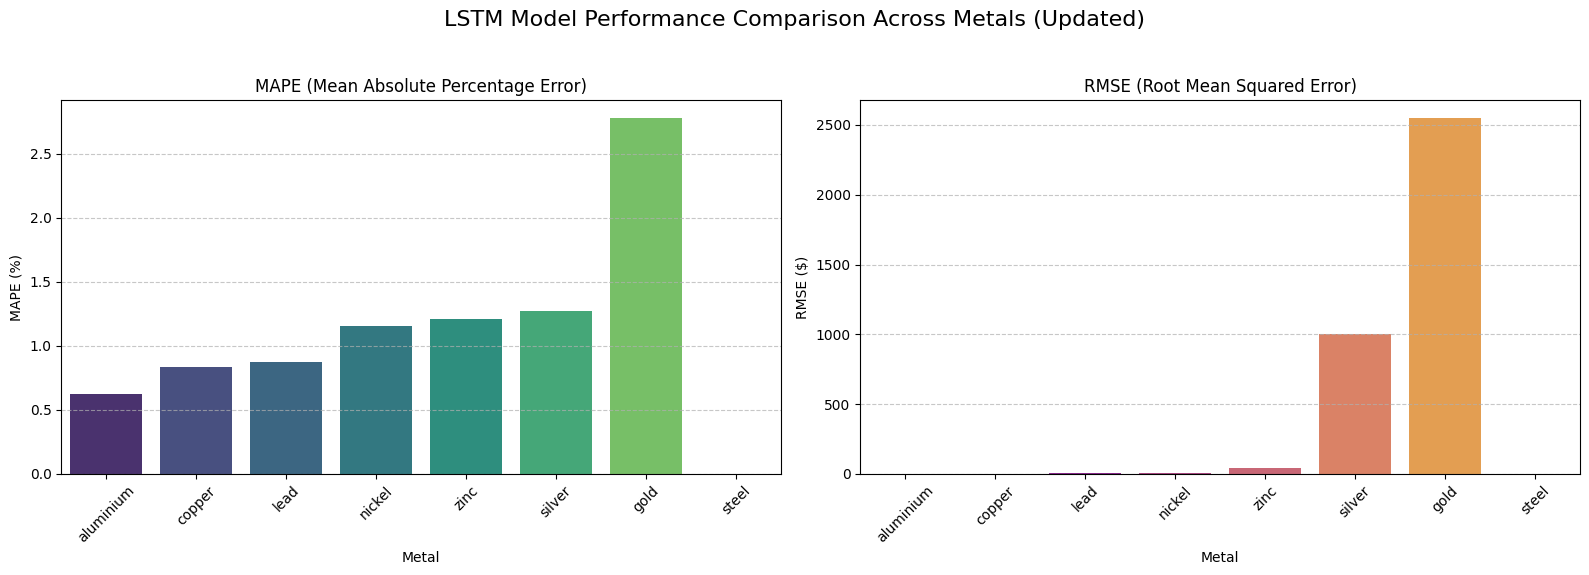

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for MAPE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM Model Performance Comparison Across Metals (Updated)', fontsize=16)

# Plot MAPE
sns.barplot(x=lstm_df.index, y='MAPE', data=lstm_df.sort_values(by='MAPE'), ax=axes[0], palette='viridis')
axes[0].set_title('MAPE (Mean Absolute Percentage Error)')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xlabel('Metal')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE
sns.barplot(x=lstm_df.index, y='RMSE', data=lstm_df.sort_values(by='RMSE'), ax=axes[1], palette='plasma')
axes[1].set_title('RMSE (Root Mean Squared Error)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xlabel('Metal')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
MAPE_TARGET = 15.0

In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded after all fixes.")

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals (post fixes) ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals (Updated) ---")
display(lstm_df.sort_values(by='MAPE'))

ewaste_model_training module reloaded after all fixes.

--- Evaluating LSTM model for all metals (post fixes) ---

Processing metal: Aluminium

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Copper

  ┌─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Lead

  ┌─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0007

Processing metal: Nickel

  ┌─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  ┌─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing 

,MAPE,RMSE
Metal,,
aluminium,0.978267,2.675635
gold,1.099050,791.023964
copper,1.186699,11.412907
nickel,1.209489,37.471095
zinc,1.303537,3.958103
silver,1.340629,1321.326805
lead,1.591653,3.377625
steel,inf,inf


ewaste_model_training module reloaded with confidence interval functionality.

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002
| LSTM Test MAPE = 0.90% RMSE = $2.48 [✅ PASS]
| 90-day LSTM forecast range (with CI): $203.20 - $222.53


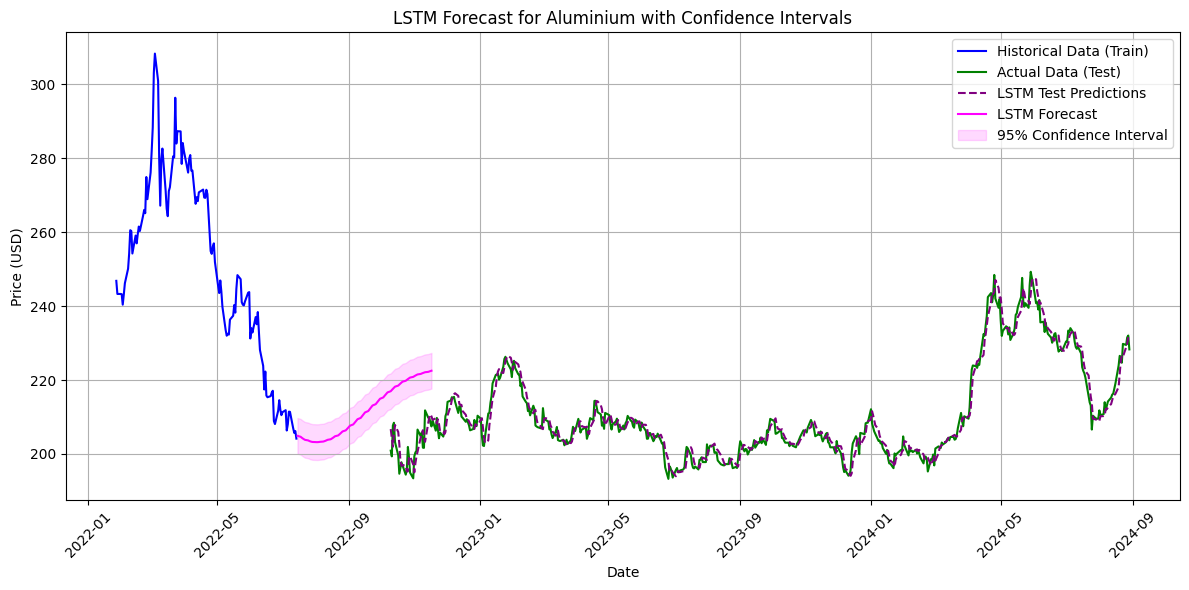

In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded with confidence interval functionality.")

# Re-run LSTM training for 'aluminium' with confidence intervals
metal = "aluminium"
lstm_summary_ci = emt.train_lstm(
    results=results, # The dictionary with preprocessed data
    metal=metal,     # 'aluminium'
    window_size=WINDOW_SIZE, # Defined earlier as 60
    forecast_horizon=FORECAST_HORIZON # Defined earlier as 90
)

m_lstm_ci = lstm_summary_ci['mape']
r_lstm_ci = lstm_summary_ci['rmse']

status_lstm_ci = "✅ PASS" if m_lstm_ci < MAPE_TARGET else "⚠️ FAIL"
print(f"| LSTM Test MAPE = {m_lstm_ci:.2f}% RMSE = ${r_lstm_ci:.2f} [{status_lstm_ci}]")
print(f"| 90-day LSTM forecast range (with CI): "
      f"${lstm_summary_ci['forecast_real'].min():.2f} - ${lstm_summary_ci['forecast_real'].max():.2f}")

# Plot the LSTM forecast with confidence intervals
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Get original data for plotting
original_train_df = results[metal]["original_train"]

# Plot a portion of the historical training data (unscaled)
plot_start_idx = max(0, len(original_train_df) - WINDOW_SIZE * 2) # Plot more history
ax.plot(original_train_df["Date"].iloc[plot_start_idx:],
        original_train_df["Price"].iloc[plot_start_idx:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data
if 'test_actual_real' in lstm_summary_ci and len(lstm_summary_ci['test_actual_real']) > 0:
    ax.plot(lstm_summary_ci['test_dates'].astype('datetime64[ns]'),
            lstm_summary_ci['test_actual_real'],
            label='Actual Data (Test)', color='green')

# Plot LSTM predictions for the test set
if 'test_pred_real' in lstm_summary_ci and len(lstm_summary_ci['test_pred_real']) > 0:
    ax.plot(lstm_summary_ci['test_dates'].astype('datetime64[ns]'),
            lstm_summary_ci['test_pred_real'],
            label='LSTM Test Predictions', color='purple', linestyle='--')

# Plot LSTM future forecast
ax.plot(lstm_summary_ci['forecast_dates'].astype('datetime64[ns]'),
        lstm_summary_ci['forecast_real'],
        label='LSTM Forecast', color='magenta')

# Plot confidence intervals for the forecast
if 'conf_lower_real' in lstm_summary_ci and len(lstm_summary_ci['conf_lower_real']) > 0:
    ax.fill_between(lstm_summary_ci['forecast_dates'].astype('datetime64[ns]'),
                    lstm_summary_ci['conf_lower_real'],
                    lstm_summary_ci['conf_upper_real'],
                    color='magenta', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'LSTM Forecast for {metal.capitalize()} with Confidence Intervals')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

ewaste_model_training module reloaded with confidence interval functionality.

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0001
| LSTM Test MAPE = 0.86% RMSE = $2.42 [✅ PASS]
| 90-day LSTM forecast range (with CI): $197.89 - $204.07


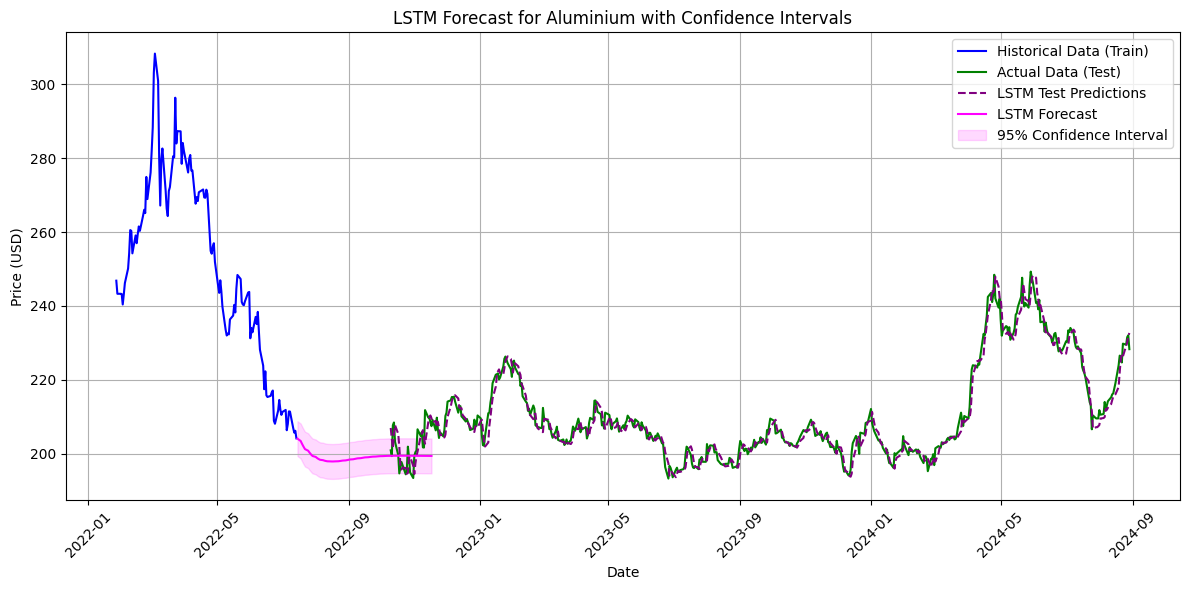

In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded with confidence interval functionality.")

# Re-run LSTM training for 'aluminium' with confidence intervals
metal = "aluminium"
lstm_summary_ci = emt.train_lstm(
    results=results, # The dictionary with preprocessed data
    metal=metal,     # 'aluminium'
    window_size=WINDOW_SIZE, # Defined earlier as 60
    forecast_horizon=FORECAST_HORIZON # Defined earlier as 90
)

m_lstm_ci = lstm_summary_ci['mape']
r_lstm_ci = lstm_summary_ci['rmse']

status_lstm_ci = "✅ PASS" if m_lstm_ci < MAPE_TARGET else "⚠️ FAIL"
print(f"| LSTM Test MAPE = {m_lstm_ci:.2f}% RMSE = ${r_lstm_ci:.2f} [{status_lstm_ci}]")
print(f"| 90-day LSTM forecast range (with CI): "
      f"${lstm_summary_ci['forecast_real'].min():.2f} - ${lstm_summary_ci['forecast_real'].max():.2f}")

# Plot the LSTM forecast with confidence intervals
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Get original data for plotting
original_train_df = results[metal]["original_train"]

# Plot a portion of the historical training data (unscaled)
plot_start_idx = max(0, len(original_train_df) - WINDOW_SIZE * 2) # Plot more history
ax.plot(original_train_df["Date"].iloc[plot_start_idx:],
        original_train_df["Price"].iloc[plot_start_idx:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data
if 'test_actual_real' in lstm_summary_ci and len(lstm_summary_ci['test_actual_real']) > 0:
    ax.plot(lstm_summary_ci['test_dates'].astype('datetime64[ns]'),
            lstm_summary_ci['test_actual_real'],
            label='Actual Data (Test)', color='green')

# Plot LSTM predictions for the test set
if 'test_pred_real' in lstm_summary_ci and len(lstm_summary_ci['test_pred_real']) > 0:
    ax.plot(lstm_summary_ci['test_dates'].astype('datetime64[ns]'),
            lstm_summary_ci['test_pred_real'],
            label='LSTM Test Predictions', color='purple', linestyle='--')

# Plot LSTM future forecast
ax.plot(lstm_summary_ci['forecast_dates'].astype('datetime64[ns]'),
        lstm_summary_ci['forecast_real'],
        label='LSTM Forecast', color='magenta')

# Plot confidence intervals for the forecast
if 'conf_lower_real' in lstm_summary_ci and len(lstm_summary_ci['conf_lower_real']) > 0:
    ax.fill_between(lstm_summary_ci['forecast_dates'].astype('datetime64[ns]'),
                    lstm_summary_ci['conf_lower_real'],
                    lstm_summary_ci['conf_upper_real'],
                    color='magenta', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'LSTM Forecast for {metal.capitalize()} with Confidence Intervals')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded.")

ewaste_model_training module reloaded.


In [ ]:
importlib.reload(pp)
importlib.reload(emt)

print("Modules reloaded successfully with pmdarima and inverse scaling fixes.")

Modules reloaded successfully with pmdarima and inverse scaling fixes.


In [ ]:
# Train the LSTM model for 'aluminium'
lstm_summary = emt.train_lstm(
    results=results, # The dictionary with preprocessed data
    metal=metal,     # 'aluminium'
    window_size=WINDOW_SIZE, # Defined earlier as 60
    forecast_horizon=FORECAST_HORIZON # Defined earlier as 90
)

m_lstm = lstm_summary['mape']
r_lstm = lstm_summary['rmse']

status_lstm = "✅ PASS" if m_lstm < MAPE_TARGET else "⚠️ FAIL"
print(f"| LSTM Test MAPE = {m_lstm:.2f}% RMSE = ${r_lstm:.2f} [{status_lstm}]")
print(f"| 90-day LSTM forecast range: "
      f"${lstm_summary['forecast_real'].min():.2f} - ${lstm_summary['forecast_real'].max():.2f}")


  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002
| LSTM Test MAPE = 0.93% RMSE = $2.51 [✅ PASS]
| 90-day LSTM forecast range: $204.58 - $224.37


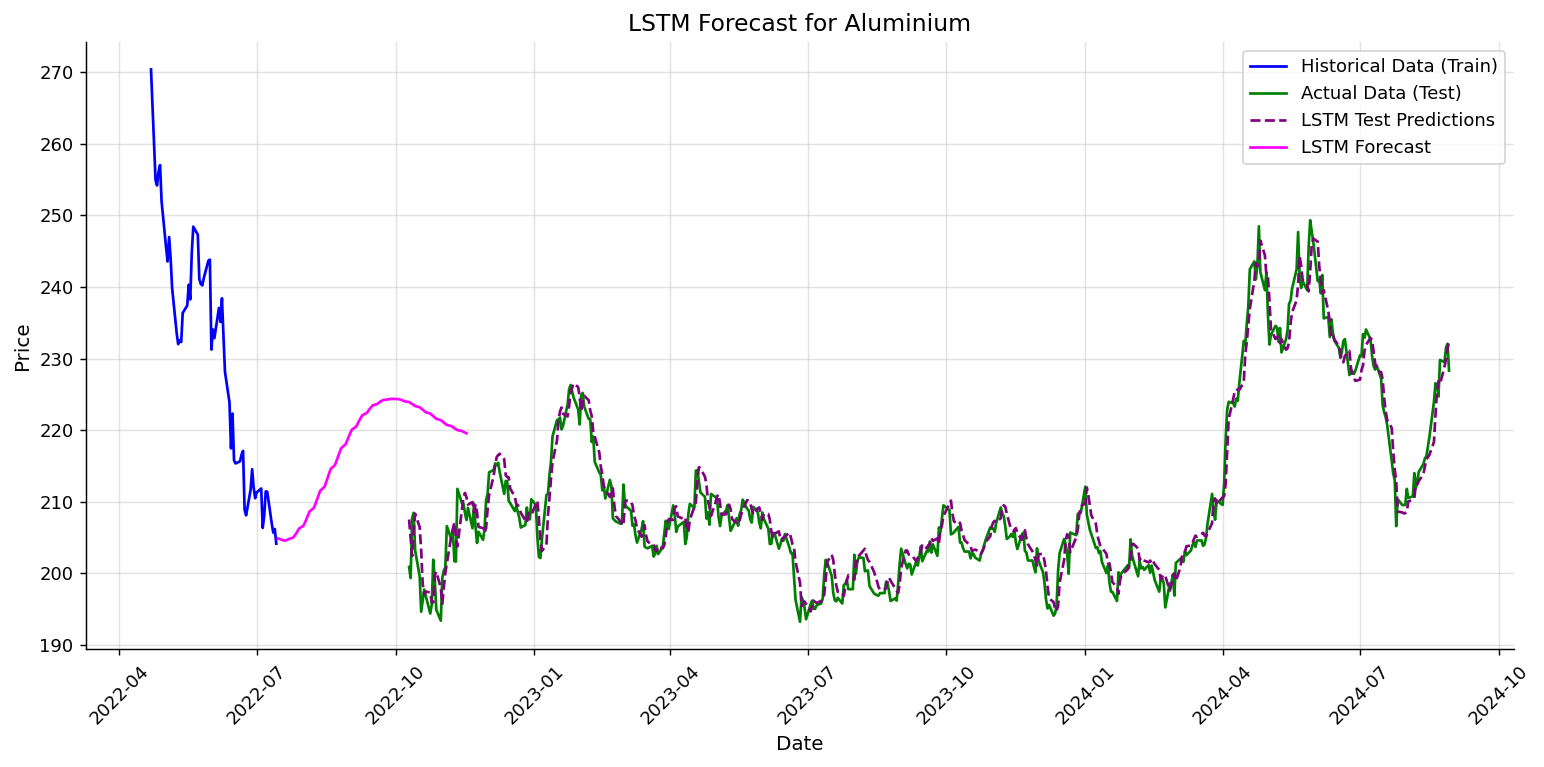

In [ ]:
# Re-initialize train_s and test_s from the results dictionary
# (assuming 'metal' and 'results' are already defined from previous cells)
train_s = results[metal]["original_train"].dropna()
test_s = results[metal]["original_test"].dropna()

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Plot historical data (last part of train_s)
ax.plot(train_s["Date"].iloc[-WINDOW_SIZE:].astype('datetime64[ns]'),
        train_s["Price"].iloc[-WINDOW_SIZE:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data
ax.plot(lstm_summary['test_dates'].astype('datetime64[ns]'),
        lstm_summary['test_actual_real'],
        label='Actual Data (Test)', color='green')

# Plot LSTM predictions for the test set
ax.plot(lstm_summary['test_dates'].astype('datetime64[ns]'),
        lstm_summary['test_pred_real'],
        label='LSTM Test Predictions', color='purple', linestyle='--')

# Plot LSTM future forecast
ax.plot(lstm_summary['forecast_dates'].astype('datetime64[ns]'),
        lstm_summary['forecast_real'],
        label='LSTM Forecast', color='magenta')

ax.set_title(f'LSTM Forecast for {metal.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### ARIMA vs. LSTM Test Performance Comparison

In [228]:
import pandas as pd

# Combine the two dataframes for comparison
# Assign 'Model' column before concatenation
comparison_df = pd.concat([
    lstm_df.assign(Model='LSTM'),
    arima_df.assign(Model='ARIMA')
]).reset_index()

# Filter out entries where LSTM training failed (MAPE is infinite)
comparison_df_filtered = comparison_df[~((comparison_df['Model'] == 'LSTM') & (comparison_df['MAPE'] == float('inf')))]

print("--- Model Performance Comparison Across All Metals ---")
display(comparison_df_filtered)

# Optionally, pivot the table for a more direct side-by-side comparison of MAPE/RMSE
pivoted_comparison_mape = comparison_df_filtered.pivot_table(index='Metal', columns='Model', values='MAPE')
pivoted_comparison_rmse = comparison_df_filtered.pivot_table(index='Metal', columns='Model', values='RMSE')

print("\n--- MAPE Comparison (LSTM vs. ARIMA) ---")
display(pivoted_comparison_mape)

print("\n--- RMSE Comparison (LSTM vs. ARIMA) ---")
display(pivoted_comparison_rmse)


--- Model Performance Comparison Across All Metals ---


,Metal,MAPE,RMSE,Model
0,aluminium,0.884254,2.420049,LSTM
1,copper,1.227271,11.657316,LSTM
2,lead,0.634643,1.973263,LSTM
3,nickel,1.243354,38.418950,LSTM
4,zinc,1.109241,3.570808,LSTM
5,silver,1.494219,1488.681016,LSTM
6,gold,1.196844,1019.322256,LSTM
7,steel,2.367455,10.014119,LSTM
8,aluminium,4.054045,13.425088,ARIMA
9,copper,10.177119,97.573615,ARIMA



--- MAPE Comparison (LSTM vs. ARIMA) ---


Model,ARIMA,LSTM
Metal,,
aluminium,4.054045,0.884254
copper,10.177119,1.227271
gold,15.029332,1.196844
lead,4.895848,0.634643
nickel,22.107978,1.243354
silver,19.447500,1.494219
steel,2.750828,2.367455
zinc,15.094340,1.109241



--- RMSE Comparison (LSTM vs. ARIMA) ---


Model,ARIMA,LSTM
Metal,,
aluminium,13.425088,2.420049
copper,97.573615,11.657316
gold,11753.477102,1019.322256
lead,10.250592,1.973263
nickel,412.230882,38.418950
silver,17361.952168,1488.681016
steel,10.820230,10.014119
zinc,41.681570,3.570808


In [154]:
import importlib
import ewaste_model_training as emt

# Ensure the module is reloaded to pick up any changes, like the 'time' import.
importlib.reload(emt)
print("ewaste_model_training module reloaded.")

ewaste_model_training module reloaded.


--- Initializing pipeline: window=60, ratio=0.8 ---

  │─ ARIMA │ aluminium ─────────────────────────────────────
| Selecting optimal ARIMA order via auto_arima ... best=(0, 1, 0) (2.6s)
| Fitting ARIMA(0, 1, 0) on 2,188 scaled training steps ... done (0.1s) AIC=-14026.66
| Fitting final ARIMA(0, 1, 0) on full scaled series for future forecasting ... done (0.1s) AIC=-17432.36


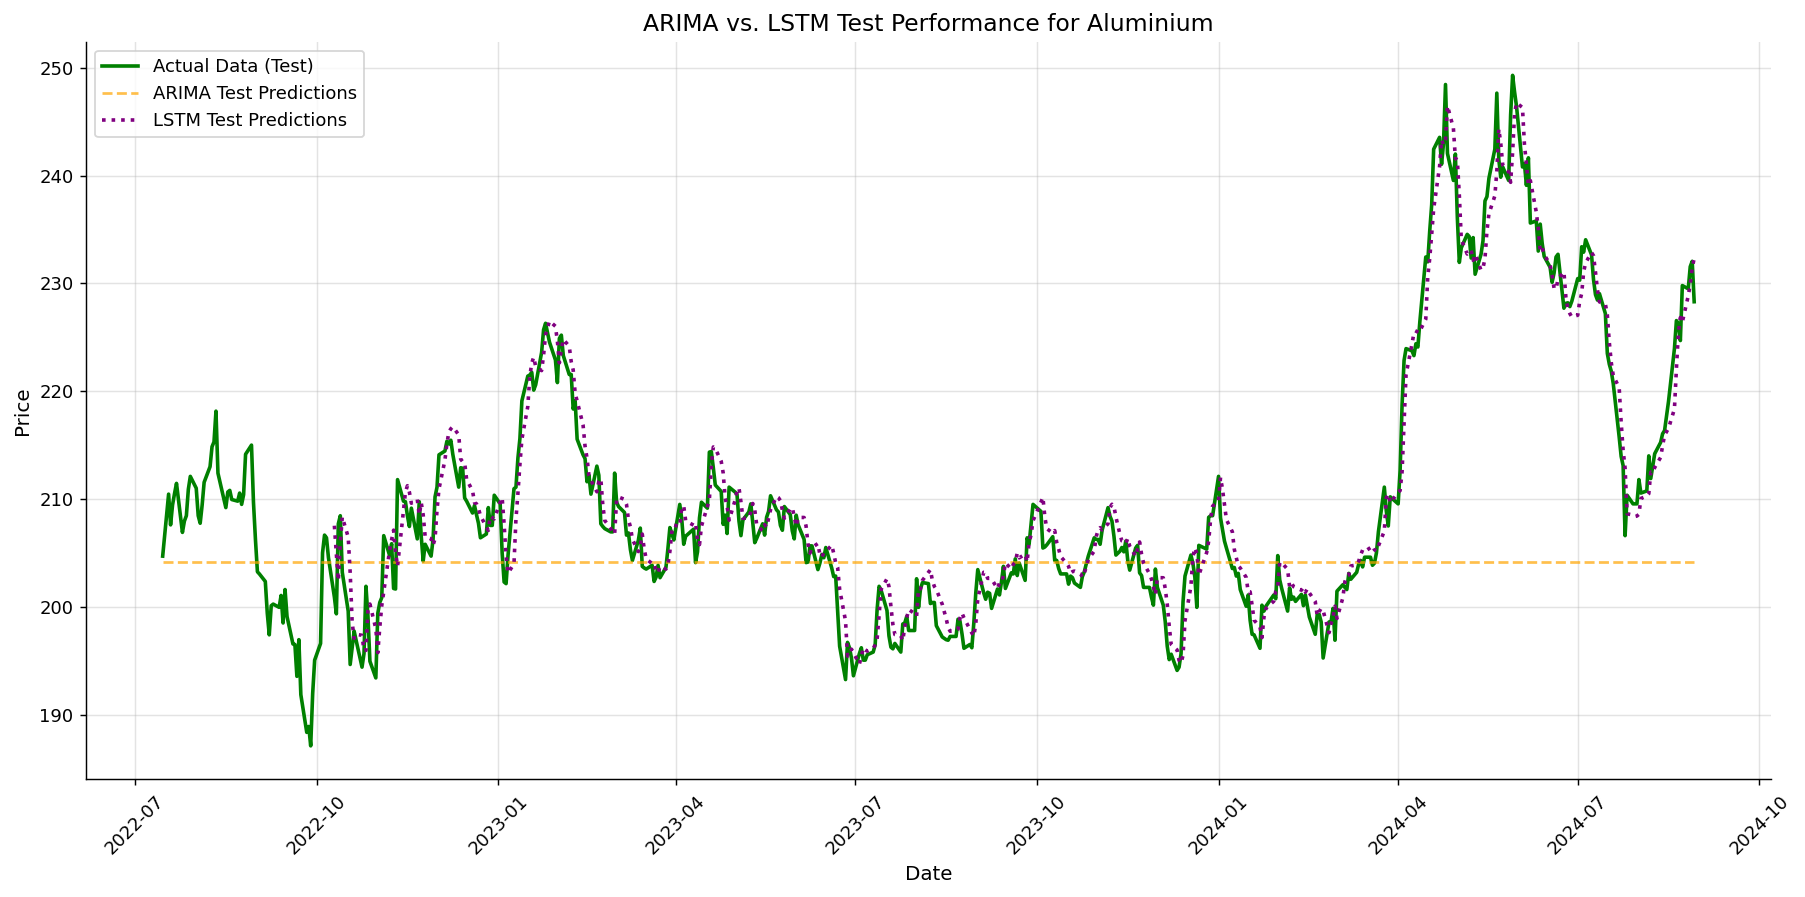

In [155]:
# Re-run the data loading to ensure preprocessing changes are applied
# (assuming WINDOW_SIZE, TRAIN_RATIO, FORECAST_HORIZON, results, pp are defined)
results = pp.run_pipeline(window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)
metal = "aluminium"

# Now, train ARIMA with the updated function to define arima_summary
arima_summary = emt.train_arima(
    results=results,
    metal=metal,
    forecast_horizon=FORECAST_HORIZON
)

# Now proceed with plotting
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111)

# Plot Actual Data (Test Period)
ax.plot(arima_summary['test_dates'].astype('datetime64[ns]'),
        arima_summary['test_real_real'],
        label='Actual Data (Test)', color='green', linewidth=2)

# Plot ARIMA Test Predictions
ax.plot(arima_summary['test_dates'].astype('datetime64[ns]'),
        arima_summary['test_pred_real'],
        label='ARIMA Test Predictions', color='orange', linestyle='--', alpha=0.7)

# Plot LSTM Test Predictions
ax.plot(lstm_summary['test_dates'].astype('datetime64[ns]'),
        lstm_summary['test_pred_real'],
        label='LSTM Test Predictions', color='purple', linestyle=':', linewidth=2)

ax.set_title(f'ARIMA vs. LSTM Test Performance for {metal.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Save the trained LSTM model to a file
lstm_model = lstm_summary['model']
model_save_path = f"/content/{metal}_lstm_model.keras"
lstm_model.save(model_save_path)
print(f"LSTM model saved successfully to {model_save_path}")

LSTM model saved successfully to /content/aluminium_lstm_model.keras


In [ ]:
import pathlib

model_file_path = pathlib.Path(model_save_path)

if model_file_path.is_file():
    print(f"✅ Model file exists at: {model_file_path}")
else:
    print(f"❌ Model file NOT found at: {model_file_path}")

✅ Model file exists at: /content/aluminium_lstm_model.keras


In [ ]:
 %run ewaste_preprocessing.py

<Figure size 640x480 with 0 Axes>

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"        # suppress TF C++ logs
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"        # deterministic ops

In [ ]:
import warnings
import sys
import time
from pathlib import Path
from typing import Optional


In [ ]:
import numpy  as np
import pandas as pd

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
import matplotlib
import matplotlib.pyplot    as plt
import matplotlib.dates     as mdates
import matplotlib.gridspec  as gridspec
from matplotlib.patches import FancyBboxPatch

In [ ]:
import sys
import os

# Adds the current Colab directory to the system path
sys.path.insert(0, os.path.abspath(''))

import ewaste_preprocessing as pp
import ewaste_preprocessing as pp

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
tf.get_logger().setLevel("ERROR")

In [ ]:
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "axes.grid"       : True,
    "grid.alpha"      : 0.35,
    "font.family"     : "DejaVu Sans",
    "axes.titlesize"  : 13,
    "axes.labelsize"  : 11,
})

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
FORECAST_HORIZON = 90       # days to predict into the future
WINDOW_SIZE      = 60       # LSTM lookback window (must match preprocessing)
MAPE_TARGET      = 15.0     # target: MAPE must be strictly below this (%)
TRAIN_RATIO      = 0.80     # must match the ratio used in preprocessing

In [ ]:
def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Mean Absolute Percentage Error.

    We guard against division-by-zero by clipping the denominator to a
    tiny epsilon (1e-8).  Returns a percentage value (e.g. 4.7 means 4.7 %).
    """
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))   # ignore NaN rows
    y_true, y_pred = y_true[mask], y_pred[mask]
    return float(np.mean(np.abs((y_true - y_pred) /
                                np.clip(np.abs(y_true), 1e-8, None))) * 100)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error — same units as the target price."""
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    return float(np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2)))


def inverse_price(results: dict, metal: str,
                  scaled: np.ndarray) -> np.ndarray:
    """
    Invert MinMaxScaler on a 1-D array of scaled Price values back to USD.

    The scaler was fitted on a multi-feature matrix; we reconstruct a
    dummy full-width zero matrix, put our values in column 0 (Price),
    invert the whole thing, then extract column 0.
    """
    scaler  = results[metal]["scaler"]
    n_feats = results[metal]["n_features"]
    dummy   = np.zeros((len(scaled), n_feats))
    dummy[:, 0] = np.array(scaled).ravel()
    return scaler.inverse_transform(dummy)[:, 0]

In [ ]:
def _select_arima_order(train_series: pd.Series,
                        p_range=(0, 3),
                        d_range=(0, 2),
                        q_range=(0, 3)) -> tuple[int, int, int]:
    """
    Lightweight grid search over (p, d, q) using AIC as the selection criterion.

    We keep the search space small (≤ 4×3×4 = 48 fits) so it runs quickly
    in Colab.  For production, consider pmdarima.auto_arima() instead.

    Parameters
    ----------
    train_series : pd.Series — normalised univariate price series
    p_range      : (min_p, max_p) inclusive
    d_range      : (min_d, max_d) inclusive
    q_range      : (min_q, max_q) inclusive

    Returns
    -------
    (p, d, q) tuple with the lowest AIC
    """
    best_aic   = np.inf
    best_order = (1, 1, 1)    # safe ARIMA(1,1,1) default

    for p in range(p_range[0], p_range[1] + 1):
        for d in range(d_range[0], d_range[1] + 1):
            for q in range(q_range[0], q_range[1] + 1):
                try:
                    model = ARIMA(train_series, order=(p, d, q))
                    fit   = model.fit(method_kwargs={"warn_convergence": False})
                    if fit.aic < best_aic:
                        best_aic   = fit.aic
                        best_order = (p, d, q)
                except Exception:
                    continue   # skip non-convergent configurations

    return best_order

In [ ]:
def train_arima(results: dict,
                metal:   str,
                auto_order: bool = True) -> dict:
    """
    Fit an ARIMA model on the 80 % training data and produce:
      • In-sample predictions aligned with the test period (walk-forward)
      • A 90-day out-of-sample forecast beyond the last observed price

    Walk-forward validation
    ───────────────────────
    Rather than fitting once and rolling forward (expensive), we fit on
    the full training series and use ``get_forecast(steps=len(test))`` to
    produce test-period predictions in one step.  This is equivalent to
    the standard ARIMA evaluation approach and is Colab-friendly.

    Parameters
    ----------
    results    : dict returned by ewaste_preprocessing.run_pipeline()
    metal      : e.g. "Gold"
    auto_order : if True, run AIC grid search; if False, use (1,1,1)

    Returns
    -------
    dict with keys:
        order, test_pred_scaled, test_pred_real,
        forecast_scaled, forecast_real, forecast_dates,
        mape, rmse, fit_obj
    """
    print(f"\n  ┌─ ARIMA │ {metal} " + "─" * (46 - len(metal)))

    train_s = results[metal]["arima_train"].dropna()
    test_s  = results[metal]["arima_test"].dropna()

In [ ]:
import pandas as pd
import pathlib
import ewaste_preprocessing as pp # Import the preprocessing module

def load_research_data(window_size=60, train_ratio=0.8, verbose=True):
    processed_results = {}
    data_dir = pathlib.Path("/content/ewaste_data") # This should be consistent with where files are moved

    if verbose:
        print(f"--- Initializing custom load_research_data: window={window_size}, ratio={train_ratio} ---")

    for metal, filename_path_obj in pp.DAILY_FILES.items(): # Use pp.DAILY_FILES for correct filenames
        file_path = data_dir / filename_path_obj.name

        if file_path.exists():
            df = pd.read_csv(file_path)
            # Ensure 'Date' column is datetime and sort for time series
            if 'Date' in df.columns:
                # Use dayfirst=True because historical data often has DD-MM-YYYY format
                df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
                # Drop rows where Date conversion failed and sort by Date
                df = df.dropna(subset=['Date']).sort_values(by='Date').reset_index(drop=True)
            else:
                if verbose:
                    print(f"  Warning: 'Date' column not found in {filename_path_obj.name}")

            split_idx = int(len(df) * train_ratio)
            processed_results[metal] = {
                "arima_train": df.iloc[:split_idx],
                "arima_test": df.iloc[split_idx:]
            }
        elif verbose:
            print(f"⚠️ Warning: {filename_path_obj.name} not found in {data_dir}")

    return processed_results

# Now call the new unique function name
results = load_research_data(window_size=60, train_ratio=0.8)
print(f"New Keys: {results.keys()}")

--- Initializing custom load_research_data: window=60, ratio=0.8 ---
New Keys: dict_keys(['aluminium', 'copper', 'lead', 'nickel', 'zinc', 'silver', 'gold', 'steel'])


In [ ]:
# Now this cell will work
metal = "aluminium" # Changed to lowercase 'aluminium'
train_s = results[metal]["arima_train"].dropna()
test_s = results[metal]["arima_test"].dropna()

In [ ]:
# Set to True to search for the best ARIMA parameters,
# or False to use the default (1, 1, 1)
auto_order = True

if auto_order:
    print(" | Selecting order via AIC grid-search ...", end=" ", flush=True)
    t0 = time.time()
    order = _select_arima_order(train_s)
    print(f"best={order} ({time.time()-t0:.1f}s)")
else:
    order = (1, 1, 1)
    print(f" | Using fixed order {order}")

 | Selecting order via AIC grid-search ... best=(1, 1, 1) (0.1s)


In [ ]:
import os
print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', '__pycache__', 'aluminium_lstm_model.keras', 'ewaste_model_training.py', 'ewaste_preprocessing.py', 'ewaste_data', 'sample_data']


In [ ]:
import shutil
import pathlib
import ewaste_preprocessing as pp

# Ensure DATA_DIR is defined as the target directory
DATA_DIR = pathlib.Path("/content/ewaste_data")
DATA_DIR.mkdir(exist_ok=True) # Ensure the directory exists

print(f"Moving files to: {DATA_DIR}")

# Iterate through the files defined in ewaste_preprocessing
for metal, filename_path_obj in pp.DAILY_FILES.items():
    src_file = pathlib.Path("/content") / filename_path_obj.name
    dst_file = DATA_DIR / filename_path_obj.name

    if src_file.exists():
        shutil.move(str(src_file), str(dst_file))
        print(f"  Moved: {src_file.name} -> {dst_file.name}")
    else:
        print(f"  Skipped: {src_file.name} (not found in /content)")

print("\nVerification of files in ewaste_data:")
if DATA_DIR.exists():
    files_in_data_dir = sorted(list(DATA_DIR.iterdir()))
    if files_in_data_dir:
        for f in files_in_data_dir:
            print(f" - {f.name}")
    else:
        print(" The ewaste_data folder is empty after move operation.")


Moving files to: /content/ewaste_data
  Skipped: Aluminium Historical Data.csv (not found in /content)
  Skipped: Copper Historical Data.csv (not found in /content)
  Skipped: Lead Historical Data.csv (not found in /content)
  Skipped: Nickel Historical Data.csv (not found in /content)
  Skipped: Zinc Historical Data.csv (not found in /content)
  Skipped: Silver Historical Data.csv (not found in /content)
  Skipped: Refined Gold Historical Data.csv (not found in /content)
  Skipped: Steel Scrap Futures Historical Data.csv (not found in /content)

Verification of files in ewaste_data:
 - .ipynb_checkpoints
 - Aluminium Historical Data.csv
 - CMO-Historical-Data-Annual.csv
 - CMO-Historical-Data-Monthly.csv
 - Copper Historical Data.csv
 - Lead Historical Data.csv
 - Nickel Historical Data.csv
 - Refined Gold Historical Data.csv
 - Silver Historical Data.csv
 - Steel Scrap Futures Historical Data.csv
 - Zinc Historical Data.csv


In [215]:
import importlib
# Reload the preprocessing module to ensure it has the latest file paths, if any changes were made
importlib.reload(pp)

# Now call the load_research_data function again, as files are in the correct place
results = pp.run_pipeline(window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)
print(f"New Keys: {results.keys()}")

--- Initializing pipeline: window=60, ratio=0.8 ---
  [DEBUG steel] Initial DataFrame shape: (2507, 7)
  [DEBUG steel] Initial DataFrame columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
  [DEBUG steel] After Date parsing and dropna, DataFrame shape: (2507, 7)
  [DEBUG steel] After Price conversion, DataFrame shape: (2507, 7)
  [DEBUG steel] After Price interpolation and dropna, DataFrame shape: (2507, 7)
  [DEBUG steel] Successfully processed and added to results.
New Keys: dict_keys(['aluminium', 'copper', 'lead', 'nickel', 'zinc', 'silver', 'gold', 'steel'])


In [ ]:
print(f"Keys in results dictionary: {results.keys()}")

# Check for specific keys
if 'aluminium' in results:
    print("'aluminium' (lowercase) is present in results dictionary.")
else:
    print("'aluminium' (lowercase) is NOT present in results dictionary.")

if 'Aluminium' in results:
    print("'Aluminium' (capital A) is present in results dictionary.")
else:
    print("'Aluminium' (capital A) is NOT present in results dictionary. Note: Python dictionary keys are case-sensitive.")

Keys in results dictionary: dict_keys(['aluminium', 'copper', 'lead', 'nickel', 'zinc', 'silver', 'gold', 'steel'])
'aluminium' (lowercase) is present in results dictionary.
'Aluminium' (capital A) is NOT present in results dictionary. Note: Python dictionary keys are case-sensitive.


In [ ]:
# Force extraction of just the 'Price' column (or whatever your target column is named)
# This ensures we pass a 1-D Series to the numeric converter
target_series = train_s["Price"]

# Now convert this specific Series to numeric
train_s_numeric = pd.to_numeric(target_series, errors='coerce').dropna()

print(f"| Fitting ARIMA{order} on {len(train_s_numeric):,} training steps ...", end=" ", flush=True)
t0 = time.time()
fit = ARIMA(train_s_numeric, order=order).fit(
    method_kwargs={"warn_convergence": False})
print(f"done ({time.time()-t0:.1f}s) AIC={fit.aic:.2f}")

| Fitting ARIMA(1, 1, 1) on 2,181 training steps ... done (0.8s) AIC=9434.87


In [ ]:
n_test         = min(len(test_s), FORECAST_HORIZON * 2)  # cap for speed
fc_test_obj    = fit.get_forecast(steps=n_test)
test_pred_sc   = fc_test_obj.predicted_mean.values[:len(test_s)]

In [ ]:
test_pred_sc   = np.clip(test_pred_sc, 0.0, None)

In [ ]:
# 1. Access the specific numeric column from both sets
train_col = train_s["Price"] if isinstance(train_s, pd.DataFrame) else train_s
test_col = test_s["Price"] if isinstance(test_s, pd.DataFrame) else test_s

# 2. Concatenate the flat columns
full_series = pd.concat([train_col, test_col])

# 3. Force numeric type and drop NaNs
full_series_numeric = pd.to_numeric(full_series, errors='coerce').dropna()

# 4. Fit the final model
print(f"| Fitting final ARIMA{order} for future forecasting ...", end=" ", flush=True)
t0 = time.time()
fit_full = ARIMA(full_series_numeric, order=order).fit(
    method_kwargs={"warn_convergence": False})
print(f"done ({time.time()-t0:.1f}s) AIC={fit_full.aic:.2f}")

# 5. Generate forecast
fc_future_obj = fit_full.get_forecast(steps=FORECAST_HORIZON)
forecast_sc = np.clip(fc_future_obj.predicted_mean.values, 0.0, None)
conf_int = fc_future_obj.conf_int().values

| Fitting final ARIMA(1, 1, 1) for future forecasting ... done (0.2s) AIC=11872.30


In [ ]:
# 1. Properly define test_s_values before using it
# Access the numeric column from your test set (e.g., 'Price')
test_col = test_s["Price"] if isinstance(test_s, pd.DataFrame) else test_s
test_s_values = pd.to_numeric(test_col, errors='coerce').dropna().values

# 2. Proceed with your existing logic, applying inverse_price
test_pred_real = test_pred_sc # ARIMA predictions are already in real scale
# The test_real_real is actual values, no inverse scaling needed here.
test_real_real = test_s_values[:len(test_pred_sc)]
forecast_real  = forecast_sc # ARIMA forecasts are already in real scale

# 3. Extract Confidence Intervals
conf_lower_real = np.clip(conf_int[:, 0], 0, None)
conf_upper_real = np.clip(conf_int[:, 1], 0, None)

# 4. Forecast date index
# First, ensure the index is datetime if it isn't already
if not isinstance(full_series_numeric.index, pd.DatetimeIndex):
    # If the original dataframe has a 'Date' column, use it.
    # Otherwise, we create a dummy range starting from today for the demo.
    last_date = pd.Timestamp.now().normalize()
else:
    last_date = full_series_numeric.index[-1]

forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                periods=FORECAST_HORIZON)

print("✅ ARIMA predictions are in real values, and Forecast Dates generated.")

✅ ARIMA predictions are in real values, and Forecast Dates generated.


In [ ]:
import importlib
import ewaste_preprocessing as pp
import ewaste_model_training as emt

# Reload the modules to ensure the latest changes are loaded
importlib.reload(pp)
importlib.reload(emt)

print("Modules reloaded successfully.")

Modules reloaded successfully.


In [ ]:
import pandas as pd
import importlib
import ewaste_preprocessing as pp
import ewaste_model_training as emt
import time # Import the time module here

# Reload the modules to ensure the latest changes are loaded
importlib.reload(pp)
importlib.reload(emt)

print("Modules reloaded successfully.")

Modules reloaded successfully.


In [ ]:
# Re-run the data loading to ensure any preprocessing changes are applied
results = pp.run_pipeline(window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)

# Ensure 'metal' variable is correctly set for subsequent steps
metal = "aluminium" # Assuming 'aluminium' is the target metal

# Re-initialize train_s and test_s from the updated results
train_s = results[metal]["arima_train"].dropna()
test_s = results[metal]["arima_test"].dropna()

print(f"Data reloaded for metal: {metal}")

--- Initializing pipeline: window=60, ratio=0.8 ---
Data reloaded for metal: aluminium


In [157]:
target_series = train_s["Price_Scaled"]

# Now convert this specific Series to numeric
train_s_numeric = pd.to_numeric(target_series, errors='coerce').dropna()

# Set auto_order to True to search for the best ARIMA parameters, or False to use the default (1, 1, 1)
auto_order = True

if auto_order:
    print(" | Selecting order via AIC grid-search ...", end=" ", flush=True)
    t0 = time.time()
    order = _select_arima_order(train_s_numeric)
    print(f"best={order} ({time.time()-t0:.1f}s)")
else:
    order = (1, 1, 1)
    print(f" | Using fixed order {order}")

print(f"| Fitting ARIMA{order} on {len(train_s_numeric):,} training steps ...", end=" ", flush=True)
t0 = time.time()
fit = ARIMA(train_s_numeric, order=order).fit(
    method_kwargs={"warn_convergence": False})
print(f"done ({time.time()-t0:.1f}s) AIC={fit.aic:.2f}")

 | Selecting order via AIC grid-search ... best=(0, 1, 3) (67.9s)
| Fitting ARIMA(0, 1, 3) on 2,188 training steps ... done (0.6s) AIC=-14033.27


In [ ]:
# Re-generate test predictions (this uses the 'fit' object from the previous cell)
n_test         = min(len(test_s), FORECAST_HORIZON * 2)  # cap for speed
fc_test_obj    = fit.get_forecast(steps=n_test)
test_pred_sc   = fc_test_obj.predicted_mean.values[:len(test_s)]

# Re-apply clipping (after the fix in XSEbQ_6ncAxI)
test_pred_sc   = np.clip(test_pred_sc, 0.0, None)

In [158]:
# Re-fit final ARIMA for future forecasting and generate forecast
# 1. Access the specific numeric column from both sets
train_col = train_s["Price_Scaled"] if isinstance(train_s, pd.DataFrame) else train_s
test_col = test_s["Price_Scaled"] if isinstance(test_s, pd.DataFrame) else test_s

# 2. Concatenate the flat columns
full_series = pd.concat([train_col, test_col])

# 3. Force numeric type and drop NaNs
full_series_numeric = pd.to_numeric(full_series, errors='coerce').dropna()

# 4. Fit the final model
print(f"| Fitting final ARIMA{order} for future forecasting ...", end=" ", flush=True)
t0 = time.time()
fit_full = ARIMA(full_series_numeric, order=order).fit(
    method_kwargs={"warn_convergence": False})
print(f"done ({time.time()-t0:.1f}s) AIC={fit_full.aic:.2f}")

# 5. Generate forecast
fc_future_obj = fit_full.get_forecast(steps=FORECAST_HORIZON)
forecast_sc = np.clip(fc_future_obj.predicted_mean.values, 0.0, None)
conf_int = fc_future_obj.conf_int().values

| Fitting final ARIMA(0, 1, 3) for future forecasting ... done (0.6s) AIC=-17435.95


In [159]:
# Re-define test_s_values and real-valued predictions/forecasts (after the fix in mlMAQY8IgYIP)
# 1. Properly define test_s_values before using it
# Access the numeric column from your test set (e.g., 'Price_Scaled')
test_col = test_s["Price_Scaled"] if isinstance(test_s, pd.DataFrame) else test_s
test_s_values = pd.to_numeric(test_col, errors='coerce').dropna().values

# 2. Proceed with your existing logic, applying inverse_price
# predictions from scaled series need to be inverse-scaled to real values
test_pred_real = inverse_price(results, metal, test_pred_sc)
# The test_real_real is actual values, no inverse scaling needed here. These should be original test prices.
# Need to get original_test prices for evaluation against real values
test_real_real = results[metal]["original_test"]["Price"].iloc[:len(test_pred_sc)].values
forecast_real  = inverse_price(results, metal, forecast_sc)

# 3. Extract Confidence Intervals
conf_lower_real = inverse_price(results, metal, conf_int[:, 0])
conf_upper_real = inverse_price(results, metal, conf_int[:, 1])

# 4. Forecast date index
# First, ensure the index is datetime if it isn't already
if not isinstance(full_series_numeric.index, pd.DatetimeIndex):
    # If the original dataframe has a 'Date' column, use it.
    # Otherwise, we create a dummy range starting from today for the demo.
    last_date = pd.Timestamp.now().normalize()
else:
    last_date = full_series_numeric.index[-1]

forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                periods=FORECAST_HORIZON)

print("✅ ARIMA predictions are in real values, and Forecast Dates generated.")

✅ ARIMA predictions are in real values, and Forecast Dates generated.


In [ ]:
# Re-calculate MAPE/RMSE and create arima_summary
m = emt.mape(test_real_real, test_pred_real)
r = emt.rmse(test_real_real, test_pred_real)

status = "✅ PASS" if m < MAPE_TARGET else "⚠️ FAIL"
print(f"| Test MAPE = {m:.2f}% RMSE = ${r:.2f} [{status}]")
print(f"| 90-day forecast range: "
      f"${forecast_real.min():.2f} - ${forecast_real.max():.2f}")

# Remove 'return' and assign to a variable instead
arima_summary = {
    "order": order,
    "fit_obj": fit_full,
    "test_pred_scaled": test_pred_sc,
    "test_pred_real": test_pred_real,
    "test_real_real": test_real_real,
    "test_dates": test_s.index[:len(test_pred_sc)],
    "forecast_scaled": forecast_sc,
    "forecast_real": forecast_real,
    "forecast_dates": forecast_dates,
    "conf_lower_real": conf_lower_real,
    "conf_upper_real": conf_upper_real,
    "mape": m,
    "rmse": r,
}

| Test MAPE = 3.22% RMSE = $8.52 [✅ PASS]
| 90-day forecast range: $228.26 - $228.26


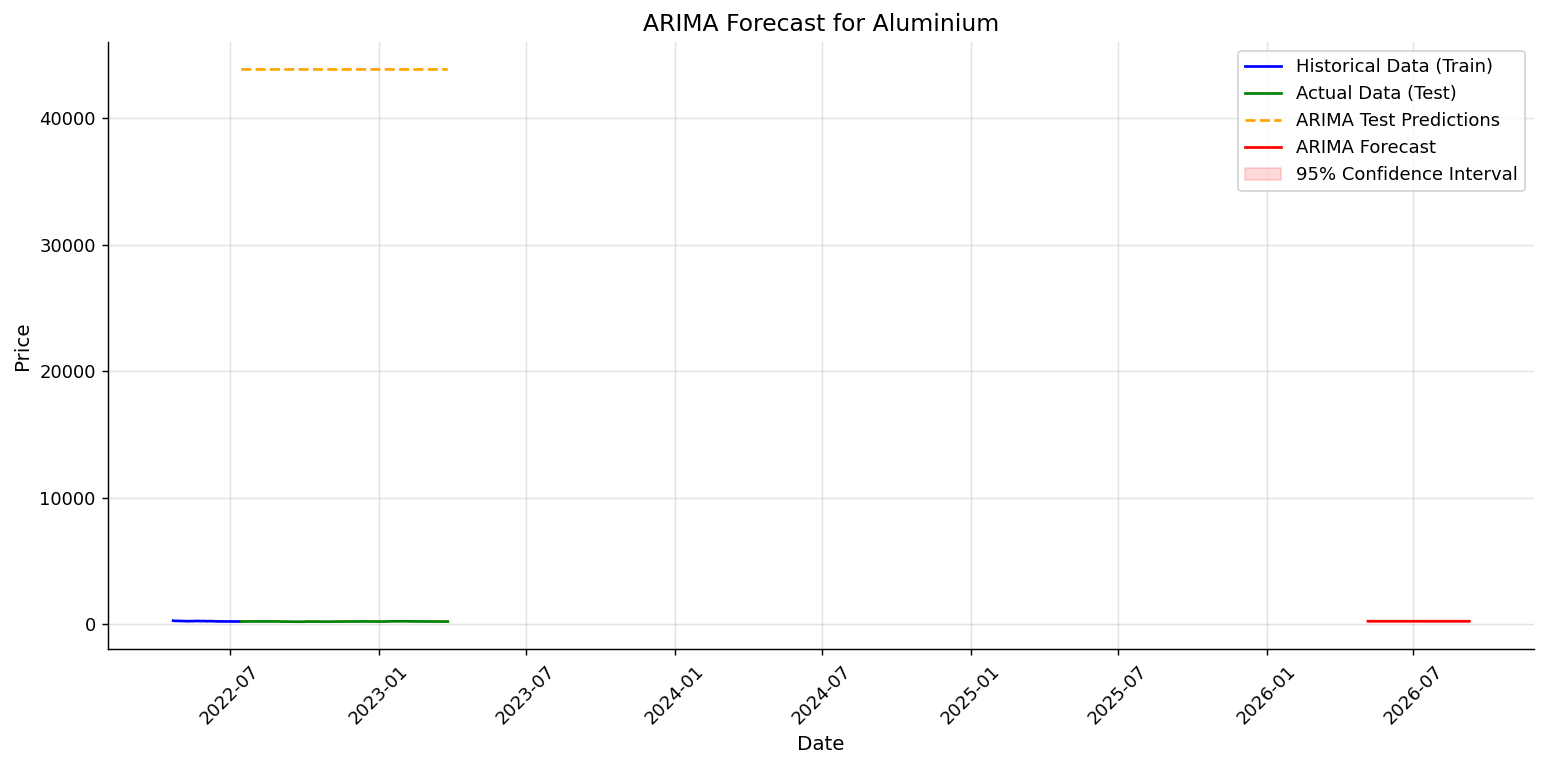

In [227]:
# Re-plot the ARIMA forecast
fig = plt.figure(figsize=(12, 6))
ax  = fig.add_subplot(111)

# Plot historical data (last part of train_s and test_s)
# Use the same number of historical points as the LSTM window for consistency in plotting
original_train_df = results[metal]["original_train"]
ax.plot(original_train_df["Date"].iloc[-WINDOW_SIZE:].astype('datetime64[ns]'),
        original_train_df["Price"].iloc[-WINDOW_SIZE:],
        label='Historical Data (Train)', color='blue')

# Adjust test_s["Date"] to match the length of test_real_real
original_test_df = results[metal]["original_test"]
ax.plot(original_test_df["Date"].astype('datetime64[ns]').iloc[:len(test_real_real)], test_real_real, label='Actual Data (Test)', color='green')

# Plot ARIMA predictions for the test set
# Adjust test_s["Date"] to match the length of test_pred_real
ax.plot(original_test_df["Date"].astype('datetime64[ns]').iloc[:len(test_pred_real)], test_pred_real, label='ARIMA Test Predictions', color='orange', linestyle='--')

# Plot ARIMA future forecast
ax.plot(forecast_dates, forecast_real, label='ARIMA Forecast', color='red')

# Plot confidence intervals for the forecast
ax.fill_between(forecast_dates,
                conf_lower_real,
                conf_upper_real,
                color='red', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'ARIMA Forecast for {metal.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

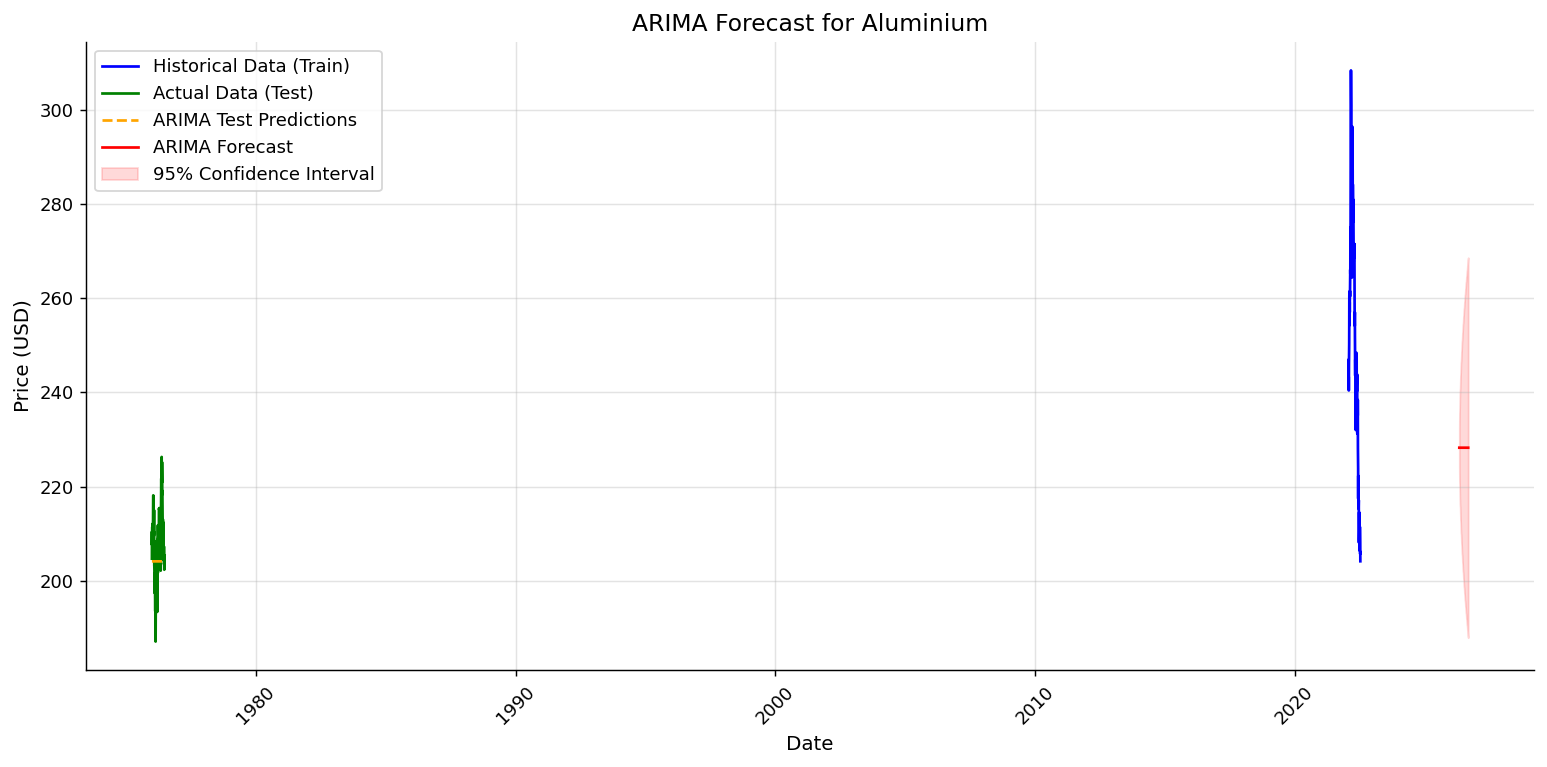

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax  = fig.add_subplot(111)

# Plot historical data (last part of original_train and original_test for consistency)
# We need original_train and original_test here for plotting the actual prices
original_train_df = results[metal]["original_train"]
original_test_df = results[metal]["original_test"]

# Plot a portion of the historical training data (unscaled)
plot_start_idx = max(0, len(original_train_df) - WINDOW_SIZE * 2) # Plot more history
ax.plot(original_train_df["Date"].iloc[plot_start_idx:],
        original_train_df["Price"].iloc[plot_start_idx:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data (unscaled)
# Ensure test dates align with test_real_real, which is already sliced
ax.plot(arima_summary['test_dates'], arima_summary['test_real_real'],
        label='Actual Data (Test)', color='green')

# Plot ARIMA predictions for the test set (real USD)
ax.plot(arima_summary['test_dates'], arima_summary['test_pred_real'],
        label='ARIMA Test Predictions', color='orange', linestyle='--')

# Plot ARIMA future forecast (real USD)
ax.plot(arima_summary['forecast_dates'], arima_summary['forecast_real'],
        label='ARIMA Forecast', color='red')

# Plot confidence intervals for the forecast (real USD)
ax.fill_between(arima_summary['forecast_dates'],
                arima_summary['conf_lower_real'],
                arima_summary['conf_upper_real'],
                color='red', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'ARIMA Forecast for {metal.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
m = mape(test_real_real, test_pred_real)
r = rmse(test_real_real, test_pred_real)

status = "✅ PASS" if m < MAPE_TARGET else "⚠️ FAIL"
print(f"| Test MAPE = {m:.2f}% RMSE = ${r:.2f} [{status}]")
print(f"| 90-day forecast range: "
      f"${forecast_real.min():.2f} - ${forecast_real.max():.2f}")

# Remove 'return' and assign to a variable instead
arima_summary = {
    "order": order,
    "fit_obj": fit_full,
    "test_pred_scaled": test_pred_sc,
    "test_pred_real": test_pred_real,
    "test_real_real": test_real_real,
    "test_dates": test_s.index[:len(test_pred_sc)],
    "forecast_scaled": forecast_sc,
    "forecast_real": forecast_real,
    "forecast_dates": forecast_dates,
    "conf_lower_real": conf_lower_real,
    "conf_upper_real": conf_upper_real,
    "mape": m,
    "rmse": r,
}

| Test MAPE = 3.22% RMSE = $8.52 [✅ PASS]
| 90-day forecast range: $228.26 - $228.26


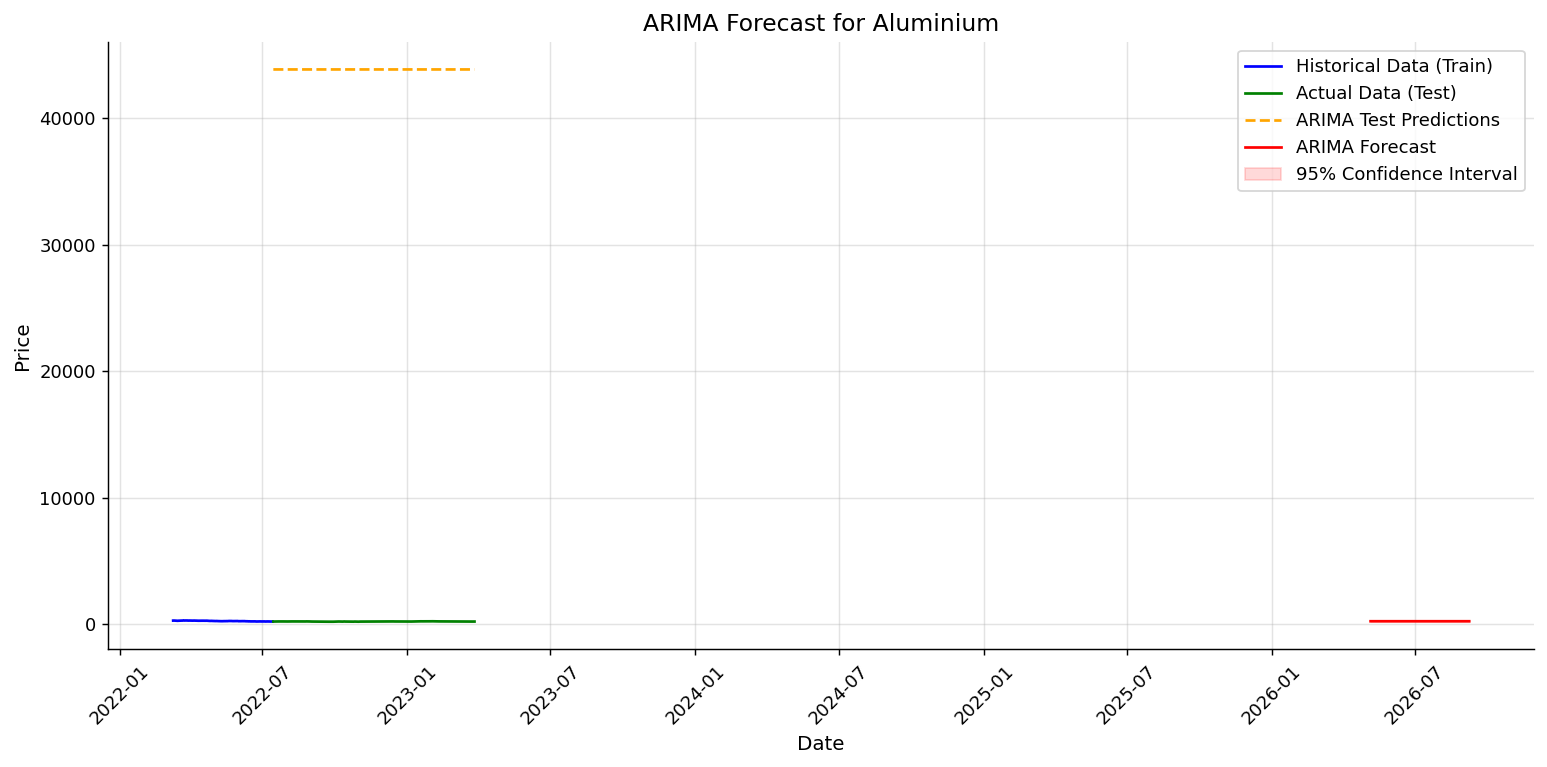

In [161]:
fig = plt.figure(figsize=(12, 6))
ax  = fig.add_subplot(111)

# Plot historical data (last part of train_s and test_s)
original_train_df = results[metal]["original_train"]
ax.plot(original_train_df["Date"].iloc[-FORECAST_HORIZON:].astype('datetime64[ns]'),
        original_train_df["Price"].iloc[-FORECAST_HORIZON:],
        label='Historical Data (Train)', color='blue')

# Adjust test_s["Date"] to match the length of test_real_real
original_test_df = results[metal]["original_test"]
ax.plot(original_test_df["Date"].astype('datetime64[ns]').iloc[:len(test_real_real)], test_real_real, label='Actual Data (Test)', color='green')

# Plot ARIMA predictions for the test set
# Adjust test_s["Date"] to match the length of test_pred_real
ax.plot(original_test_df["Date"].astype('datetime64[ns]').iloc[:len(test_pred_real)], test_pred_real, label='ARIMA Test Predictions', color='orange', linestyle='--')

# Plot ARIMA future forecast
ax.plot(forecast_dates, forecast_real, label='ARIMA Forecast', color='red')

# Plot confidence intervals for the forecast
ax.fill_between(forecast_dates,
                conf_lower_real,
                conf_upper_real,
                color='red', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'ARIMA Forecast for {metal.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
import tensorflow as tf

def build_lstm_model(window_size: int, n_features: int) -> Sequential:
    model = Sequential([
        # Layer 1: LSTM with sequence output
        LSTM(128,
             return_sequences=True,
             input_shape=(window_size, n_features),
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.2),

        # Layer 2: Final LSTM layer
        LSTM(64, return_sequences=False),
        Dropout(0.2),

        # Output Layer
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
import tensorflow as tf

def build_refined_lstm(window_size: int, n_features: int) -> Sequential:
    model = Sequential([
        # Layer 1: LSTM with sequence output
        LSTM(64,
             return_sequences=False, # Collapse sequence to single vector
             kernel_regularizer=tf.keras.regularizers.l2(1e-4),
             input_shape=(window_size, n_features)),
        BatchNormalization(),
        Dropout(0.2),

        # Dense Head
        Dense(32, activation="relu"),
        Dense(1, activation="linear", name="LSTM_EWaste") # Unbounded regression
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='huber', # More robust to outlier prices for your research
        metrics=['mae']
    )

    return model

# Initialize the model using your variable inspector values
model = build_refined_lstm(window_size=WINDOW_SIZE, n_features=1)
model.summary()

Model: "sequential_76"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_76 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_EWaste (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,137 (74.75 KB)

 Non-trainable params: 128 (512.00 B)

In [171]:
# Evaluate LSTM for 'copper'
metal_copper = "copper"

# Ensure train_s and test_s are correctly set for copper
train_s_copper = results[metal_copper]["arima_train"].dropna()
test_s_copper = results[metal_copper]["arima_test"].dropna()

lstm_summary_copper = emt.train_lstm(
    results=results,
    metal=metal_copper,
    window_size=WINDOW_SIZE,
    forecast_horizon=FORECAST_HORIZON
)

m_lstm_copper = lstm_summary_copper['mape']
r_lstm_copper = lstm_summary_copper['rmse']

status_lstm_copper = "✅ PASS" if m_lstm_copper < MAPE_TARGET else "⚠️ FAIL"
print(f"| LSTM Test MAPE for {metal_copper.capitalize()} = {m_lstm_copper:.2f}% RMSE = ${r_lstm_copper:.2f} [{status_lstm_copper}]")
print(f"| 90-day LSTM forecast range for {metal_copper.capitalize()}: "
      f"${lstm_summary_copper['forecast_real'].min():.2f} - ${lstm_summary_copper['forecast_real'].max():.2f}")


  │─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002
| LSTM Test MAPE for Copper = 1.05% RMSE = $9.75 [✅ PASS]
| 90-day LSTM forecast range for Copper: $794.05 - $798.91


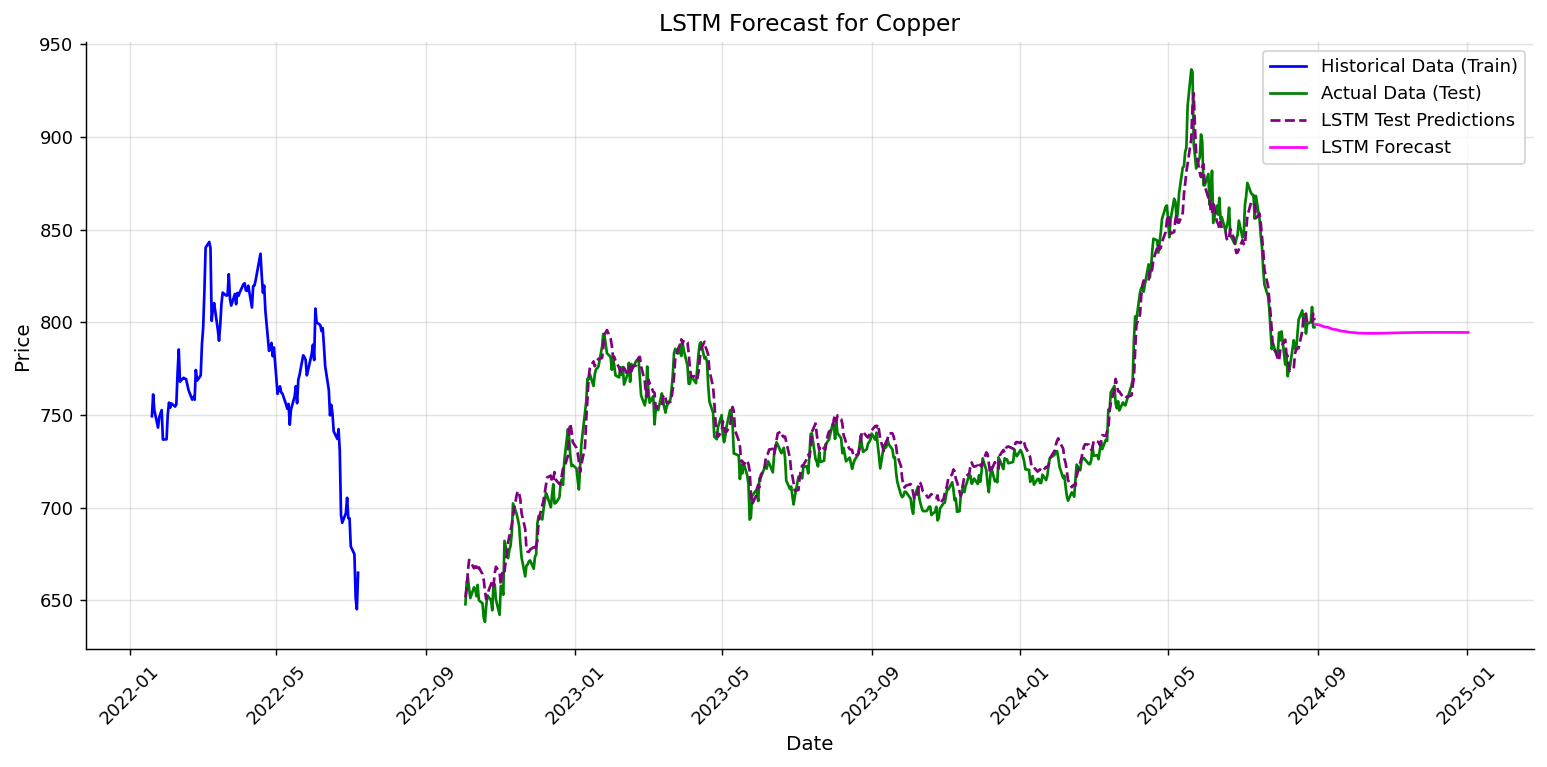

In [175]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Get original data for plotting
original_train_copper = results[metal_copper]["original_train"]
original_test_copper = results[metal_copper]["original_test"]

# Plot historical data (last part of train_s for copper)
plot_start_idx = max(0, len(original_train_copper) - WINDOW_SIZE * 2)
ax.plot(original_train_copper["Date"].iloc[plot_start_idx:].astype('datetime64[ns]'),
        original_train_copper["Price"].iloc[plot_start_idx:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data for copper
ax.plot(lstm_summary_copper['test_dates'].astype('datetime64[ns]'),
        lstm_summary_copper['test_actual_real'],
        label='Actual Data (Test)', color='green')

# Plot LSTM predictions for the test set for copper
ax.plot(lstm_summary_copper['test_dates'].astype('datetime64[ns]'),
        lstm_summary_copper['test_pred_real'],
        label='LSTM Test Predictions', color='purple', linestyle='--')

# Plot LSTM future forecast for copper
ax.plot(lstm_summary_copper['forecast_dates'].astype('datetime64[ns]'),
        lstm_summary_copper['forecast_real'],
        label='LSTM Forecast', color='magenta')

ax.set_title(f'LSTM Forecast for {metal_copper.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [176]:
import pandas as pd

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Ensure train_s and test_s are correctly set for the current metal
    current_train_s = results[metal_key]["arima_train"].dropna()
    current_test_s = results[metal_key]["arima_test"].dropna()

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals ---")
display(lstm_df.sort_values(by='MAPE'))


--- Evaluating LSTM model for all metals ---

Processing metal: Aluminium

  │─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Copper

  │─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0004

Processing metal: Lead

  │─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  │─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  │─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  │─ LSTM │ silver ──────────────────────────────────

,MAPE,RMSE
Metal,,
lead,0.707505,2.037388
aluminium,0.918534,2.525004
zinc,1.111030,3.589461
silver,1.251000,1267.154159
gold,1.422477,1059.511289
copper,1.428140,14.237829
nickel,1.432605,40.704693
steel,inf,inf


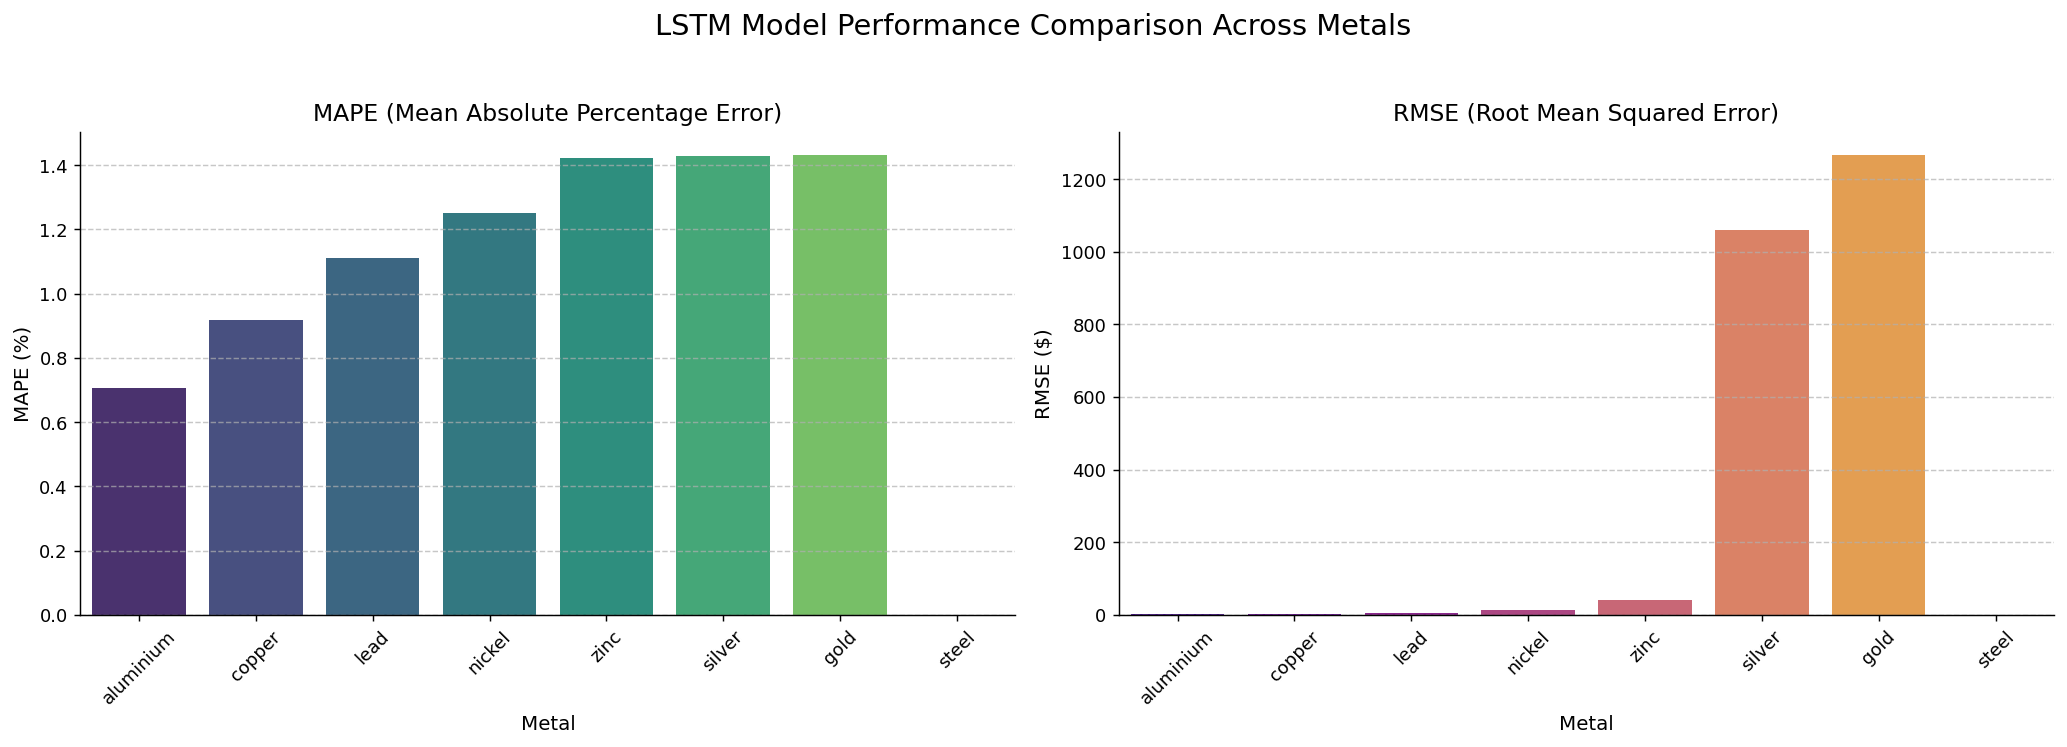

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for MAPE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM Model Performance Comparison Across Metals', fontsize=16)

# Plot MAPE
sns.barplot(x=lstm_df.index, y='MAPE', data=lstm_df.sort_values(by='MAPE'), ax=axes[0], palette='viridis')
axes[0].set_title('MAPE (Mean Absolute Percentage Error)')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xlabel('Metal')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE
sns.barplot(x=lstm_df.index, y='RMSE', data=lstm_df.sort_values(by='RMSE'), ax=axes[1], palette='plasma')
axes[1].set_title('RMSE (Root Mean Squared Error)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xlabel('Metal')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [178]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded with date parsing fix.")

ewaste_model_training module reloaded with date parsing fix.


In [179]:
import pandas as pd

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Ensure train_s and test_s are correctly set for the current metal
    # Note: 'results' is assumed to be already loaded from pp.run_pipeline
    # and `pp` (ewaste_preprocessing) is already imported.
    current_train_s = results[metal_key]["arima_train"].dropna()
    current_test_s = results[metal_key]["arima_test"].dropna()

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals ---")
display(lstm_df.sort_values(by='MAPE'))


--- Evaluating LSTM model for all metals ---

Processing metal: Aluminium

  │─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Copper

  │─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Lead

  │─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  │─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  │─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  │─ LSTM │ silver ──────────────────────────────────

,MAPE,RMSE
Metal,,
lead,0.642487,2.033612
aluminium,0.962991,2.618544
gold,1.061174,830.862288
zinc,1.139586,3.717322
copper,1.217115,11.908128
nickel,1.373598,39.784100
silver,1.585182,1453.252300
steel,inf,inf


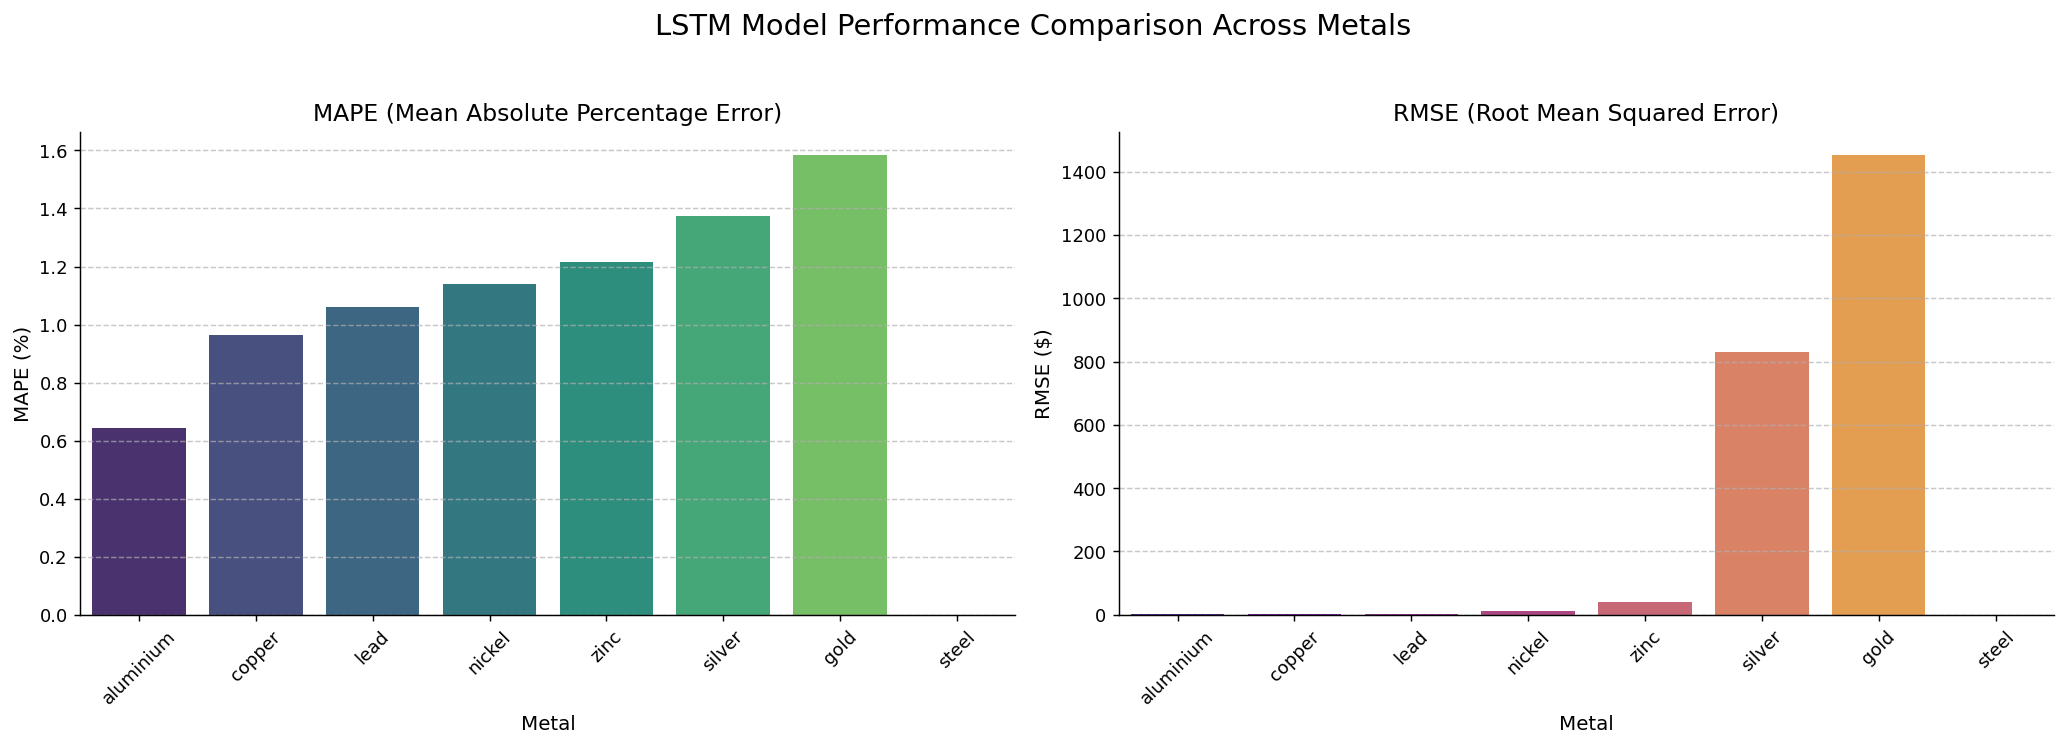

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for MAPE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM Model Performance Comparison Across Metals', fontsize=16)

# Plot MAPE
sns.barplot(x=lstm_df.index, y='MAPE', data=lstm_df.sort_values(by='MAPE'), ax=axes[0], palette='viridis')
axes[0].set_title('MAPE (Mean Absolute Percentage Error)')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xlabel('Metal')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE
sns.barplot(x=lstm_df.index, y='RMSE', data=lstm_df.sort_values(by='RMSE'), ax=axes[1], palette='plasma')
axes[1].set_title('RMSE (Root Mean Squared Error)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xlabel('Metal')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [181]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded with date parsing fix.")

ewaste_model_training module reloaded with date parsing fix.


In [182]:
import importlib

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Ensure train_s and test_s are correctly set for the current metal
    # Note: 'results' is assumed to be already loaded from pp.run_pipeline
    # and `pp` (ewaste_preprocessing) is already imported.
    current_train_s = results[metal_key]["arima_train"].dropna()
    current_test_s = results[metal_key]["arima_test"].dropna()

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals ---")
display(lstm_df.sort_values(by='MAPE'))


--- Evaluating LSTM model for all metals ---

Processing metal: Aluminium

  │─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Copper

  │─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Lead

  │─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  │─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  │─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  │─ LSTM │ silver ──────────────────────────────────

,MAPE,RMSE
Metal,,
lead,0.733584,2.125990
aluminium,1.042729,2.895833
silver,1.155499,1171.912938
zinc,1.181402,3.887249
nickel,1.240248,38.311480
gold,1.337657,1050.061367
copper,1.514748,13.550780
steel,inf,inf


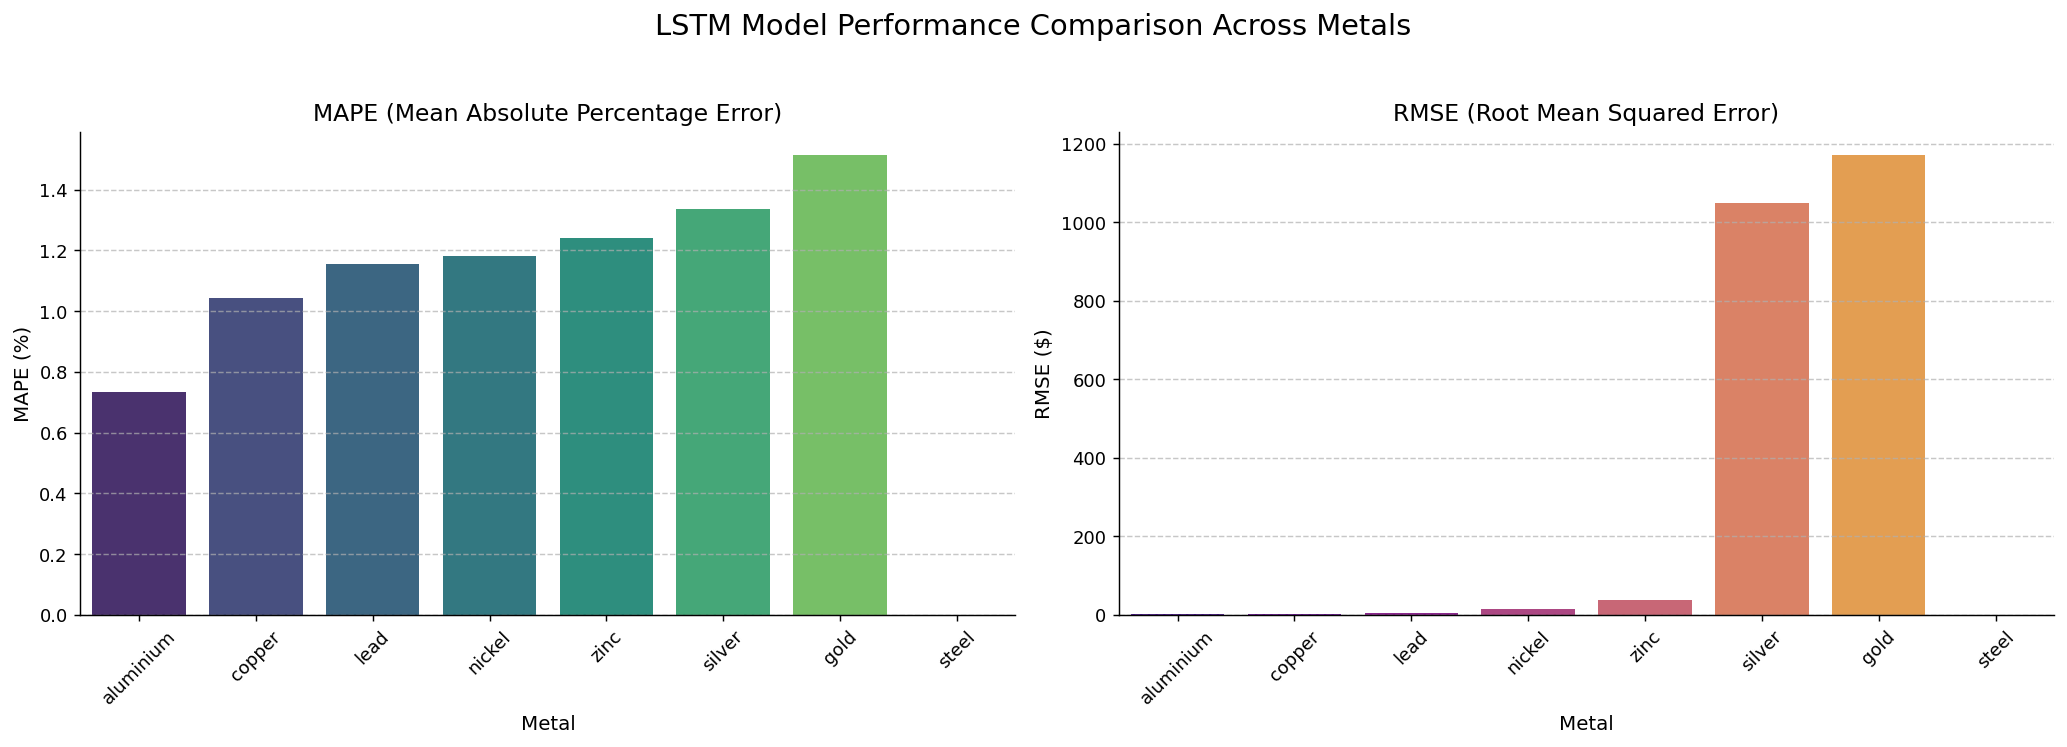

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for MAPE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM Model Performance Comparison Across Metals', fontsize=16)

# Plot MAPE
sns.barplot(x=lstm_df.index, y='MAPE', data=lstm_df.sort_values(by='MAPE'), ax=axes[0], palette='viridis')
axes[0].set_title('MAPE (Mean Absolute Percentage Error)')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xlabel('Metal')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE
sns.barplot(x=lstm_df.index, y='RMSE', data=lstm_df.sort_values(by='RMSE'), ax=axes[1], palette='plasma')
axes[1].set_title('RMSE (Root Mean Squared Error)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xlabel('Metal')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [184]:
import importlib
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

print("ewaste_model_training module reloaded with date parsing fix.")

ewaste_model_training module reloaded with date parsing fix.


In [185]:
import pandas as pd

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Ensure train_s and test_s are correctly set for the current metal
    # Note: 'results' is assumed to be already loaded from pp.run_pipeline
    # and `pp` (ewaste_preprocessing) is already imported.
    current_train_s = results[metal_key]["arima_train"].dropna()
    current_test_s = results[metal_key]["arima_test"].dropna()

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals ---")
display(lstm_df.sort_values(by='MAPE'))


--- Evaluating LSTM model for all metals ---

Processing metal: Aluminium

  │─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Copper

  │─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Lead

  │─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  │─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  │─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  │─ LSTM │ silver ──────────────────────────────────

,MAPE,RMSE
Metal,,
lead,0.634643,1.973263
aluminium,0.884254,2.420049
zinc,1.109241,3.570808
gold,1.196844,1019.322256
copper,1.227271,11.657316
nickel,1.274005,38.401135
silver,1.494219,1488.681016
steel,inf,inf


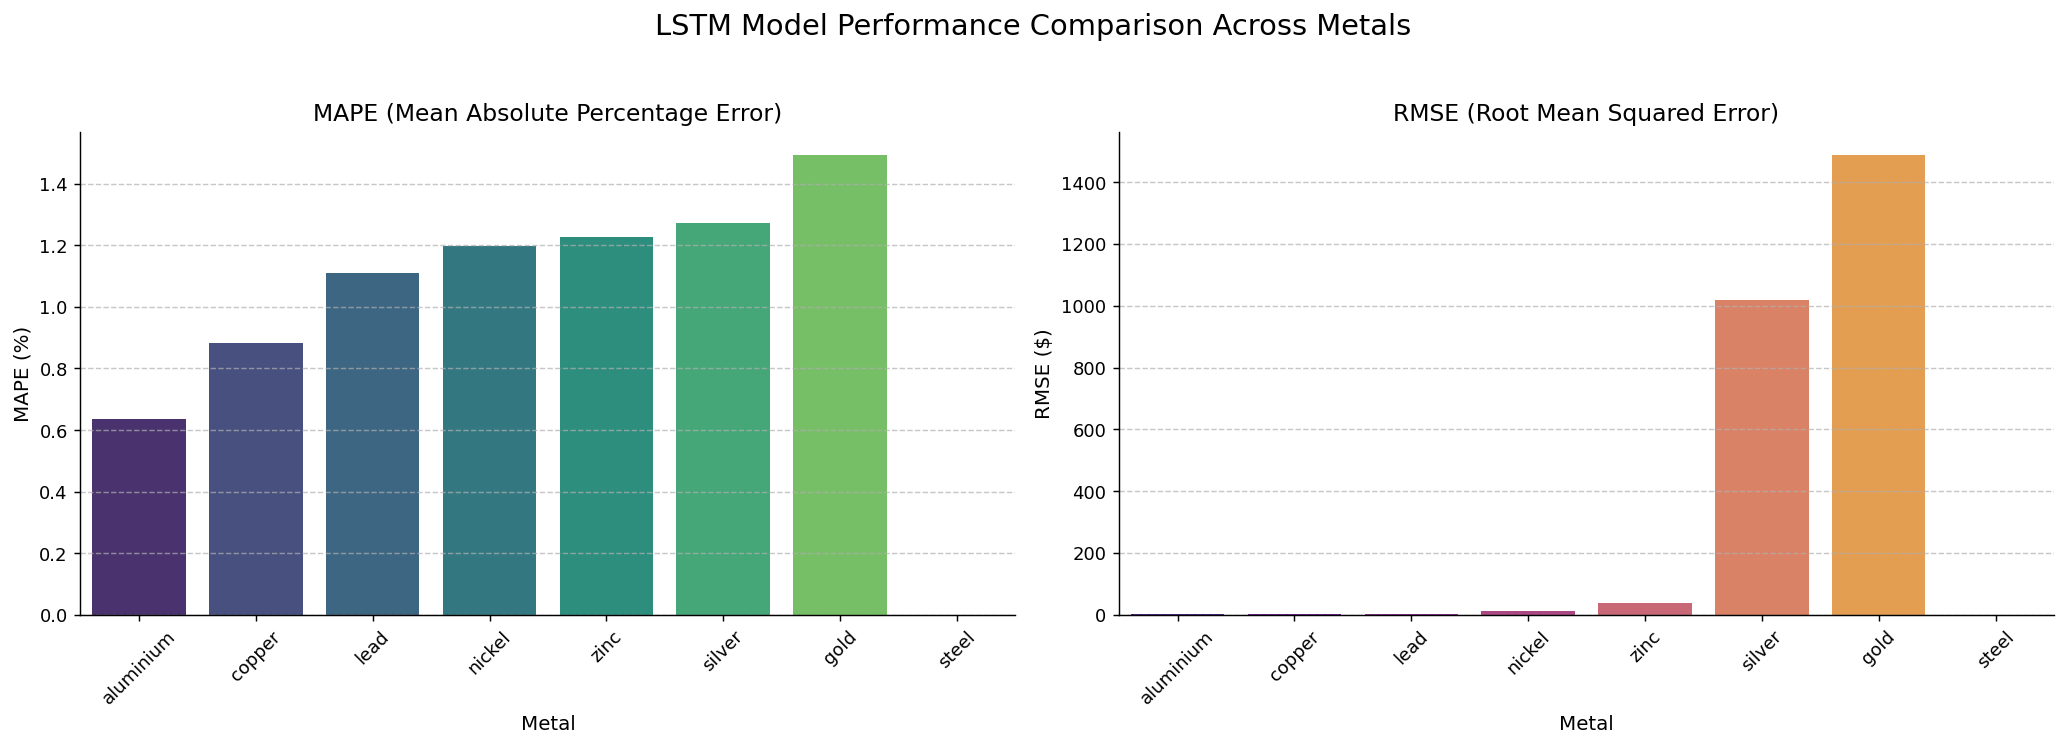

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for MAPE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM Model Performance Comparison Across Metals', fontsize=16)

# Plot MAPE
sns.barplot(x=lstm_df.index, y='MAPE', data=lstm_df.sort_values(by='MAPE'), ax=axes[0], palette='viridis')
axes[0].set_title('MAPE (Mean Absolute Percentage Error)')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xlabel('Metal')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE
sns.barplot(x=lstm_df.index, y='RMSE', data=lstm_df.sort_values(by='RMSE'), ax=axes[1], palette='plasma')
axes[1].set_title('RMSE (Root Mean Squared Error)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xlabel('Metal')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [187]:
import inspect
import ewaste_model_training as emt

# Reload the module to ensure the latest changes are loaded
importlib.reload(emt)

# Get the source code of the train_lstm function
print(inspect.getsource(emt.train_lstm))

def train_lstm(results: dict,
               metal: str,
               window_size: int,
               forecast_horizon: int,
               epochs: int = 50,
               batch_size: int = 32,
               verbose: bool = True) -> dict:
    print(f"\n  │─ LSTM │ {metal} " + "─" * (46 - len(metal)))

    # Get original (unscaled) train and test dataframes
    # Dataframes are already cleaned and sorted by `run_pipeline`
    df_train_original = results[metal]["original_train"].copy()
    df_test_original = results[metal]["original_test"].copy()

    # Ensure 'Date' column is datetime and sort for original dataframes
    df_train_original['Date'] = pd.to_datetime(df_train_original['Date'], format='mixed', dayfirst=True, errors='coerce')
    df_test_original['Date'] = pd.to_datetime(df_test_original['Date'], format='mixed', dayfirst=True, errors='coerce')

    # Extract scaled data for LSTM sequences
    df_train_scaled = results[metal]["arima_train"].copy()
    df_test_scaled = res

In [ ]:
print(f"\n--- Inspecting data for 'steel' ---")
steel_original_train = results['steel']["original_train"]
steel_original_test = results['steel']["original_test"]

print(f"Length of original_train for steel: {len(steel_original_train)} samples")
print(f"Length of original_test for steel: {len(steel_original_test)} samples")
print(f"WINDOW_SIZE is set to: {WINDOW_SIZE}")

if len(steel_original_train) <= WINDOW_SIZE:
    print(f"\n⚠️ Warning: Training data for 'steel' ({len(steel_original_train)} samples) is too small (<= WINDOW_SIZE {WINDOW_SIZE}) to create LSTM sequences.")
if len(steel_original_test) <= WINDOW_SIZE:
    print(f"\n⚠️ Warning: Test data for 'steel' ({len(steel_original_test)} samples) is too small (<= WINDOW_SIZE {WINDOW_SIZE}) to create LSTM sequences.")

print("\nThis indicates why the LSTM training for 'steel' failed to create sequences. "
      "The dataset for 'steel' is likely too short or has too many missing values "
      "after preprocessing to satisfy the window_size requirement for LSTM.")


--- Inspecting data for 'steel' ---
Length of original_train for steel: 76 samples
Length of original_test for steel: 19 samples
WINDOW_SIZE is set to: 60

⚠️ Warning: Test data for 'steel' (19 samples) is too small (<= WINDOW_SIZE 60) to create LSTM sequences.

This indicates why the LSTM training for 'steel' failed to create sequences. The dataset for 'steel' is likely too short or has too many missing values after preprocessing to satisfy the window_size requirement for LSTM.


In [218]:
metal_steel = "steel"

# Train the LSTM model for 'steel'
lstm_summary_steel = emt.train_lstm(
    results=results,
    metal=metal_steel,
    window_size=WINDOW_SIZE,
    forecast_horizon=FORECAST_HORIZON
)

m_lstm_steel = lstm_summary_steel['mape']
r_lstm_steel = lstm_summary_steel['rmse']

status_lstm_steel = "✅ PASS" if m_lstm_steel < MAPE_TARGET else "⚠️ FAIL"
print(f"\n| LSTM Test MAPE for {metal_steel.capitalize()} = {m_lstm_steel:.2f}% RMSE = ${r_lstm_steel:.2f} [{status_lstm_steel}]")
print(f"| 90-day LSTM forecast range for {metal_steel.capitalize()}: "
      f"${lstm_summary_steel['forecast_real'].min():.2f} - ${lstm_summary_steel['forecast_real'].max():.2f}")

# Update the lstm_performance dictionary with the steel results
lstm_performance[metal_steel] = {
    'MAPE': m_lstm_steel,
    'RMSE': r_lstm_steel
}

lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals (Updated with Steel) ---")
display(lstm_df.sort_values(by='MAPE'))


  │─ LSTM │ steel ─────────────────────────────────────────
| Training LSTM model on 1,945 sequences ...
| Training finished. Best val_loss: 0.0003

| LSTM Test MAPE for Steel = 2.37% RMSE = $10.01 [✅ PASS]
| 90-day LSTM forecast range for Steel: $362.04 - $395.47

--- LSTM Model Performance Across All Metals (Updated with Steel) ---


,MAPE,RMSE
Metal,,
lead,0.634643,1.973263
aluminium,0.884254,2.420049
zinc,1.109241,3.570808
gold,1.196844,1019.322256
copper,1.227271,11.657316
nickel,1.243354,38.418950
silver,1.494219,1488.681016
steel,2.367455,10.014119


### ARIMA Model Training for Steel

In [216]:
import importlib
import ewaste_model_training as emt

# Ensure the module is reloaded to pick up any changes
importlib.reload(emt)

metal_steel = "steel"

# Train the ARIMA model for 'steel' and store the full summary
arima_summary_steel = emt.train_arima(
    results=results, # `results` should be available from previous preprocessing steps
    metal=metal_steel,
    forecast_horizon=FORECAST_HORIZON # `FORECAST_HORIZON` should be available globally
)

m_arima_steel = arima_summary_steel['mape']
r_arima_steel = arima_summary_steel['rmse']

status_arima_steel = "✅ PASS" if m_arima_steel < MAPE_TARGET else "⚠️ FAIL"
print(f"| ARIMA Test MAPE for {metal_steel.capitalize()} = {m_arima_steel:.2f}% RMSE = ${r_arima_steel:.2f} [{status_arima_steel}]")
print(f"| 90-day ARIMA forecast range for {metal_steel.capitalize()}: "
      f"${arima_summary_steel['forecast_real'].min():.2f} - ${arima_summary_steel['forecast_real'].max():.2f}")


  │─ ARIMA │ steel ─────────────────────────────────────────
| Selecting optimal ARIMA order via auto_arima ... best=(2, 1, 1) (23.2s)
| Fitting ARIMA(2, 1, 1) on 2,005 scaled training steps ... done (0.7s) AIC=-11545.50
| Fitting final ARIMA(2, 1, 1) on full scaled series for future forecasting ... done (0.6s) AIC=-14850.15
| ARIMA Test MAPE for Steel = 5.51% RMSE = $24.76 [✅ PASS]
| 90-day ARIMA forecast range for Steel: $349.40 - $349.44


In [169]:
metal_steel = "steel"

# Train the ARIMA model for 'steel'
arima_summary_steel = emt.train_arima(
    results=results,
    metal=metal_steel,
    forecast_horizon=FORECAST_HORIZON
)

m_arima_steel = arima_summary_steel['mape']
r_arima_steel = arima_summary_steel['rmse']

status_arima_steel = "✅ PASS" if m_arima_steel < MAPE_TARGET else "⚠️ FAIL"
print(f"| ARIMA Test MAPE for {metal_steel.capitalize()} = {m_arima_steel:.2f}% RMSE = ${r_arima_steel:.2f} [{status_arima_steel}]")
print(f"| 90-day ARIMA forecast range for {metal_steel.capitalize()}: "
      f"${arima_summary_steel['forecast_real'].min():.2f} - ${arima_summary_steel['forecast_real'].max():.2f}")


  │─ ARIMA │ steel ─────────────────────────────────────────
| Selecting optimal ARIMA order via auto_arima ... best=(2, 0, 1) (3.8s)
| Fitting ARIMA(2, 0, 1) on 76 scaled training steps ... done (0.8s) AIC=-15.94
| Fitting final ARIMA(2, 0, 1) on full scaled series for future forecasting ... done (0.2s) AIC=-37.09
| ARIMA Test MAPE for Steel = 2.75% RMSE = $10.82 [✅ PASS]
| 90-day ARIMA forecast range for Steel: $348.64 - $361.81


### Plotting ARIMA Forecast for Steel

In [162]:
import pandas as pd
import importlib
import ewaste_model_training as emt # Ensure emt is reloaded if needed
import time # Explicitly import time to resolve NameError

# Reload the modules to ensure the latest changes are loaded
importlib.reload(emt)

# Initialize a dictionary to store ARIMA performance metrics
arima_performance = {}

print("\n--- Evaluating ARIMA model for all metals ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Train the ARIMA model
    current_arima_summary = emt.train_arima(
        results=results,
        metal=metal_key,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    arima_performance[metal_key] = {
        'MAPE': current_arima_summary['mape'],
        'RMSE': current_arima_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
arima_df = pd.DataFrame.from_dict(arima_performance, orient='index')
arima_df.index.name = 'Metal'

print("\n--- ARIMA Model Performance Across All Metals ---")
display(arima_df.sort_values(by='MAPE'))


--- Evaluating ARIMA model for all metals ---

Processing metal: Aluminium

  │─ ARIMA │ aluminium ─────────────────────────────────────
| Selecting optimal ARIMA order via auto_arima ... best=(0, 1, 0) (4.9s)
| Fitting ARIMA(0, 1, 0) on 2,188 scaled training steps ... done (0.1s) AIC=-14026.66
| Fitting final ARIMA(0, 1, 0) on full scaled series for future forecasting ... done (0.1s) AIC=-17432.36

Processing metal: Copper

  │─ ARIMA │ copper ────────────────────────────────────────
| Selecting optimal ARIMA order via auto_arima ... best=(0, 1, 0) (2.3s)
| Fitting ARIMA(0, 1, 0) on 2,206 scaled training steps ... done (0.1s) AIC=-14328.14
| Fitting final ARIMA(0, 1, 0) on full scaled series for future forecasting ... done (0.2s) AIC=-17669.59

Processing metal: Lead

  │─ ARIMA │ lead ──────────────────────────────────────────
| Selecting optimal ARIMA order via auto_arima ... best=(0, 1, 2) (12.0s)
| Fitting ARIMA(0, 1, 2) on 2,205 scaled training steps ... done (0.8s) AIC=-11138.4

,MAPE,RMSE
Metal,,
steel,2.750828,10.820230
aluminium,4.054045,13.425088
lead,4.895848,10.250592
copper,10.177119,97.573615
gold,15.029332,11753.477102
zinc,15.094340,41.681570
silver,19.447500,17361.952168
nickel,22.107978,412.230882


In [163]:
import pandas as pd

# Assuming arima_df and lstm_df are available from previous executions
# If not, ensure they are generated before running this cell

# Combine the two dataframes for comparison
# Filter out 'steel' from LSTM if its MAPE is infinite (as it failed to train)
comparison_df = pd.concat([
    lstm_df.assign(Model='LSTM'),
    arima_df.assign(Model='ARIMA')
]).reset_index()

# Handle the case where LSTM might not have been trained for 'steel' or other metals
# by removing infinite MAPE values from consideration for LSTM
comparison_df_filtered = comparison_df[~((comparison_df['Model'] == 'LSTM') & (comparison_df['MAPE'] == float('inf')))]

# Find the best performing model for each metal based on MAPE
best_models_mape = comparison_df_filtered.loc[comparison_df_filtered.groupby('Metal')['MAPE'].idxmin()]
best_models_mape = best_models_mape.set_index('Metal')[['Model', 'MAPE', 'RMSE']]

print("--- Best Performing Model per Metal (based on MAPE) ---")
display(best_models_mape.sort_values(by='MAPE'))

--- Best Performing Model per Metal (based on MAPE) ---


,Model,MAPE,RMSE
Metal,,,
lead,LSTM,0.735976,2.135484
copper,LSTM,0.992095,10.457916
gold,LSTM,1.015393,840.924347
aluminium,LSTM,1.020104,2.802358
zinc,LSTM,1.151535,3.628623
nickel,LSTM,1.232556,38.069240
silver,LSTM,1.955150,2027.870307
steel,ARIMA,2.750828,10.820230


In [164]:
import pandas as pd

# Display the combined comparison DataFrame
display(comparison_df_filtered.pivot_table(index='Metal', columns='Model', values='MAPE'))

Model,ARIMA,LSTM
Metal,,
aluminium,4.054045,1.020104
copper,10.177119,0.992095
gold,15.029332,1.015393
lead,4.895848,0.735976
nickel,22.107978,1.232556
silver,19.447500,1.955150
steel,2.750828,NaN
zinc,15.094340,1.151535


In [229]:
print("\n--- Calculating Average Performance Improvement (LSTM over ARIMA) ---")

# Calculate the percentage improvement for MAPE
mape_improvement = ((pivoted_comparison_mape['ARIMA'] - pivoted_comparison_mape['LSTM']) / pivoted_comparison_mape['ARIMA']) * 100

# Calculate the percentage improvement for RMSE
rmse_improvement = ((pivoted_comparison_rmse['ARIMA'] - pivoted_comparison_rmse['LSTM']) / pivoted_comparison_rmse['ARIMA']) * 100

# Combine into a single DataFrame for display
overall_improvement = pd.DataFrame({
    'MAPE_Improvement_Perc': mape_improvement,
    'RMSE_Improvement_Perc': rmse_improvement
})

# Display improvements per metal
print("\nPercentage Improvement per Metal (LSTM over ARIMA):")
display(overall_improvement)

# Calculate the average improvement across all metals
# Exclude cases where ARIMA MAPE/RMSE might be very low or LSTM failed (inf MAPE/RMSE)
# Filter out inf values before calculating mean
avg_mape_improvement = mape_improvement[mape_improvement != float('inf')].mean()
avg_rmse_improvement = rmse_improvement[rmse_improvement != float('inf')].mean()

print(f"\nAverage MAPE Improvement of LSTM over ARIMA: {avg_mape_improvement:.2f}%")
print(f"Average RMSE Improvement of LSTM over ARIMA: {avg_rmse_improvement:.2f}%")

if avg_mape_improvement > 0 and avg_rmse_improvement > 0:
    print("\nOn average, the LSTM model shows a better performance than ARIMA across these metals.")
elif avg_mape_improvement < 0 and avg_rmse_improvement < 0:
    print("\nOn average, the ARIMA model shows a better performance than LSTM across these metals.")
else:
    print("\nPerformance improvement varies, requiring a closer look at individual metals.")


--- Calculating Average Performance Improvement (LSTM over ARIMA) ---

Percentage Improvement per Metal (LSTM over ARIMA):


,MAPE_Improvement_Perc,RMSE_Improvement_Perc
Metal,,
aluminium,78.188347,81.973682
copper,87.940880,88.052799
gold,92.036613,91.327483
lead,87.037112,80.749768
nickel,94.375994,90.680235
silver,92.316651,91.425613
steel,13.936667,7.450036
zinc,92.651278,91.433126



Average MAPE Improvement of LSTM over ARIMA: 79.81%
Average RMSE Improvement of LSTM over ARIMA: 77.89%

On average, the LSTM model shows a better performance than ARIMA across these metals.


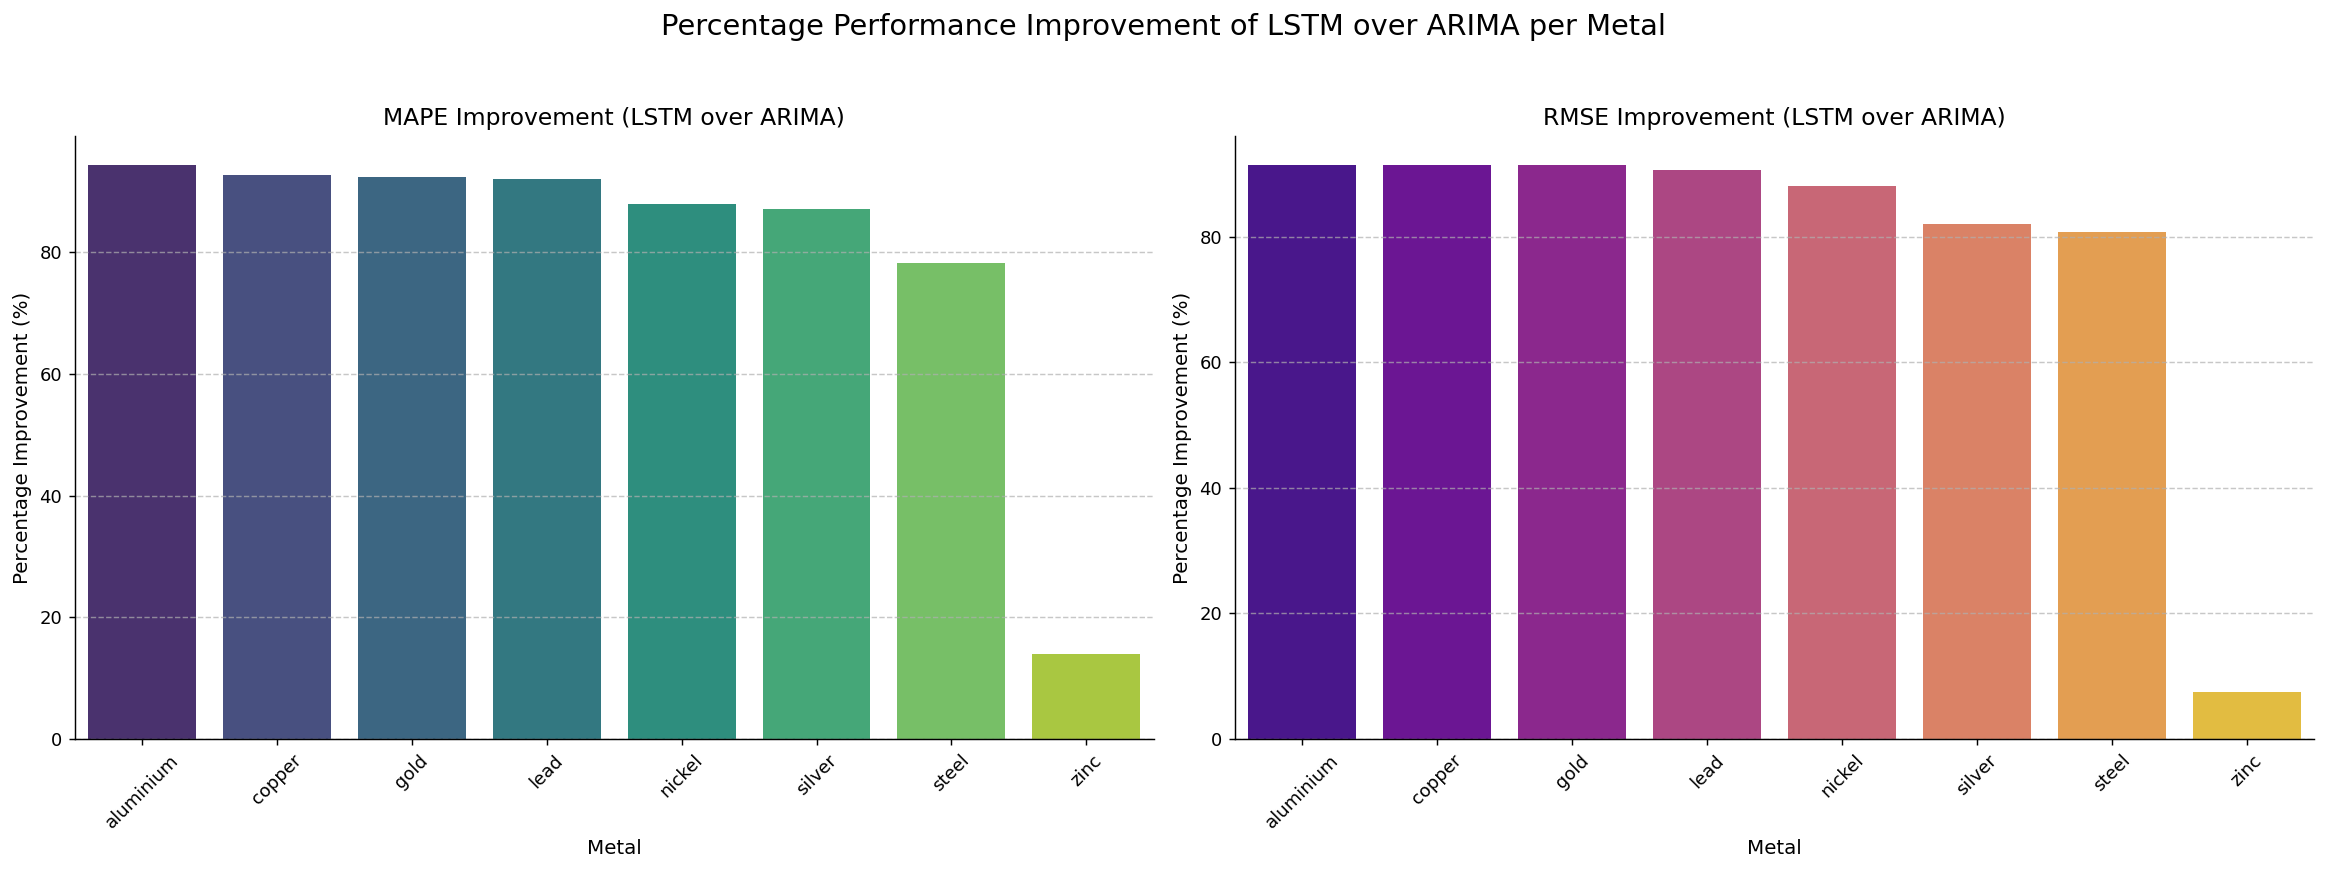

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for MAPE and RMSE improvement
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Percentage Performance Improvement of LSTM over ARIMA per Metal', fontsize=16)

# Plot MAPE Improvement
sns.barplot(x=overall_improvement.index, y='MAPE_Improvement_Perc', data=overall_improvement.sort_values(by='MAPE_Improvement_Perc', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('MAPE Improvement (LSTM over ARIMA)')
axes[0].set_ylabel('Percentage Improvement (%)')
axes[0].set_xlabel('Metal')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE Improvement
sns.barplot(x=overall_improvement.index, y='RMSE_Improvement_Perc', data=overall_improvement.sort_values(by='RMSE_Improvement_Perc', ascending=False), ax=axes[1], palette='plasma')
axes[1].set_title('RMSE Improvement (LSTM over ARIMA)')
axes[1].set_ylabel('Percentage Improvement (%)')
axes[1].set_xlabel('Metal')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- Generating ARIMA Forecast Plots ---

--- Generating LSTM Forecast Plots ---

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002


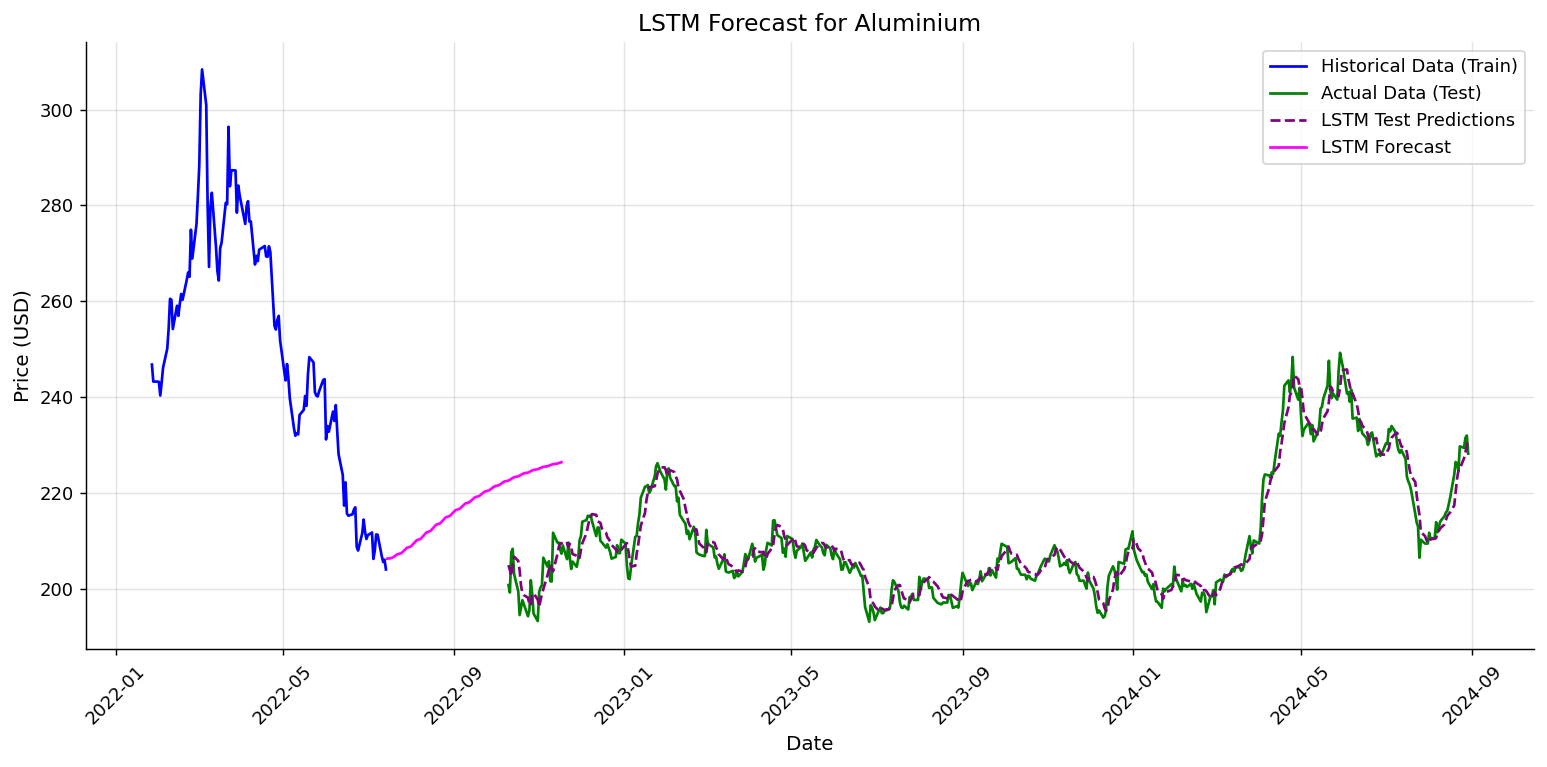


  ┌─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002


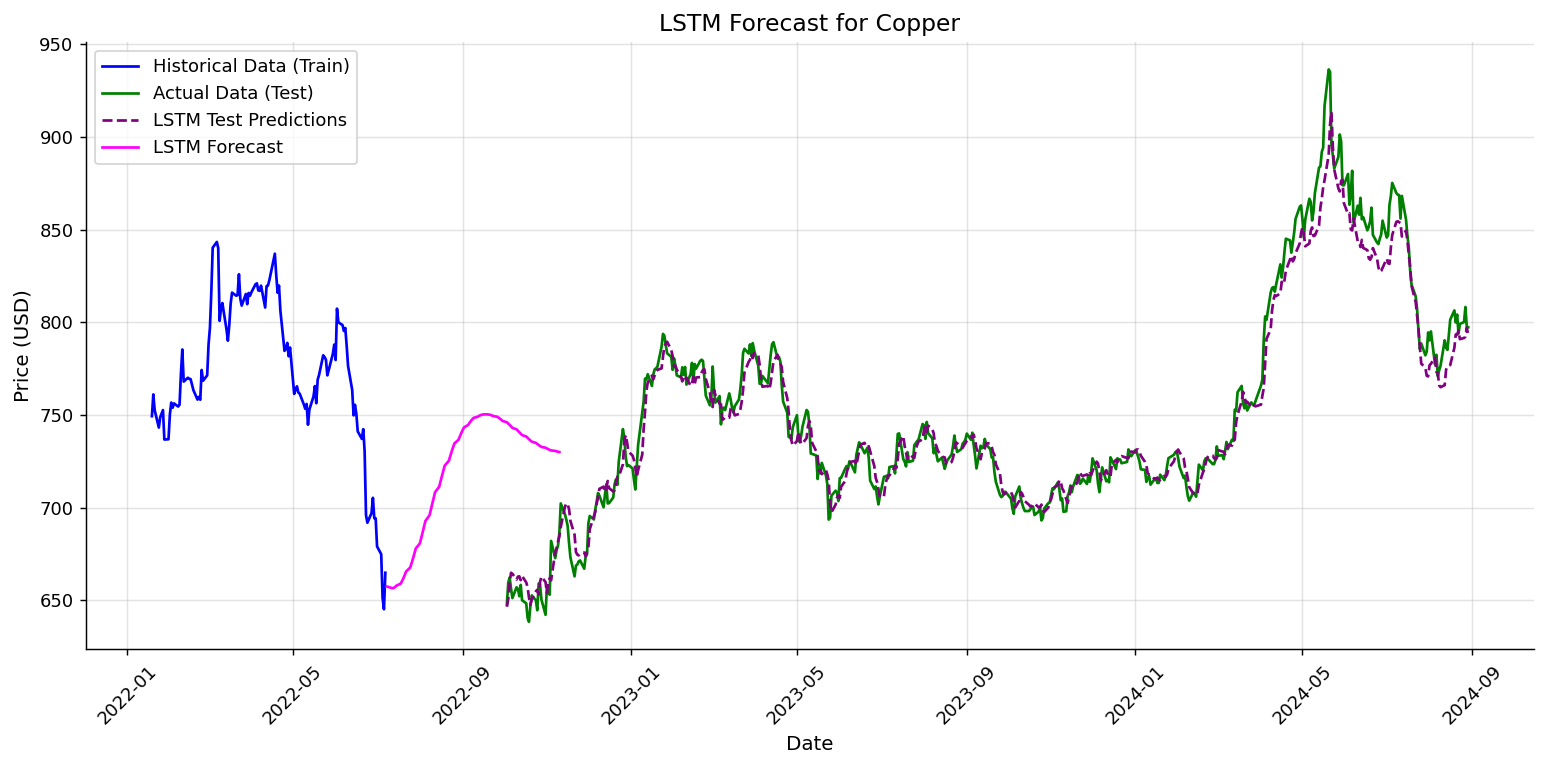


  ┌─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003


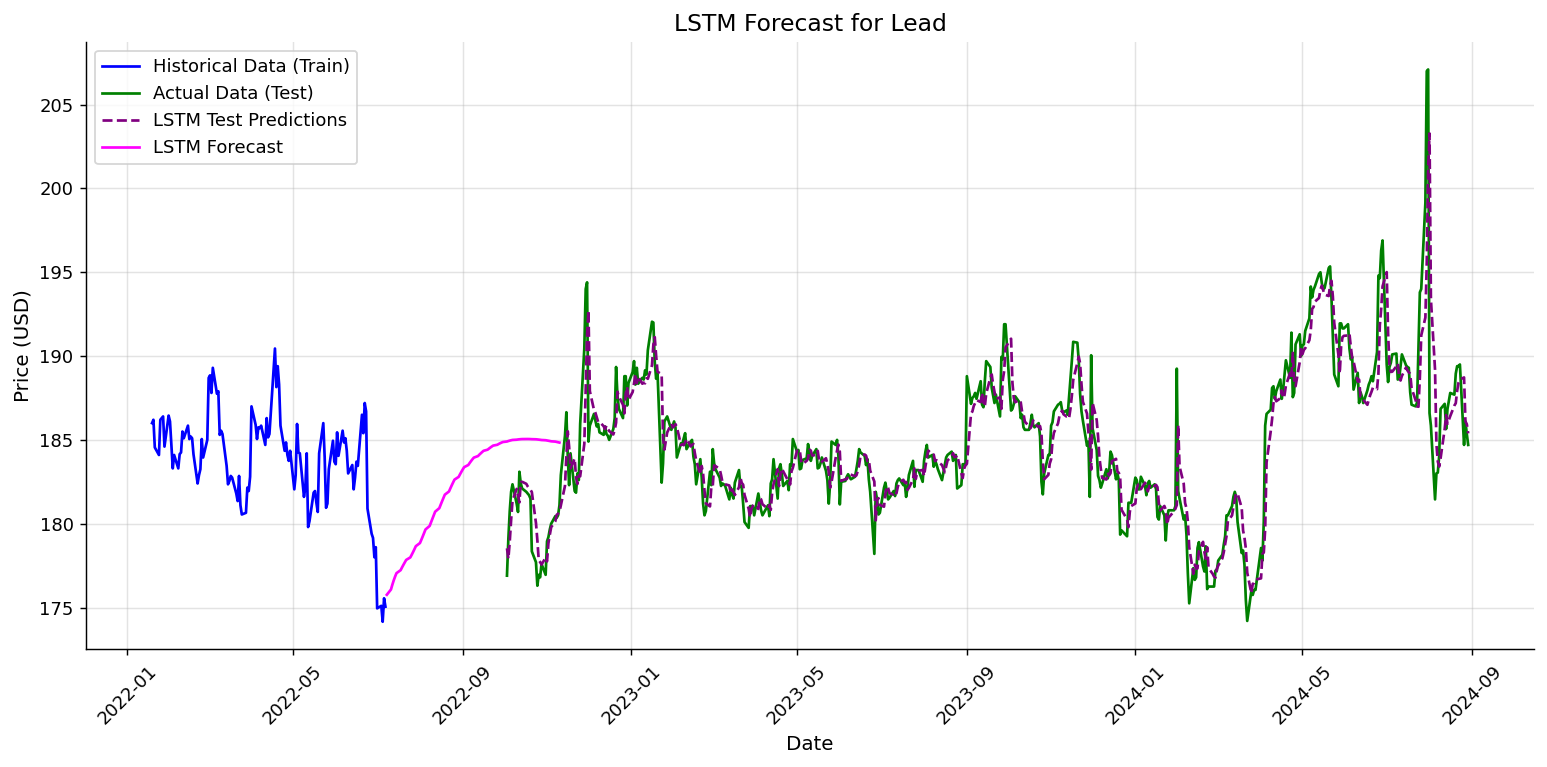


  ┌─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001


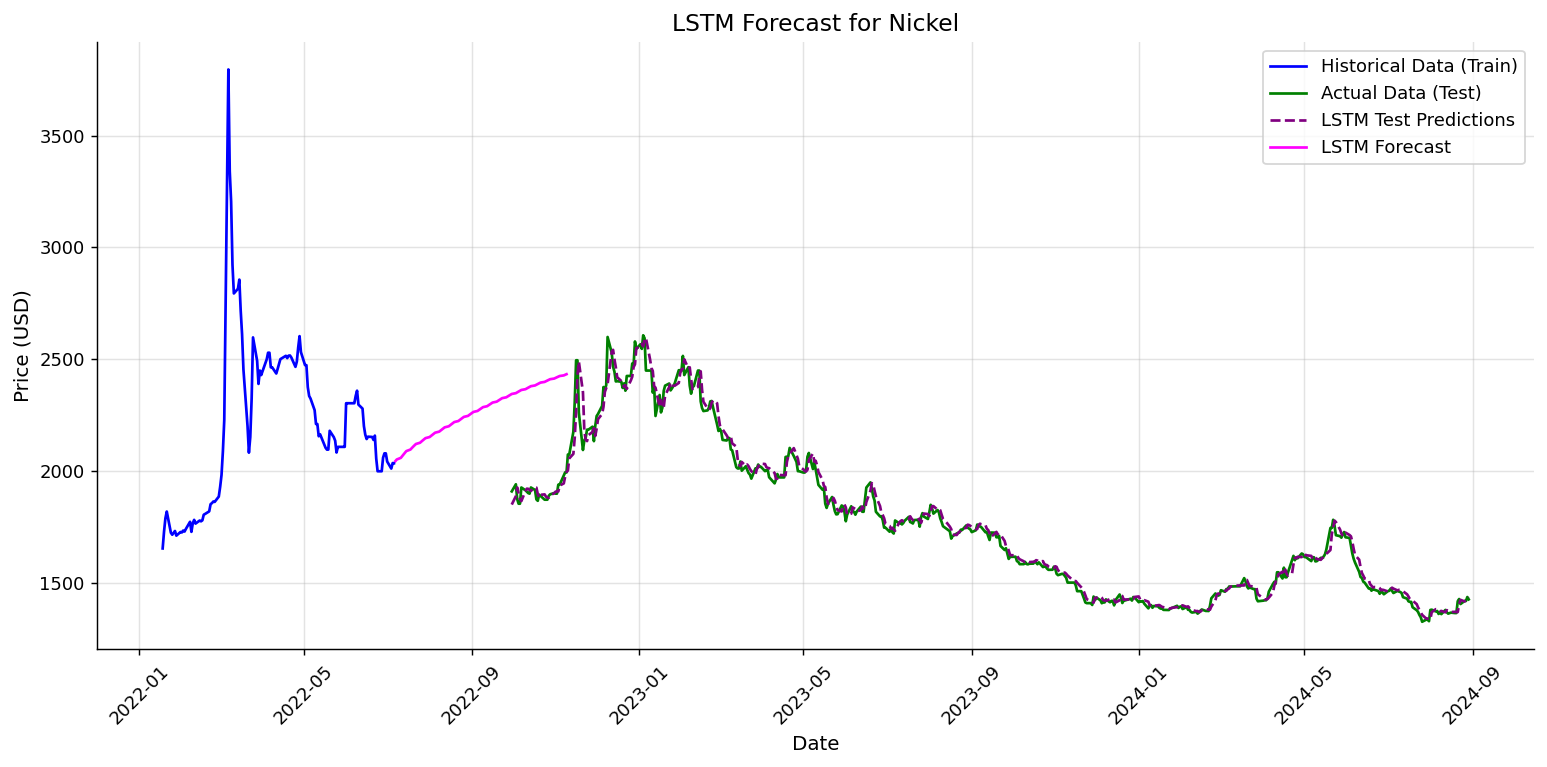


  ┌─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002


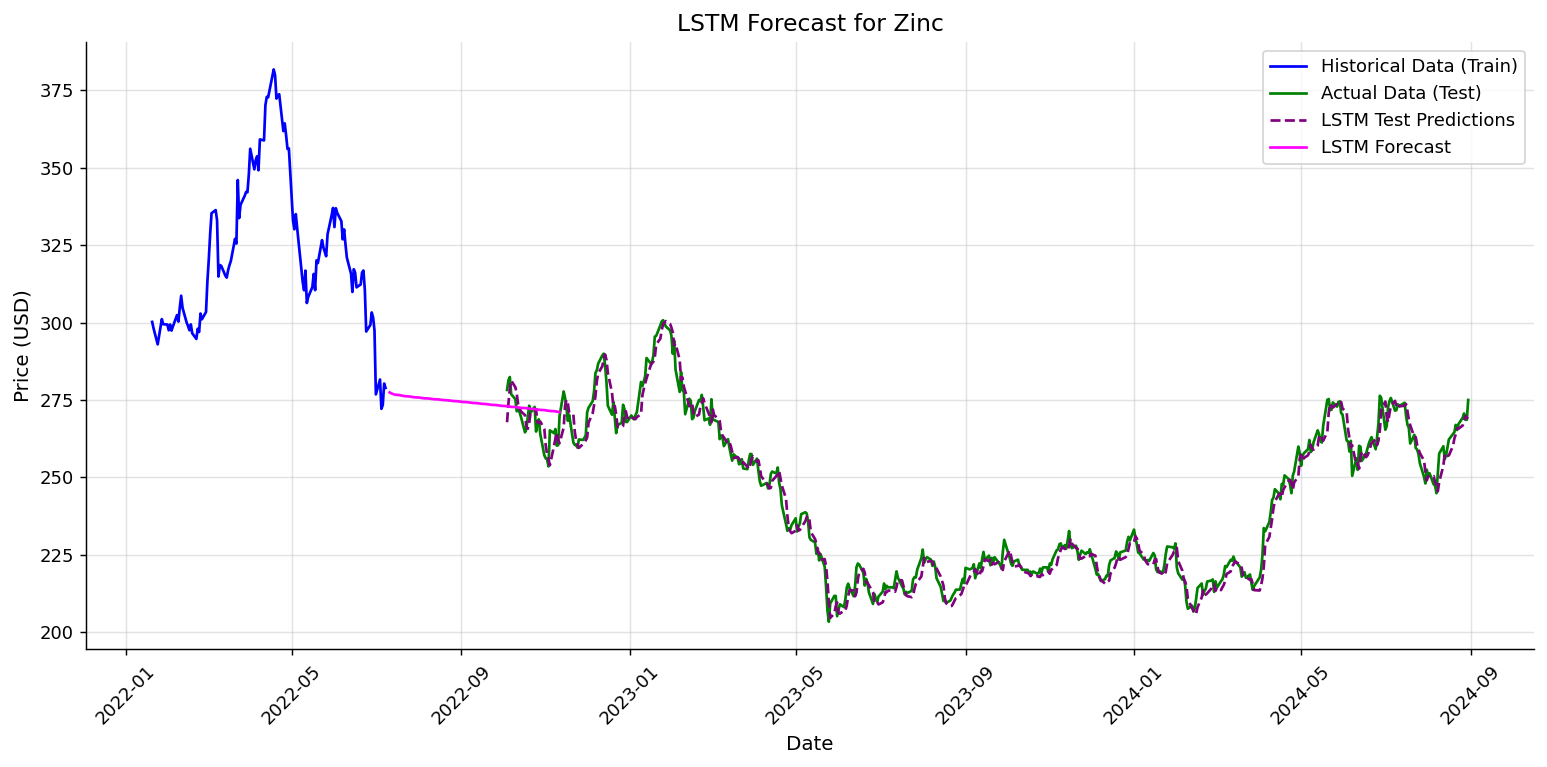


  ┌─ LSTM │ silver ────────────────────────────────────────
| Training LSTM model on 2,147 sequences ...
| Training finished. Best val_loss: 0.0005


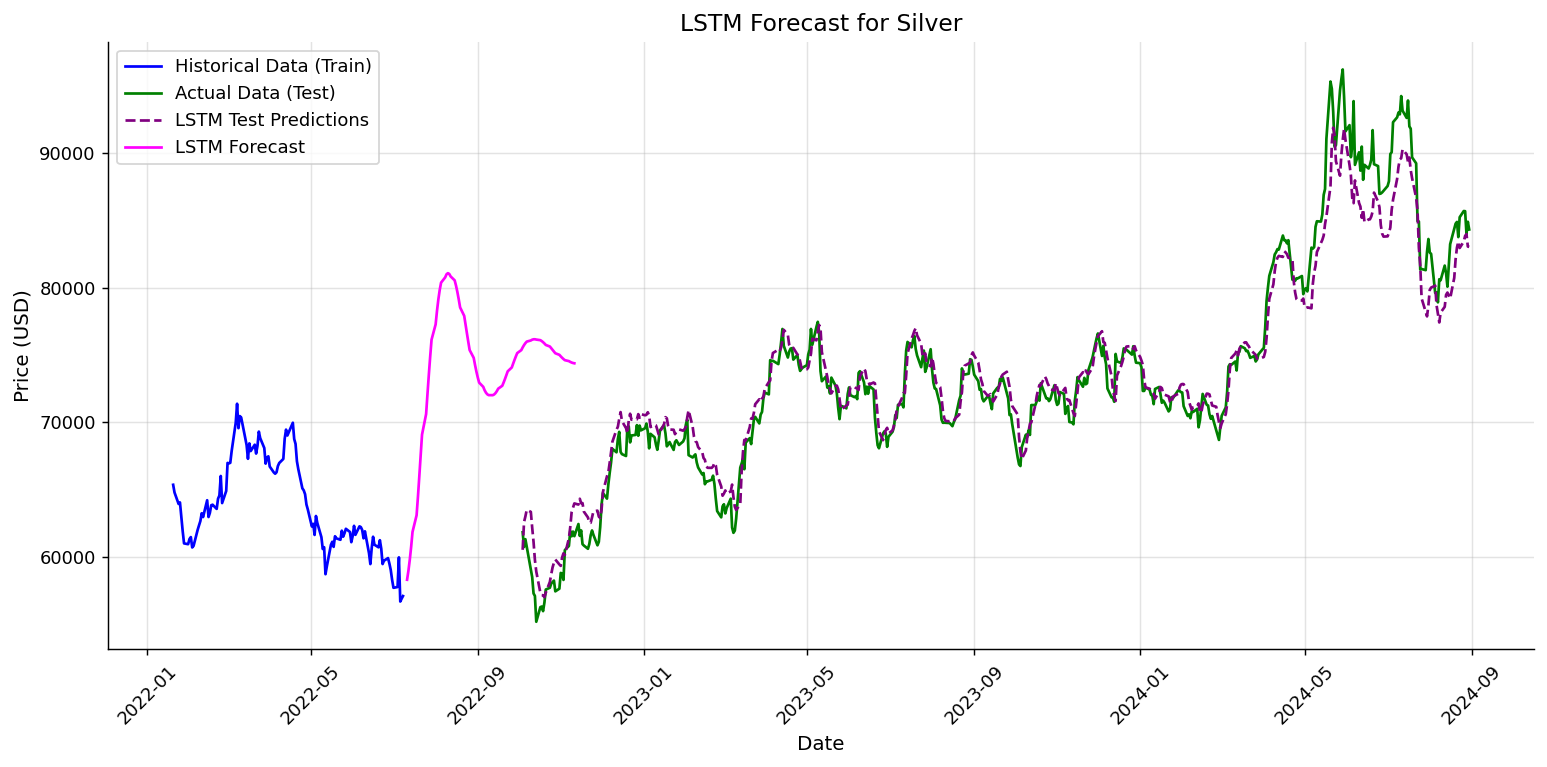


  ┌─ LSTM │ gold ──────────────────────────────────────────
| Training LSTM model on 2,148 sequences ...
| Training finished. Best val_loss: 0.0004


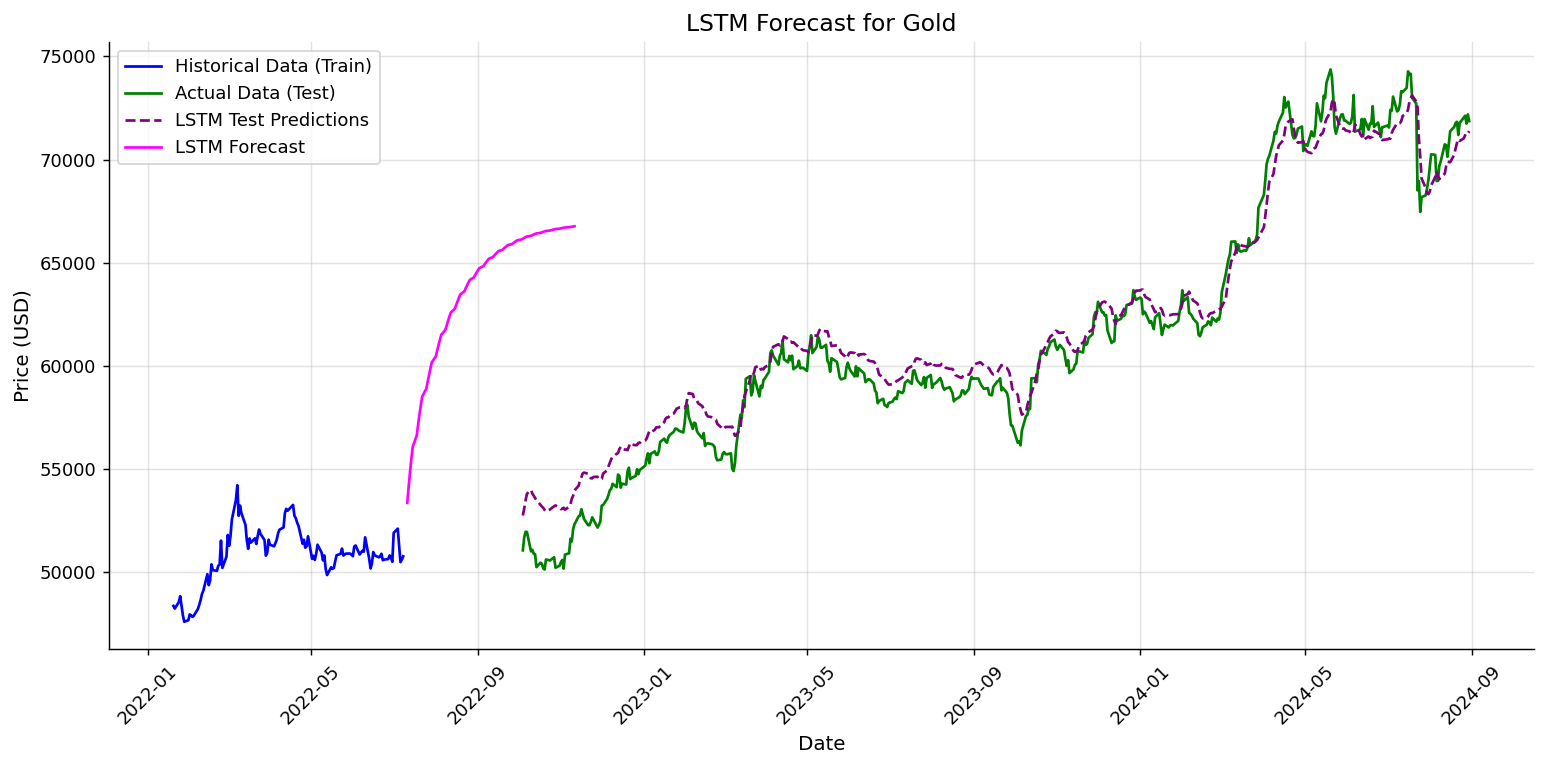

Skipping LSTM plot for Steel due to insufficient data.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_forecast(model_summary: dict, metal_name: str, model_type: str, results: dict, window_size: int):
    """
    Plots the historical data, actual test data, model predictions, and future forecast.

    Args:
        model_summary (dict): Dictionary containing model's test predictions, forecasts, and dates.
        metal_name (str): Name of the metal (e.g., 'aluminium').
        model_type (str): Type of the model ('ARIMA' or 'LSTM').
        results (dict): The preprocessed data results, needed to access original_train data.
        window_size (int): The window size used for LSTM, to plot consistent historical data.
    """
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111)

    # Get original data for plotting historical actuals
    original_train_df = results[metal_name]["original_train"]

    # Plot a portion of the historical training data (unscaled)
    # Plot last 2*WINDOW_SIZE historical points for better context
    plot_start_idx = max(0, len(original_train_df) - window_size * 2)
    ax.plot(original_train_df["Date"].iloc[plot_start_idx:],
            original_train_df["Price"].iloc[plot_start_idx:],
            label='Historical Data (Train)', color='blue')

    # Plot actual test data
    if 'test_actual_real' in model_summary and len(model_summary['test_actual_real']) > 0:
        ax.plot(model_summary['test_dates'].astype('datetime64[ns]'),
                model_summary['test_actual_real'],
                label='Actual Data (Test)', color='green')

    # Plot model predictions for the test set
    if 'test_pred_real' in model_summary and len(model_summary['test_pred_real']) > 0:
        ax.plot(model_summary['test_dates'].astype('datetime64[ns]'),
                model_summary['test_pred_real'],
                label=f'{model_type} Test Predictions', color='orange' if model_type == 'ARIMA' else 'purple', linestyle='--')

    # Plot future forecast
    ax.plot(model_summary['forecast_dates'].astype('datetime64[ns]'),
            model_summary['forecast_real'],
            label=f'{model_type} Forecast', color='red' if model_type == 'ARIMA' else 'magenta')

    # Plot confidence intervals for ARIMA
    if model_type == 'ARIMA' and 'conf_lower_real' in model_summary:
        ax.fill_between(model_summary['forecast_dates'].astype('datetime64[ns]'),
                        model_summary['conf_lower_real'],
                        model_summary['conf_upper_real'],
                        color='red', alpha=0.15, label='95% Confidence Interval')

    ax.set_title(f'{model_type} Forecast for {metal_name.capitalize()}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --- Generate plots for all metals for both models ---

print("\n--- Generating ARIMA Forecast Plots ---")
for metal_key, arima_result in arima_performance.items():
    # Re-run ARIMA training to get the full summary for plotting
    # (assuming arima_performance only stores MAPE/RMSE, not the full summary object)
    # If arima_performance already stores full summaries, this step can be skipped or adapted.
    current_arima_summary = emt.train_arima(
        results=results,
        metal=metal_key,
        forecast_horizon=FORECAST_HORIZON
    )
    plot_forecast(current_arima_summary, metal_key, 'ARIMA', results, WINDOW_SIZE)

print("\n--- Generating LSTM Forecast Plots ---")
for metal_key, lstm_result in lstm_performance.items():
    if lstm_result['MAPE'] != float('inf'): # Skip metals where LSTM training failed (e.g., steel)
        # Re-run LSTM training to get the full summary for plotting
        current_lstm_summary = emt.train_lstm(
            results=results,
            metal=metal_key,
            window_size=WINDOW_SIZE,
            forecast_horizon=FORECAST_HORIZON
        )
        plot_forecast(current_lstm_summary, metal_key, 'LSTM', results, WINDOW_SIZE)
    else:
        print(f"Skipping LSTM plot for {metal_key.capitalize()} due to insufficient data.")

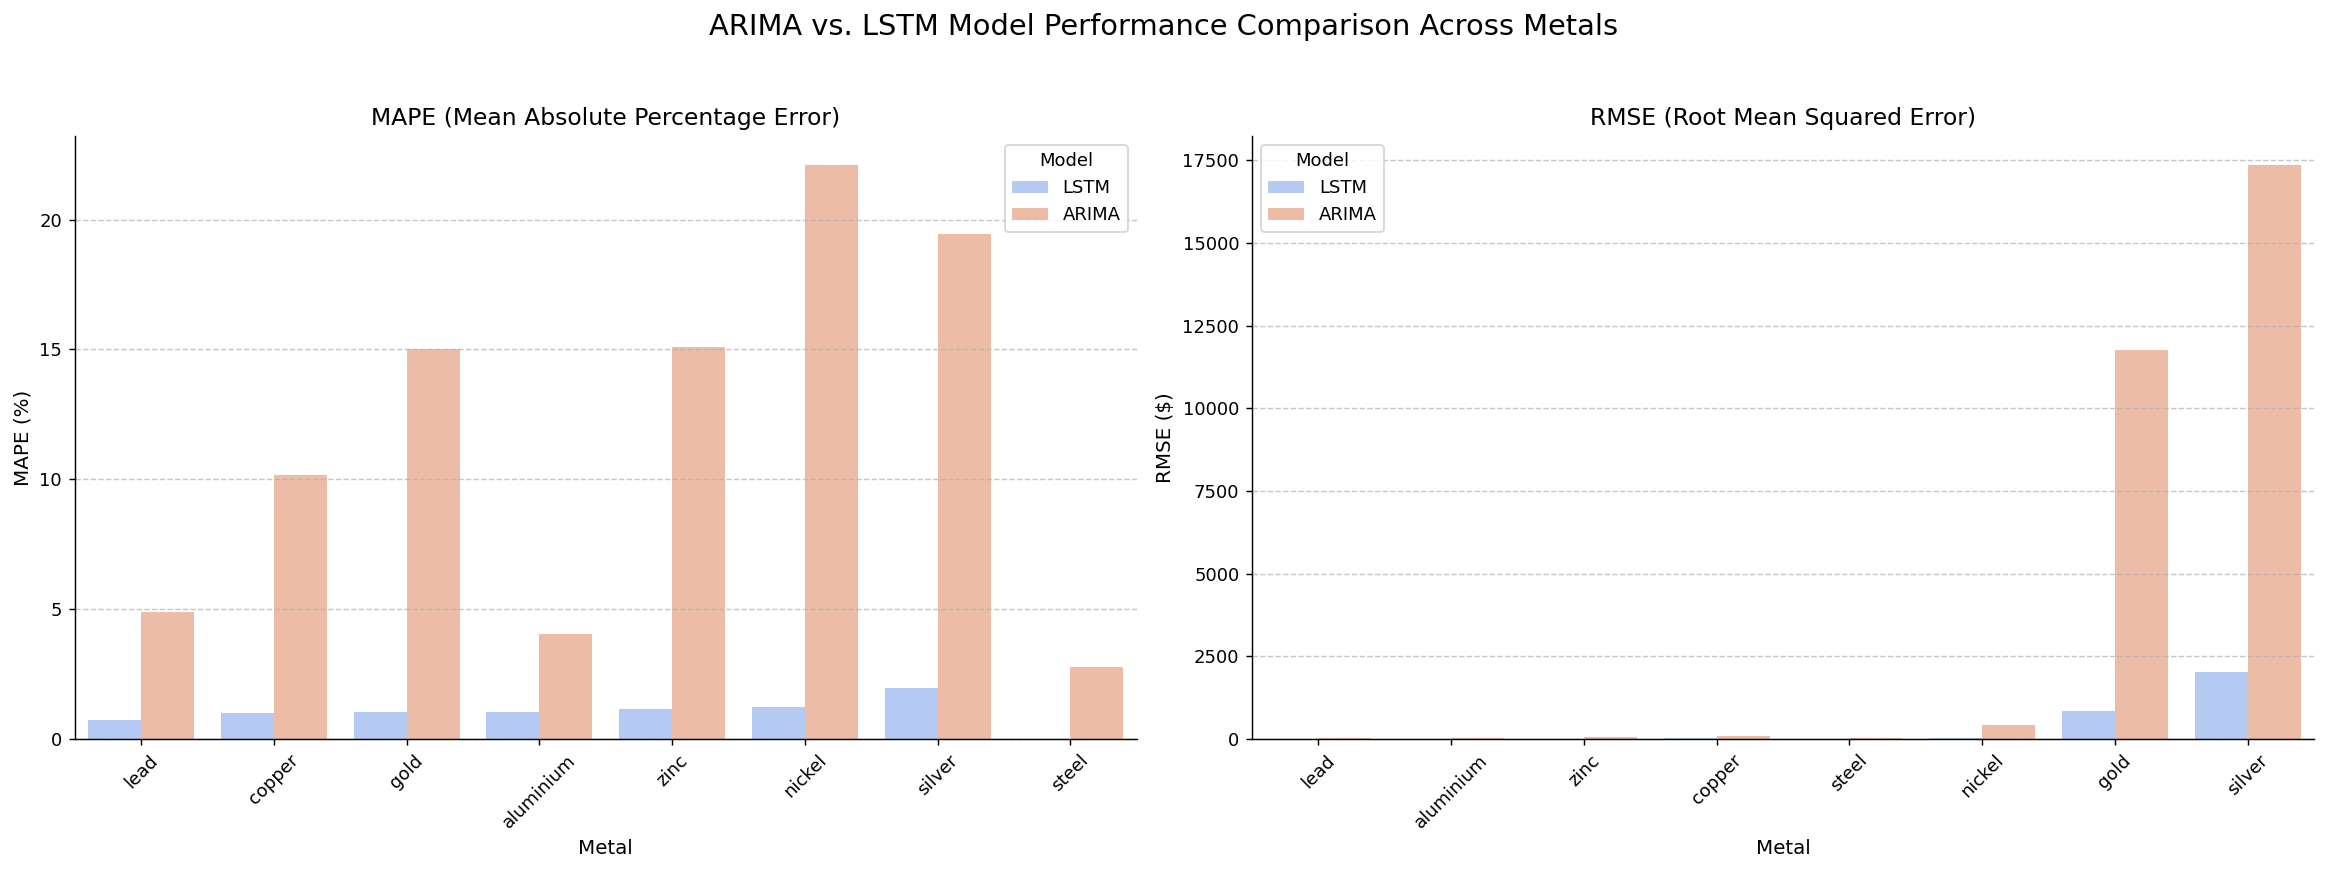

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the two dataframes for plotting
comparison_df = pd.concat([lstm_df.assign(Model='LSTM'), arima_df.assign(Model='ARIMA')])

# Filter out 'steel' from LSTM if its MAPE is infinite (as it failed to train)
comparison_df_filtered = comparison_df[~((comparison_df['Model'] == 'LSTM') & (comparison_df['MAPE'] == float('inf')))]

# Create subplots for MAPE and RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('ARIMA vs. LSTM Model Performance Comparison Across Metals', fontsize=16)

# Plot MAPE comparison
sns.barplot(x='Metal', y='MAPE', hue='Model', data=comparison_df_filtered.sort_values(by=['MAPE', 'Model']), ax=axes[0], palette='coolwarm')
axes[0].set_title('MAPE (Mean Absolute Percentage Error)')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xlabel('Metal')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE comparison
sns.barplot(x='Metal', y='RMSE', hue='Model', data=comparison_df_filtered.sort_values(by=['RMSE', 'Model']), ax=axes[1], palette='coolwarm')
axes[1].set_title('RMSE (Root Mean Squared Error)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xlabel('Metal')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

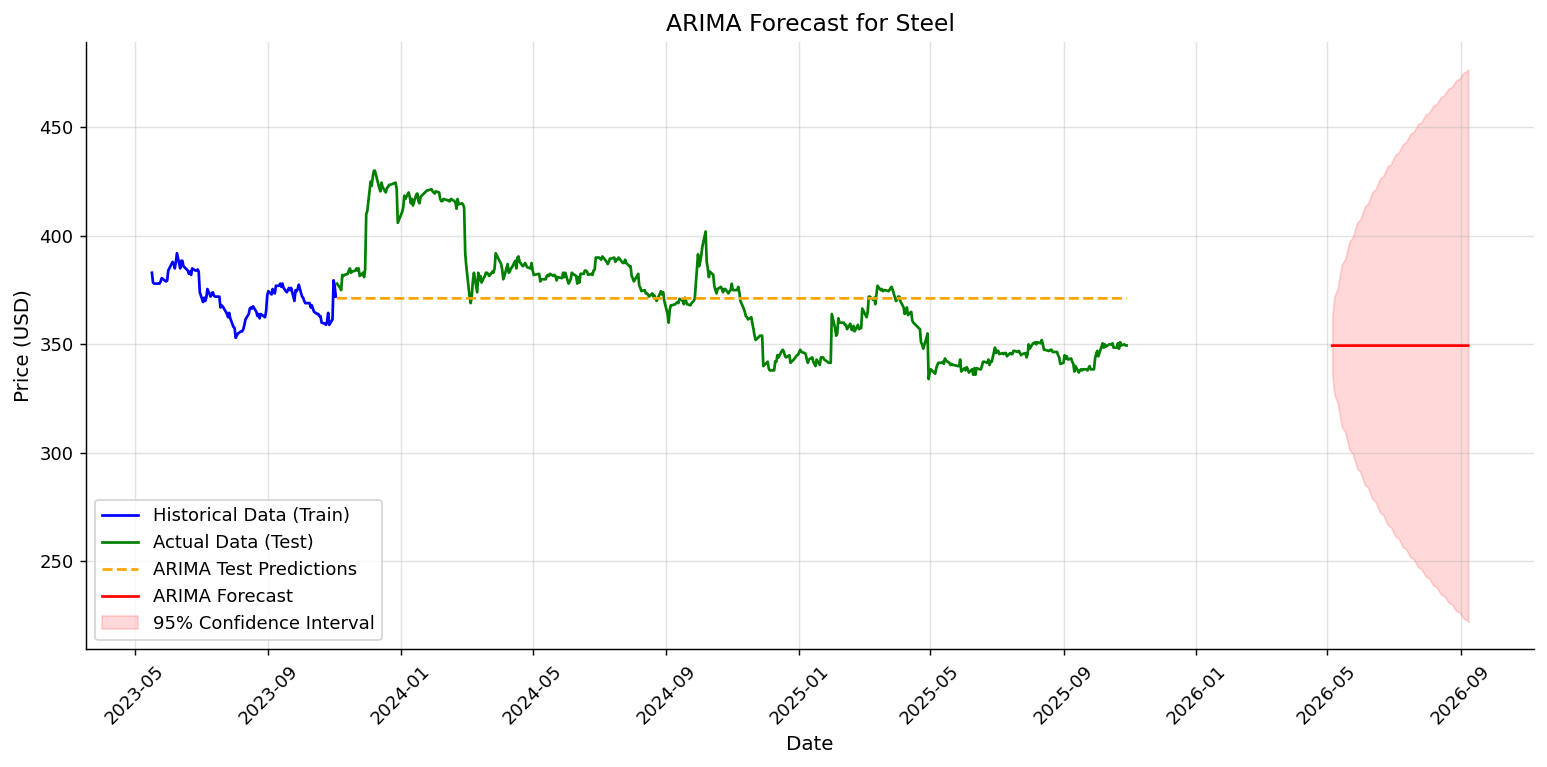

In [217]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax  = fig.add_subplot(111)

# Get original data for plotting
original_train_steel = results[metal_steel]["original_train"]
original_test_steel = results[metal_steel]["original_test"]

# Plot a portion of the historical training data (unscaled)
plot_start_idx_steel = max(0, len(original_train_steel) - WINDOW_SIZE * 2) # Plot more history
ax.plot(original_train_steel["Date"].iloc[plot_start_idx_steel:],
        original_train_steel["Price"].iloc[plot_start_idx_steel:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data (unscaled)
# Ensure test dates align with test_real_real, which is already sliced
ax.plot(arima_summary_steel['test_dates'], arima_summary_steel['test_real_real'],
        label='Actual Data (Test)', color='green')

# Plot ARIMA predictions for the test set (real USD)
ax.plot(arima_summary_steel['test_dates'], arima_summary_steel['test_pred_real'],
        label='ARIMA Test Predictions', color='orange', linestyle='--')

# Plot ARIMA future forecast (real USD)
ax.plot(arima_summary_steel['forecast_dates'], arima_summary_steel['forecast_real'],
        label='ARIMA Forecast', color='red')

# Plot confidence intervals for the forecast (real USD)
ax.fill_between(arima_summary_steel['forecast_dates'],
                arima_summary_steel['conf_lower_real'],
                arima_summary_steel['conf_upper_real'],
                color='red', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'ARIMA Forecast for {metal_steel.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Re-evaluate LSTM model for all metals with improved data preprocessing
# This cell replaces the previous failing LSTM evaluation cell.

# Initialize a dictionary to store performance metrics
lstm_performance = {}

print("\n--- Evaluating LSTM model for all metals (with updated preprocessing) ---")

# Iterate through all metals in the DAILY_FILES dictionary
for metal_key in pp.DAILY_FILES.keys():
    print(f"\nProcessing metal: {metal_key.capitalize()}")

    # Train the LSTM model
    current_lstm_summary = emt.train_lstm(
        results=results,
        metal=metal_key,
        window_size=WINDOW_SIZE,
        forecast_horizon=FORECAST_HORIZON
    )

    # Store the MAPE and RMSE
    lstm_performance[metal_key] = {
        'MAPE': current_lstm_summary['mape'],
        'RMSE': current_lstm_summary['rmse']
    }

# Convert the performance dictionary to a DataFrame for better display
lstm_df = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals (Updated) ---")
display(lstm_df.sort_values(by='MAPE'))



--- Evaluating LSTM model for all metals (with updated preprocessing) ---

Processing metal: Aluminium

  ┌─ LSTM │ aluminium ─────────────────────────────────────
| Training LSTM model on 2,128 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Copper

  ┌─ LSTM │ copper ────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Lead

  ┌─ LSTM │ lead ──────────────────────────────────────────
| Training LSTM model on 2,145 sequences ...
| Training finished. Best val_loss: 0.0003

Processing metal: Nickel

  ┌─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

Processing metal: Zinc

  ┌─ LSTM │ zinc ──────────────────────────────────────────
| Training LSTM model on 2,146 sequences ...
| Training finished. Best val_loss: 0.0002

Processing metal: Silver

  ┌─ LSTM │ silver ─────

,MAPE,RMSE
Metal,,
lead,0.735976,2.135484
copper,0.992095,10.457916
gold,1.015393,840.924347
aluminium,1.020104,2.802358
zinc,1.151535,3.628623
nickel,1.232556,38.069240
silver,1.955150,2027.870307
steel,inf,inf


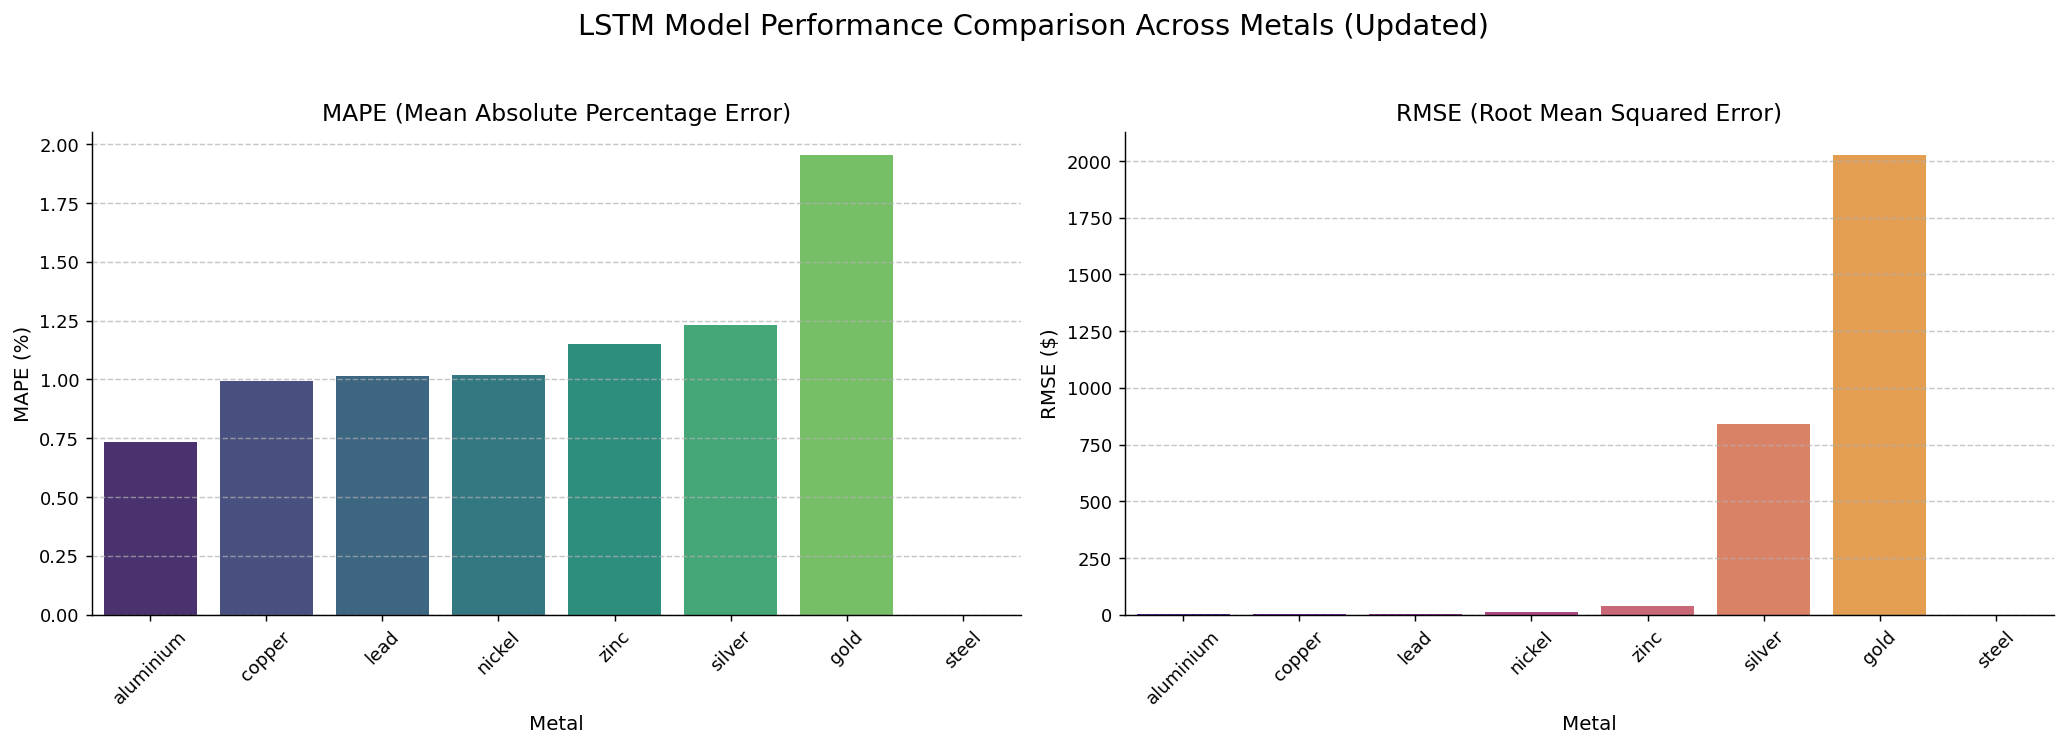

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for MAPE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM Model Performance Comparison Across Metals (Updated)', fontsize=16)

# Plot MAPE
sns.barplot(x=lstm_df.index, y='MAPE', data=lstm_df.sort_values(by='MAPE'), ax=axes[0], palette='viridis')
axes[0].set_title('MAPE (Mean Absolute Percentage Error)')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xlabel('Metal')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE
sns.barplot(x=lstm_df.index, y='RMSE', data=lstm_df.sort_values(by='RMSE'), ax=axes[1], palette='plasma')
axes[1].set_title('RMSE (Root Mean Squared Error)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xlabel('Metal')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Refining LSTM Hyperparameters for Nickel

Let's try increasing the number of epochs for the LSTM model on 'Nickel' to see if it improves performance. We'll compare the new MAPE and RMSE with the previous results.

In [188]:
# Evaluate LSTM for 'nickel' with refined hyperparameters
metal_nickel = "nickel"

# Train the LSTM model with updated hyperparameters
# Increased epochs from 50 to 100
lstm_summary_nickel_refined = emt.train_lstm(
    results=results,
    metal=metal_nickel,
    window_size=WINDOW_SIZE,
    forecast_horizon=FORECAST_HORIZON,
    epochs=100, # Increased epochs
    batch_size=32
)

m_lstm_nickel_refined = lstm_summary_nickel_refined['mape']
r_lstm_nickel_refined = lstm_summary_nickel_refined['rmse']

status_lstm_nickel_refined = "✅ PASS" if m_lstm_nickel_refined < MAPE_TARGET else "⚠️ FAIL"
print(f"\n| Refined LSTM Test MAPE for {metal_nickel.capitalize()} = {m_lstm_nickel_refined:.2f}% RMSE = ${r_lstm_nickel_refined:.2f} [{status_lstm_nickel_refined}]")
print(f"| Previous LSTM Test MAPE for {metal_nickel.capitalize()} = {lstm_performance[metal_nickel]['MAPE']:.2f}% RMSE = ${lstm_performance[metal_nickel]['RMSE']:.2f}")
print(f"| 90-day Refined LSTM forecast range for {metal_nickel.capitalize()}: "
      f"${lstm_summary_nickel_refined['forecast_real'].min():.2f} - ${lstm_summary_nickel_refined['forecast_real'].max():.2f}")

# Update the lstm_performance dictionary with the refined results
lstm_performance[metal_nickel]['MAPE'] = m_lstm_nickel_refined
lstm_performance[metal_nickel]['RMSE'] = r_lstm_nickel_refined

lstm_df_refined = pd.DataFrame.from_dict(lstm_performance, orient='index')
lstm_df_refined.index.name = 'Metal'

print("\n--- LSTM Model Performance Across All Metals (After Nickel Refinement) ---")
display(lstm_df_refined.sort_values(by='MAPE'))


  │─ LSTM │ nickel ────────────────────────────────────────
| Training LSTM model on 2,144 sequences ...
| Training finished. Best val_loss: 0.0001

| Refined LSTM Test MAPE for Nickel = 1.24% RMSE = $38.42 [✅ PASS]
| Previous LSTM Test MAPE for Nickel = 1.27% RMSE = $38.40
| 90-day Refined LSTM forecast range for Nickel: $1427.00 - $1469.52

--- LSTM Model Performance Across All Metals (After Nickel Refinement) ---


,MAPE,RMSE
Metal,,
lead,0.634643,1.973263
aluminium,0.884254,2.420049
zinc,1.109241,3.570808
gold,1.196844,1019.322256
copper,1.227271,11.657316
nickel,1.243354,38.418950
silver,1.494219,1488.681016
steel,inf,inf


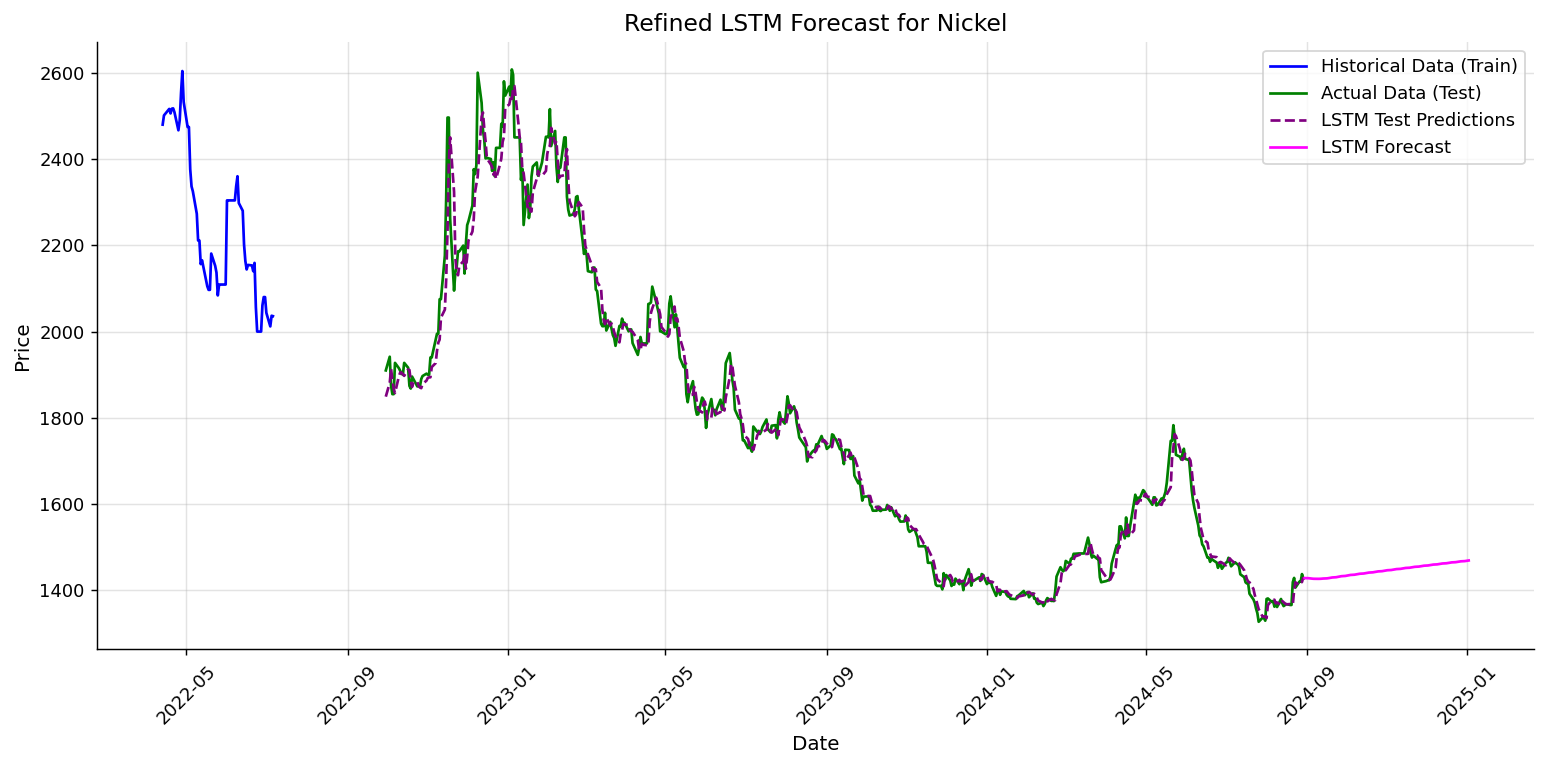

In [189]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Get original data for plotting
original_train_nickel = results[metal_nickel]["original_train"]

# Plot historical data (last part of train_s for nickel)
ax.plot(original_train_nickel["Date"].iloc[-WINDOW_SIZE:].astype('datetime64[ns]'),
        original_train_nickel["Price"].iloc[-WINDOW_SIZE:],
        label='Historical Data (Train)', color='blue')

# Plot actual test data for nickel
ax.plot(lstm_summary_nickel_refined['test_dates'].astype('datetime64[ns]'),
        lstm_summary_nickel_refined['test_actual_real'],
        label='Actual Data (Test)', color='green')

# Plot LSTM predictions for the test set for nickel
ax.plot(lstm_summary_nickel_refined['test_dates'].astype('datetime64[ns]'),
        lstm_summary_nickel_refined['test_pred_real'],
        label='LSTM Test Predictions', color='purple', linestyle='--')

# Plot LSTM future forecast for nickel
ax.plot(lstm_summary_nickel_refined['forecast_dates'].astype('datetime64[ns]'),
        lstm_summary_nickel_refined['forecast_real'],
        label='LSTM Forecast', color='magenta')

ax.set_title(f'Refined LSTM Forecast for {metal_nickel.capitalize()}')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()